**ALL IMPORTS**

In [10]:
!pip -q install gymnasium stable-baselines3 opencv-python matplotlib shimmy
!pip install imageio

import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env



**TO LOAD THE RACETRACK (from the png uploaded)**

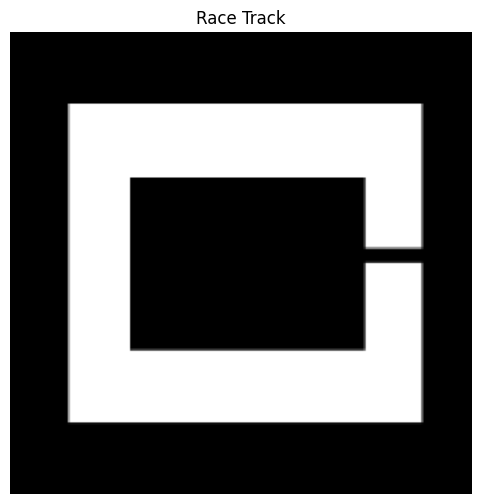

In [11]:
# Read the race track image in grayscale
track = cv2.imread("track.png", cv2.IMREAD_GRAYSCALE)

# Resize to a fixed size
track = cv2.resize(track, (200,200))

# Save resized version
cv2.imwrite("track.png", track)

# Display the track
plt.figure(figsize=(6,6))
plt.imshow(track, cmap="gray")
plt.title("Race Track")
plt.axis("off")
plt.show()

**TO CREATE A CUSTOM RACING ENVIRONMENT**

In [12]:
class RacingEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    # Initialiser
    def __init__(self):
        super().__init__()
        # Load track
        self.track = cv2.imread("track.png", cv2.IMREAD_GRAYSCALE)
        self.height, self.width = self.track.shape

        # ACTION SPACE: (0-Forward, 1-Left, 2-Right, 3-Brake)
        self.action_space = spaces.Discrete(4)

        # OBSERVATION SPACE= [x,y,angle,front,front_left,front_right,left,right]
        self.observation_space = spaces.Box(
            low=np.array([0,0,-180,0,0,0,0,0],
                         dtype=np.float32),
            high=np.array([200,200,180,70,70,70,70,70],
                          dtype=np.float32), dtype=np.float32)

        # Sensor Angles
        self.sensor_angles = [0, -30, 30, -75, 75]
        self.sensor_length = 70
        self.reset()


    # RESET
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # Start just below the finish line
        self.x = 175
        self.y = 145
        self.angle = 90      # facing downward
        self.speed = 2

        # checkpoints
        self.cp1 = False
        self.cp2 = False
        self.cp3 = False
        self.cp4 = False

        return self._get_obs(), {}

    # VIRTUAL LIDAR SENSOR
    def cast_sensor(self, angle_offset):
        angle = np.radians(self.angle + angle_offset)
        for distance in range(1, self.sensor_length + 1):
            sx = int(self.x + distance*np.cos(angle))
            sy = int(self.y + distance*np.sin(angle))

            # Outside map
            if (sx < 0 or sx >= self.width or sy < 0 or sy >= self.height):
                return distance

            # Wall detected
            if self.track[sy, sx] == 0:
                return distance

        return self.sensor_length

    # STEP FUNCTION
    def step(self, action):

        # For Steering:
        if action == 1:
            self.angle -= 6
        elif action == 2:
            self.angle += 6
        elif action == 3:
            self.speed = max(1, self.speed - 0.2)
        else:
            self.speed = min(3, self.speed + 0.05)

        # To Move:
        self.x += self.speed * np.cos(np.radians(self.angle))
        self.y += self.speed * np.sin(np.radians(self.angle))

        terminated = False
        reward = 1

        # Sensor Readings
        front = self.cast_sensor(0)
        front_left = self.cast_sensor(-30)
        front_right = self.cast_sensor(30)
        left = self.cast_sensor(-75)
        right = self.cast_sensor(75)

        # Penalty for driving close to walls
        min_sensor = min(front, front_left, front_right, left, right)
        # Reward for staying in open space
        reward += 0.05 * min_sensor
        if min_sensor < 8:
            reward -= 5
        elif min_sensor < 15:
            reward -= 2

        # Outside Track
        if (self.x < 0 or self.x >= self.width or self.y < 0 or
            self.y >= self.height):
            reward = -100
            terminated = True

        # Hit Wall
        elif self.track[int(self.y), int(self.x)] == 0:
            reward = -100
            terminated = True

        # Bonus on final straight
        if (not terminated and self.cp4 and self.x > 150):
            reward += 2

    # ALL CHECKPOINTS
        # CHECKPOINT 1
        if (not terminated and not self.cp1 and 160 <= self.x <= 190 and
            135 <= self.y <= 185):
          reward += 50
          self.cp1 = True

        # CHECKPOINT 2
        elif (self.cp1 and not self.cp2 and 20 <= self.x <= 60 and
              135 <= self.y <= 185):
          reward += 50
          self.cp2 = True

        # CHECKPOINT 3
        elif (self.cp2 and not self.cp3 and 20 <= self.x <= 60 and
              20 <= self.y <= 60):
          reward += 50
          self.cp3 = True

        # CHECKPOINT 4
        elif (self.cp3 and not self.cp4 and 150 <= self.x <= 190 and
              20 <= self.y <= 60):
            reward += 50
            self.cp4 = True

        # FINISH
        elif (self.cp1 and self.cp2 and self.cp3 and self.cp4 and
              165 <= self.x <= 195 and 70 <= self.y <= 115 and
              self.angle < -45):
          reward += 500
          terminated = True

        observation = self._get_obs()
        return observation, reward, terminated, False, {}

    # OBSERVATION
    def _get_obs(self):

        front = self.cast_sensor(0)
        front_left = self.cast_sensor(-30)
        front_right = self.cast_sensor(30)
        left = self.cast_sensor(-75)
        right = self.cast_sensor(75)

        return np.array([ self.x, self.y, self.angle, front, front_left,
                          front_right, left, right   ], dtype=np.float32  )

    # RENDER
    def render(self):
        img = cv2.cvtColor(self.track, cv2.COLOR_GRAY2BGR)

        # Draw Sensor Rays
        colors = [
            (0,255,255),   # Front
            (255,0,255),   # Front Left
            (255,0,255),   # Front Right
            (0,255,0),     # Left
            (0,255,0)      # Right
        ]

        sensor_values = [
            self.cast_sensor(0),
            self.cast_sensor(-30),
            self.cast_sensor(30),
            self.cast_sensor(-75),
            self.cast_sensor(75)]

        for angle_offset, dist, color in zip(self.sensor_angles, sensor_values,
                                             colors):
          angle = np.radians(self.angle + angle_offset)

          end_x = int(self.x + dist*np.cos(angle))
          end_y = int(self.y + dist*np.sin(angle))

          cv2.line(img, (int(self.x), int(self.y)), (end_x, end_y), color, 2)

          cv2.circle(img, (end_x, end_y), 3, color, -1)

        # Draw Car
        cv2.circle( img, (int(self.x), int(self.y)), 6, (255,0,0), -1)

        # Heading arrow
        arrow_x = int(self.x + 15*np.cos(np.radians(self.angle)))
        arrow_y = int(self.y + 15*np.sin(np.radians(self.angle)))

        cv2.arrowedLine( img, (int(self.x), int(self.y)), (arrow_x, arrow_y),
                        (0,0,255), 2)

        plt.figure(figsize=(7,7))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

**TESTING THE ENVIRONMENT**

Initial Observation: [175. 145.  90.  25.   8.  29.   5.  70.]
Step 1
Action: 1
Reward: 46.2
Step 2
Action: 3
Reward: -3.8
Step 3
Action: 2
Reward: -3.8
Step 4
Action: 0
Reward: -3.8
Step 5
Action: 3
Reward: -3.8
Step 6
Action: 1
Reward: -3.8
Step 7
Action: 0
Reward: -3.8
Step 8
Action: 1
Reward: -3.85
Step 9
Action: 0
Reward: -3.85
Step 10
Action: 2
Reward: -3.85
Step 11
Action: 0
Reward: -3.85
Step 12
Action: 3
Reward: -3.85
Step 13
Action: 1
Reward: -3.9
Step 14
Action: 2
Reward: -3.95
Step 15
Action: 1
Reward: -100
Episode Finished!


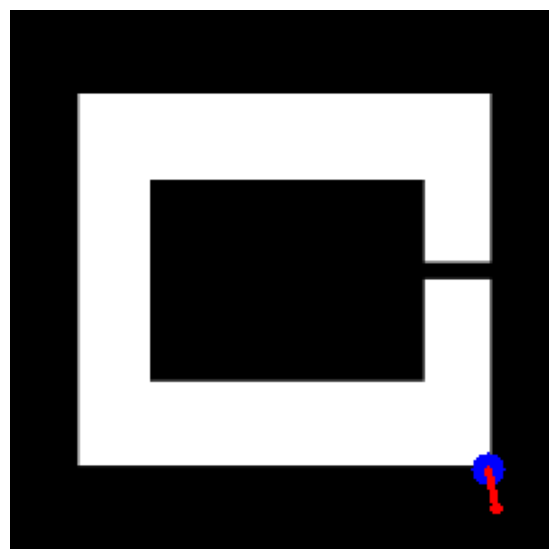

In [13]:
# Create the environment
env = RacingEnv()

# Reset it
obs, _ = env.reset()

print("Initial Observation:", obs)

# Take 20 random actions
done = False

for i in range(20):
    action = env.action_space.sample()
    obs, reward, done, _, _ = env.step(action)

    print(f"Step {i+1}")
    print("Action:", action)
    print("Reward:", reward)

    if done:
        print("Episode Finished!")
        break

# Show the final position
env.render()

**CHECKING IF ENVIRONMENT IS VALID (compatible with gymnasium API)**

In [14]:
check_env(RacingEnv())
print("Environment is valid!")

Environment is valid!


**TRAINING THE RL AGENT**

In [15]:
#creating custom racing environment
env = RacingEnv()

#create PPO (Proximal policy optimization) reinforcement learning
model = PPO(
    "MlpPolicy",              # Multi-Layer Perceptron policy network
    env,                      # Custom racing environment
    learning_rate=0.0003,     # Controls how quickly the neural network updates its weights
    gamma=0.99,               # Discount factor for future rewards
    n_steps=2048,             # Number of environment steps before each policy update
    batch_size=64,            # Number of samples used in one gradient update
    n_epochs=10,              # epochs
    gae_lambda=0.95,          # Generalized Advantage Estimation parameter
    clip_range=0.2,           # PPO clipping threshold to prevent large policy updates
    ent_coef=0.01,            # Encourages exploration by adding entropy to the policy
    verbose=1)                # Display training progress and statistics

# Train the PPO agent for 200,000 timesteps
model.learn(total_timesteps=200000)

# Save the trained model for future testing or deployment
model.save("ppo_racing_v2")

print("Training Complete!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 15.3     |
|    ep_rew_mean     | -101     |
| time/              |          |
|    fps             | 333      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 16.8        |
|    ep_rew_mean          | -106        |
| time/                   |             |
|    fps                  | 310         |
|    iterations           | 2           |
|    time_elapsed         | 13          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.018431652 |
|    clip_fraction        | 0.245       |
|    clip_range           | 0.2         |
|    entropy_loss   

**TO TEST THE TRAINED AGENT**

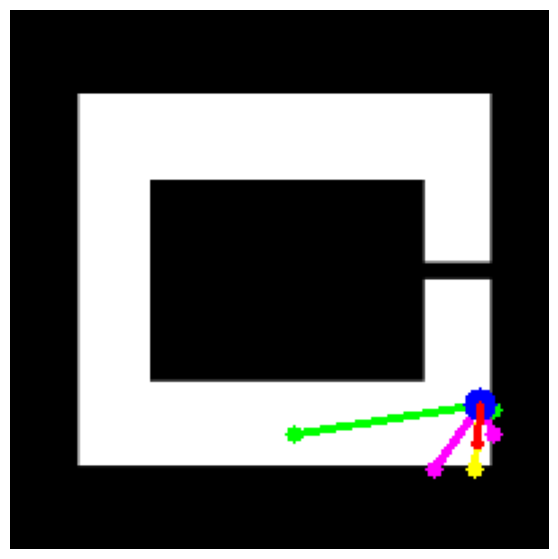

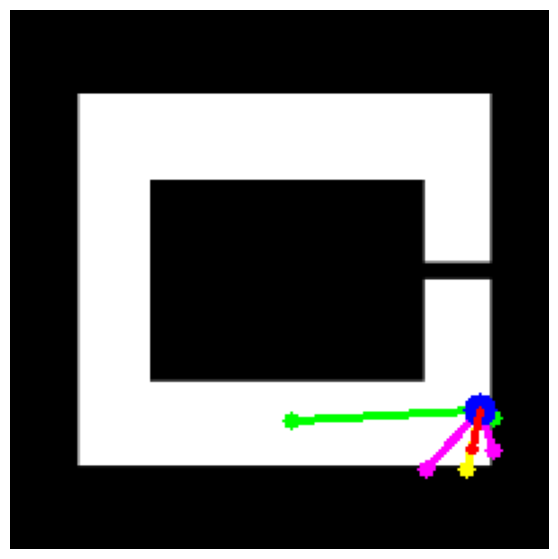

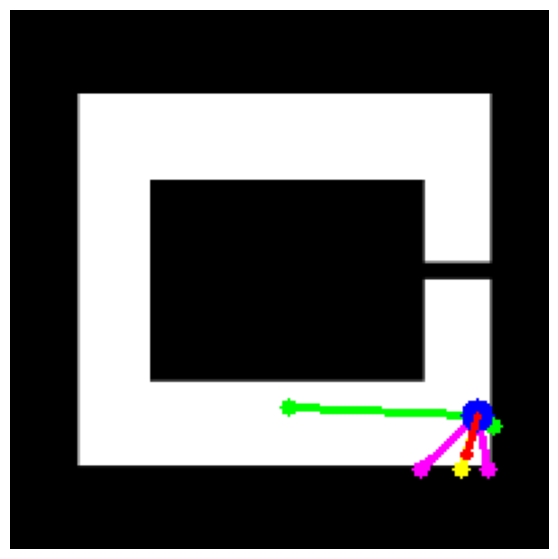

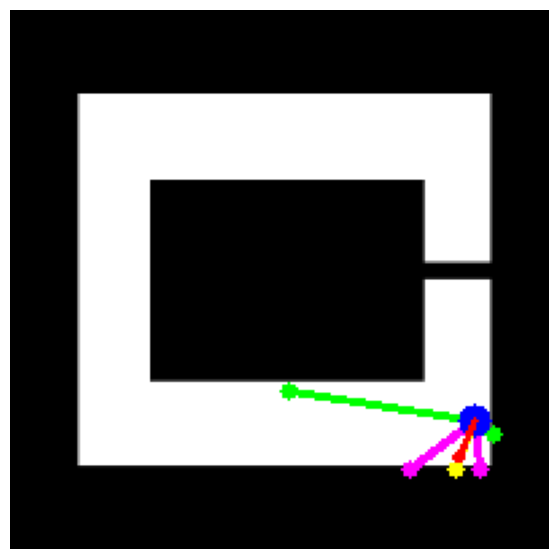

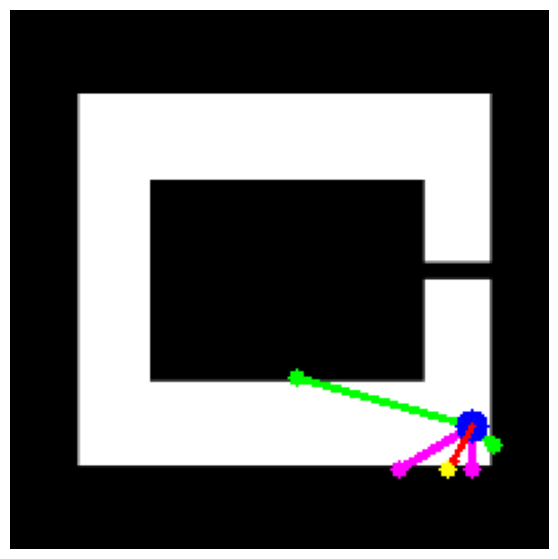

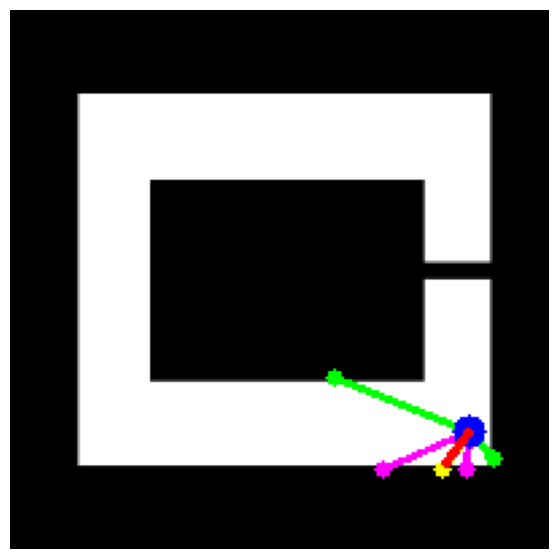

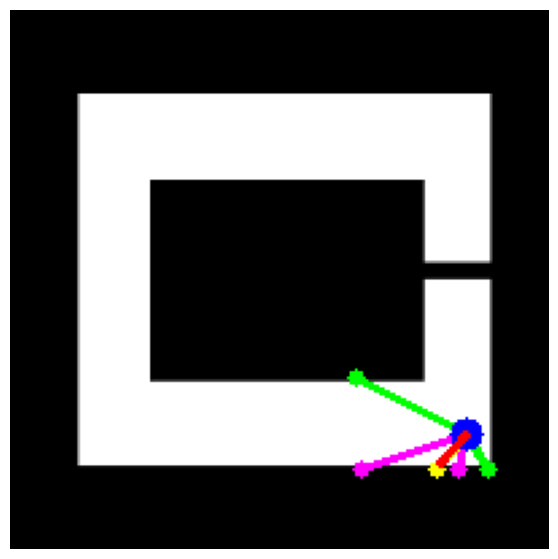

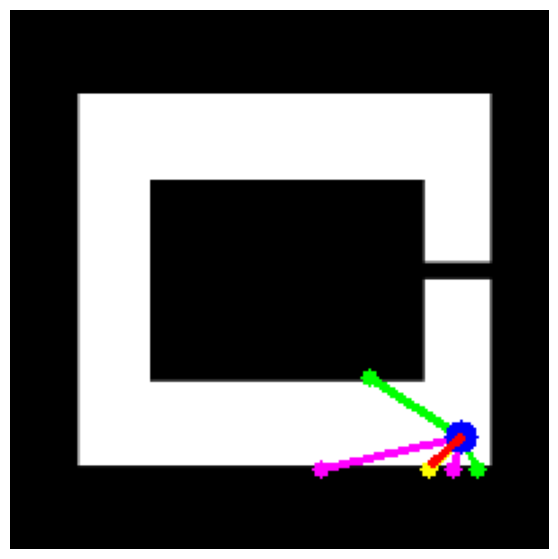

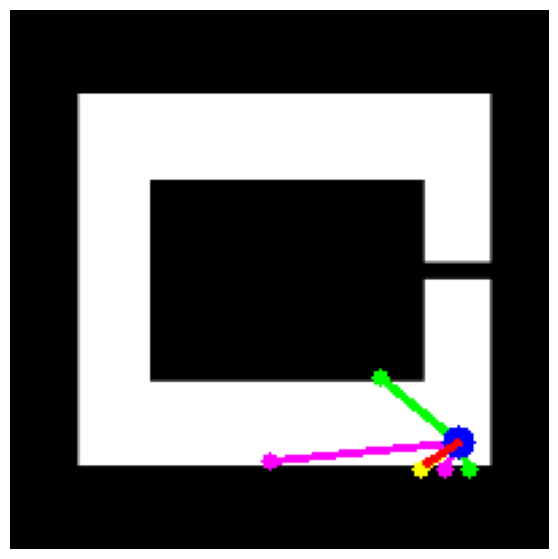

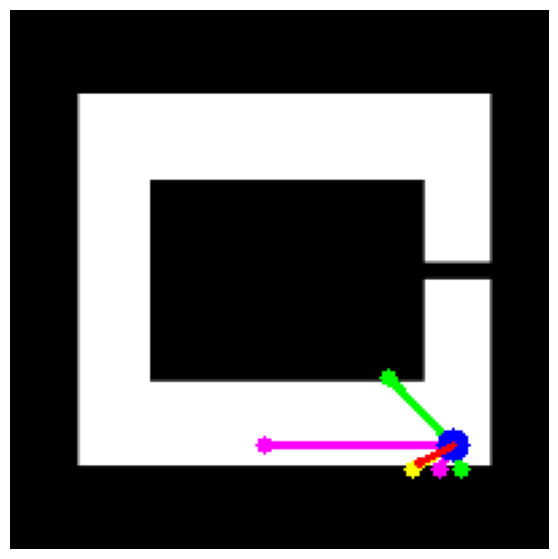

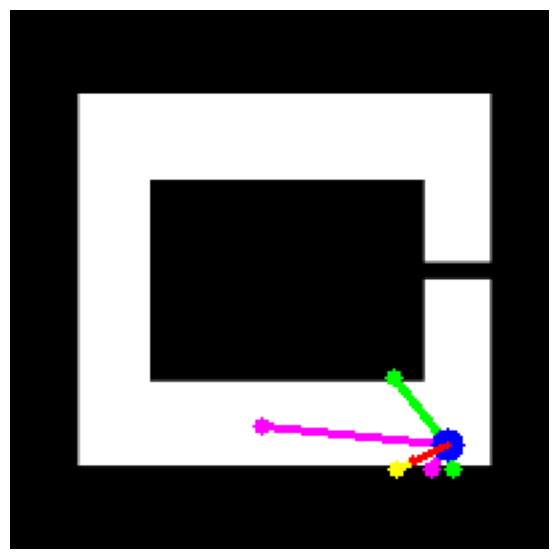

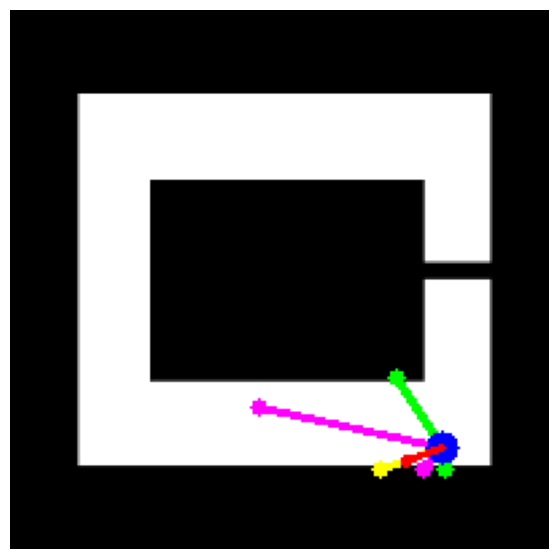

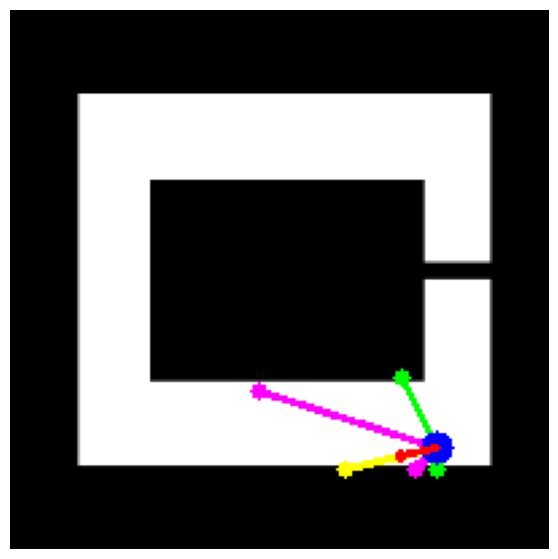

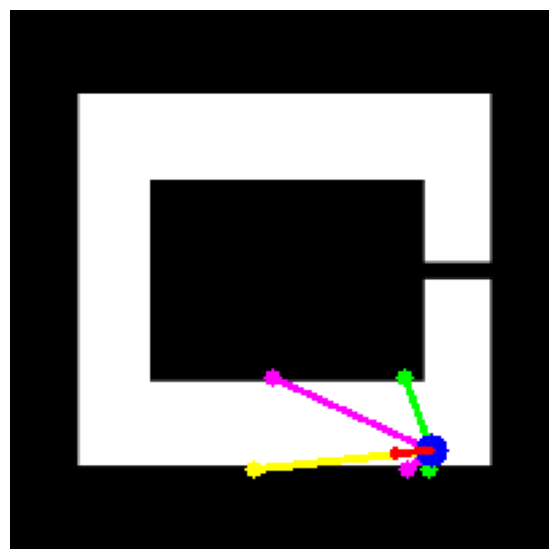

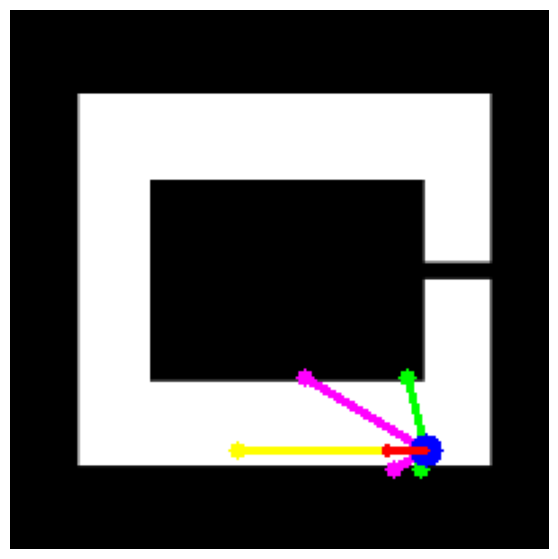

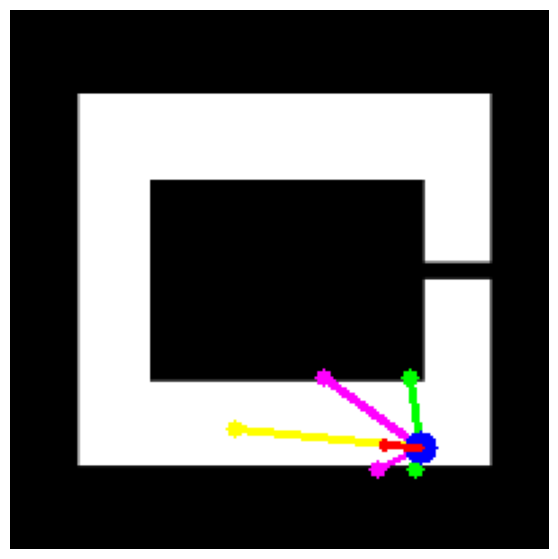

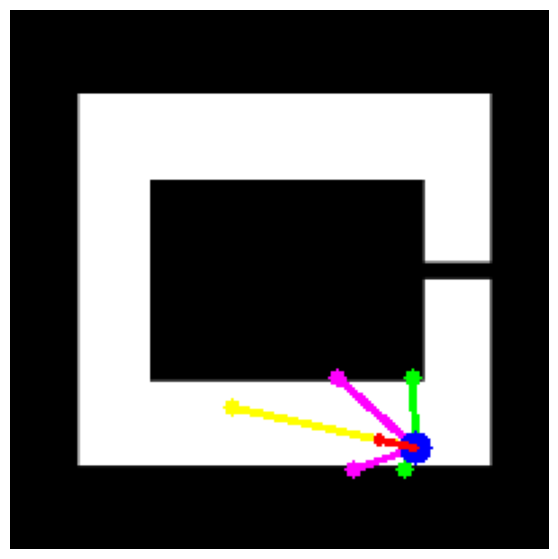

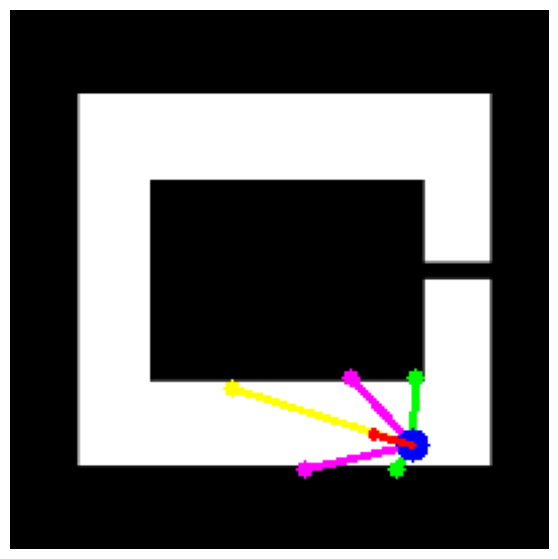

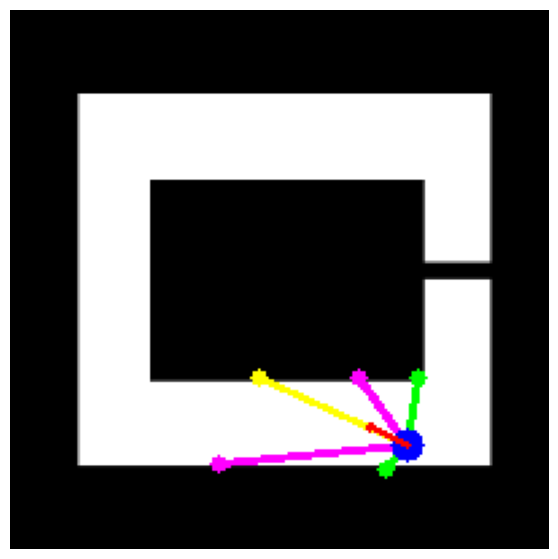

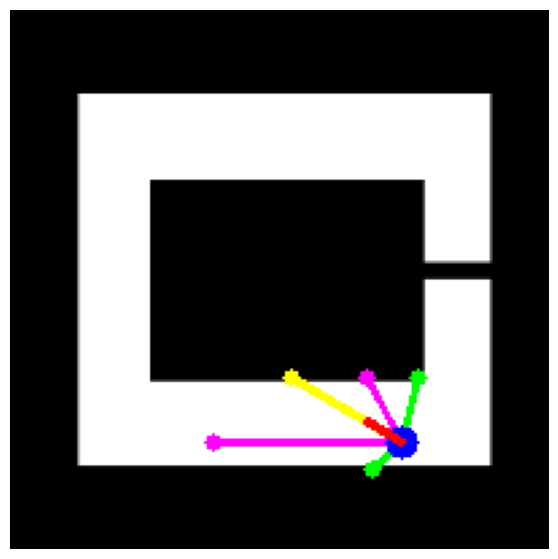

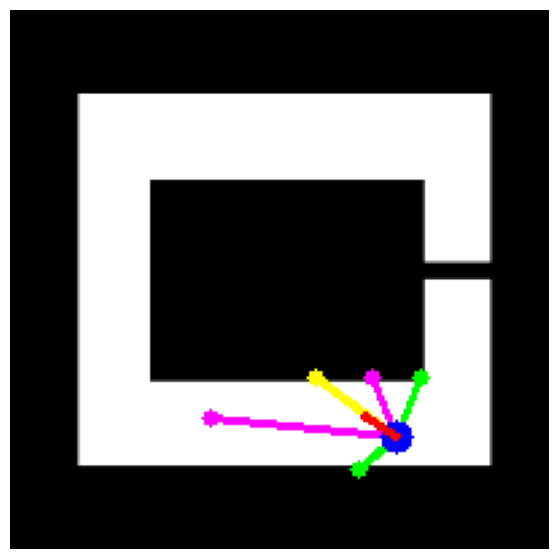

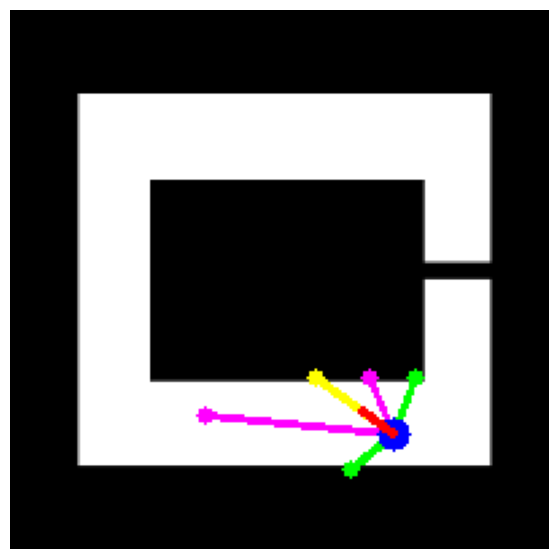

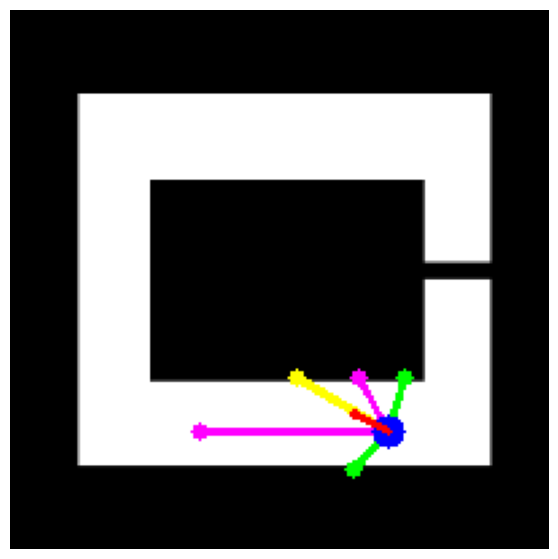

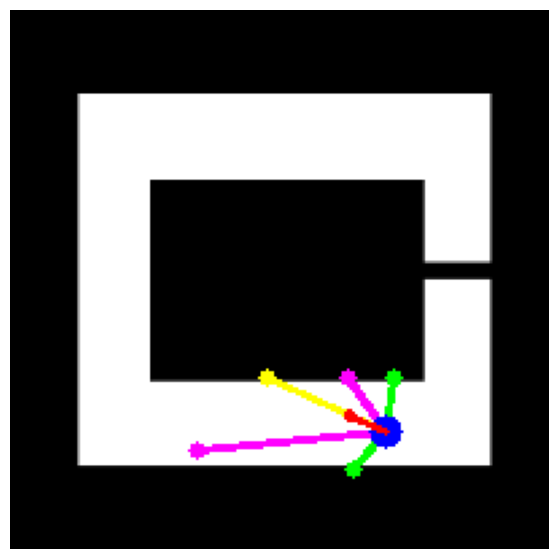

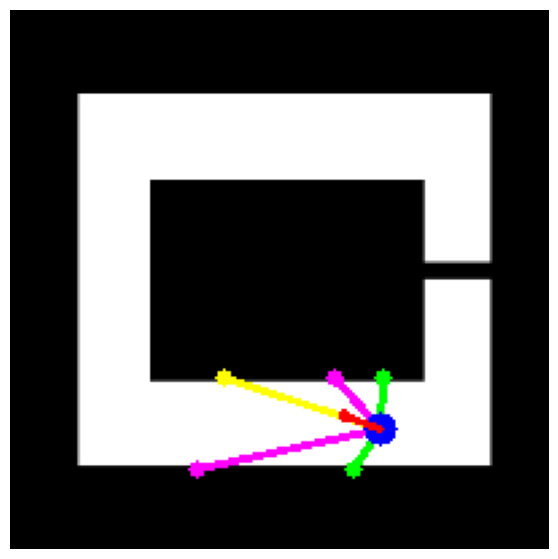

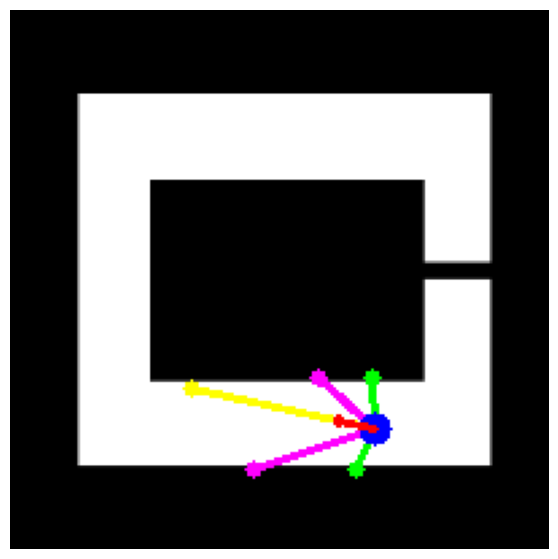

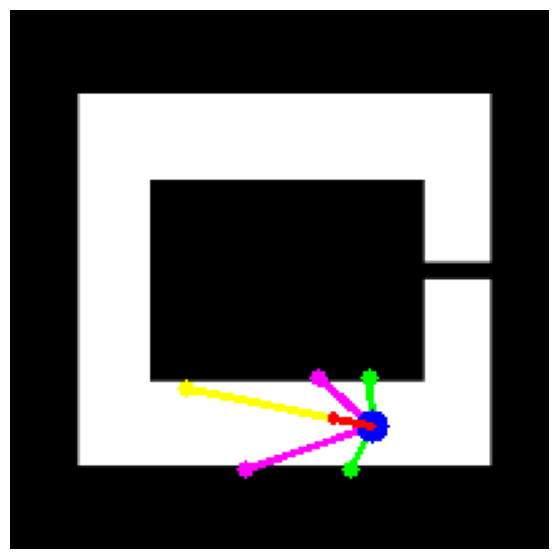

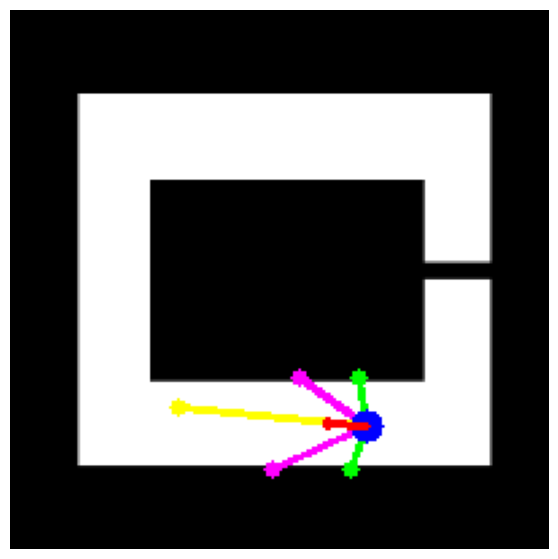

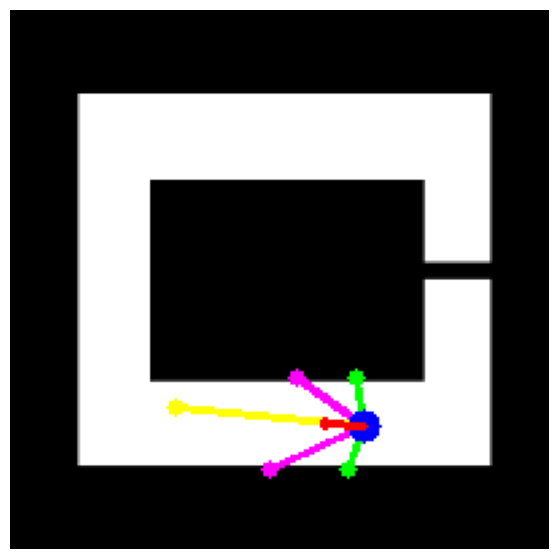

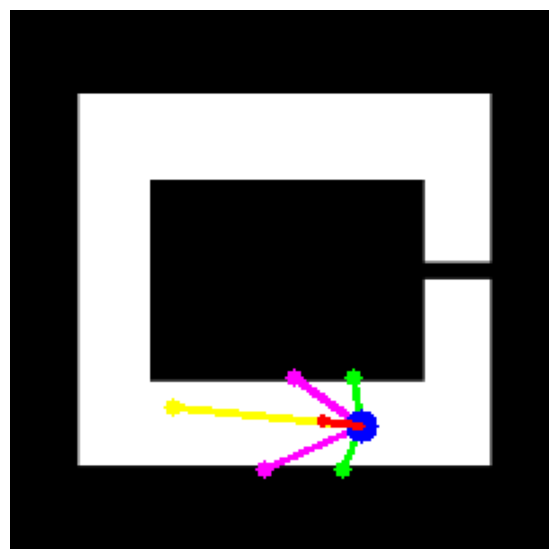

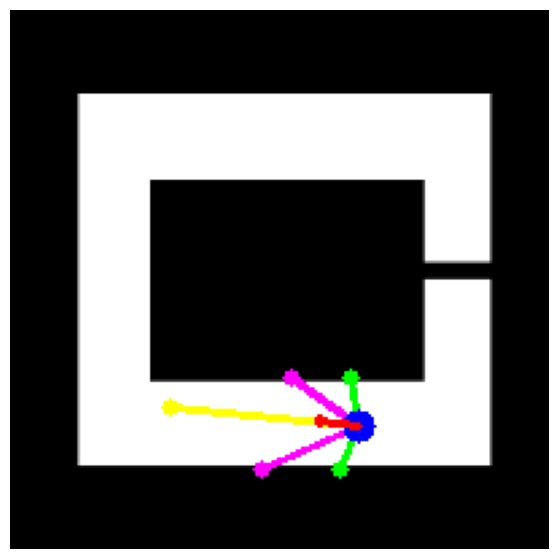

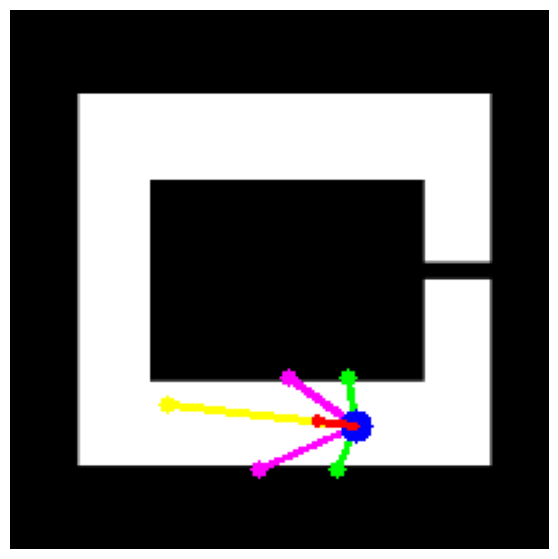

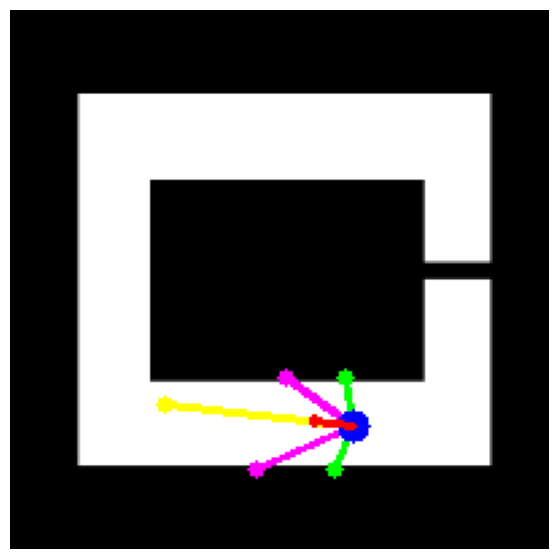

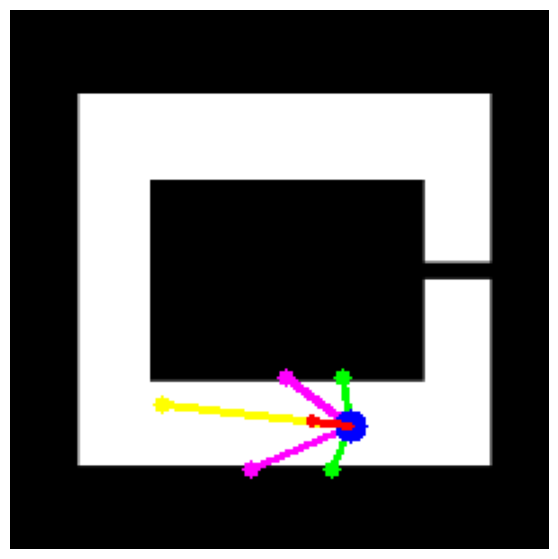

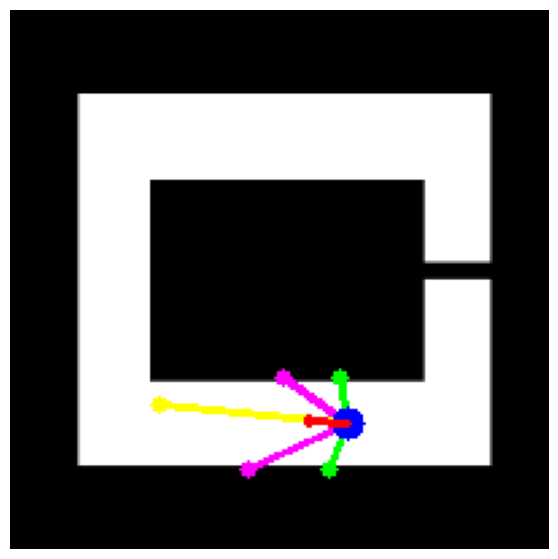

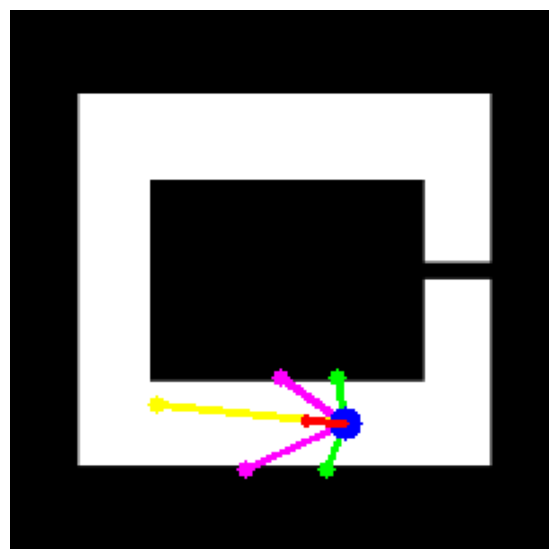

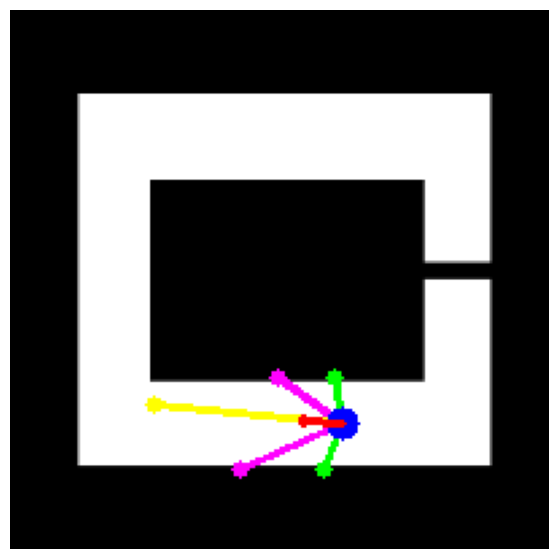

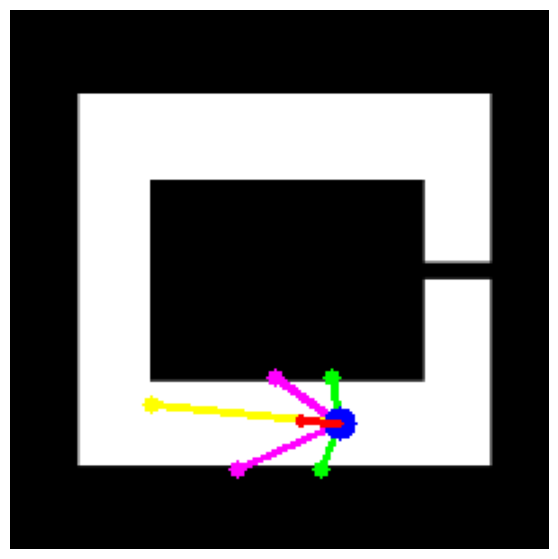

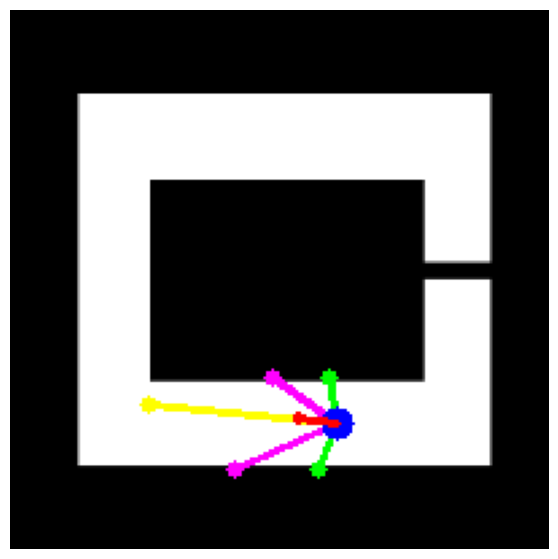

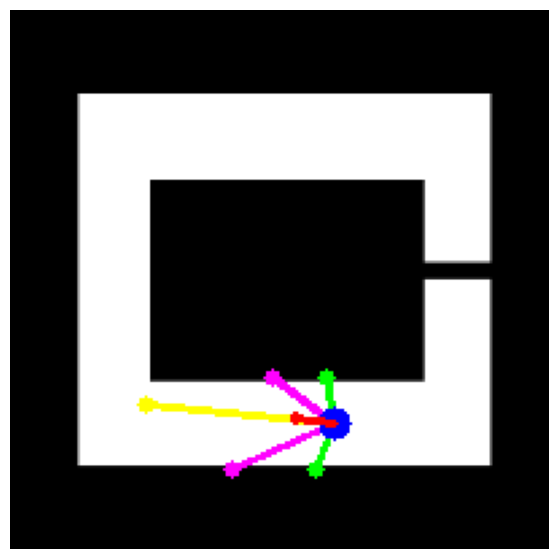

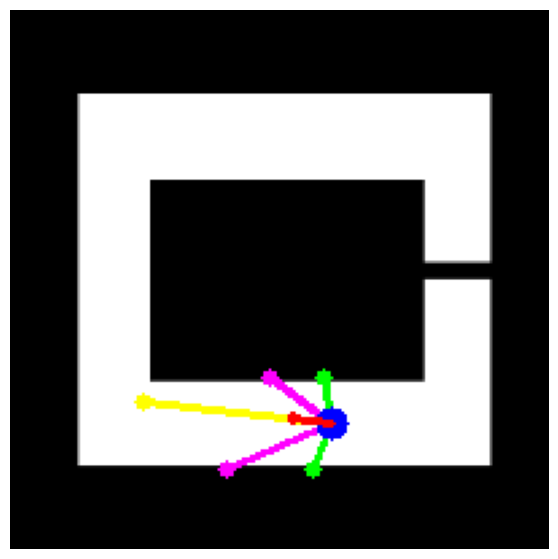

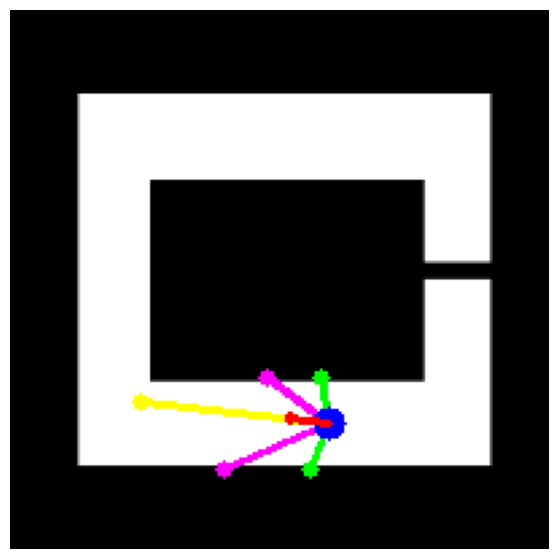

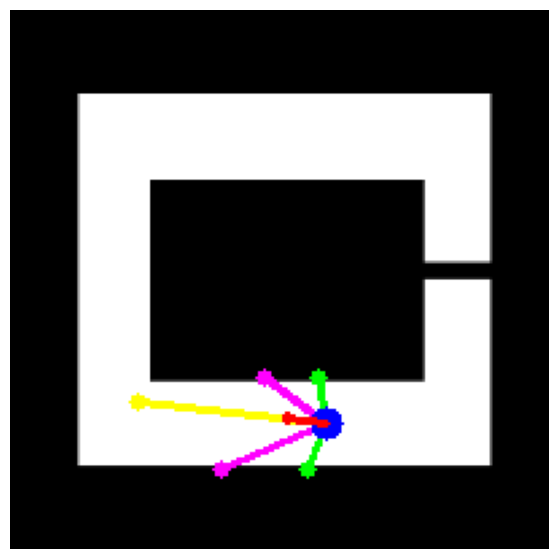

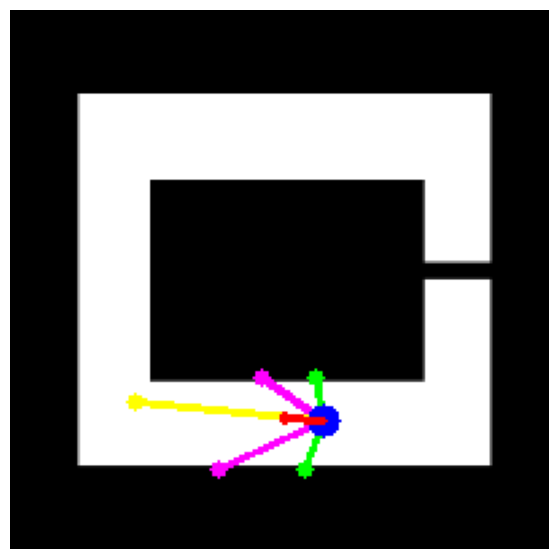

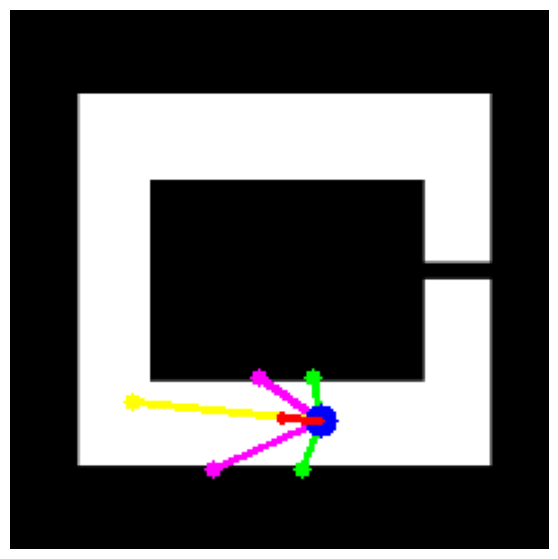

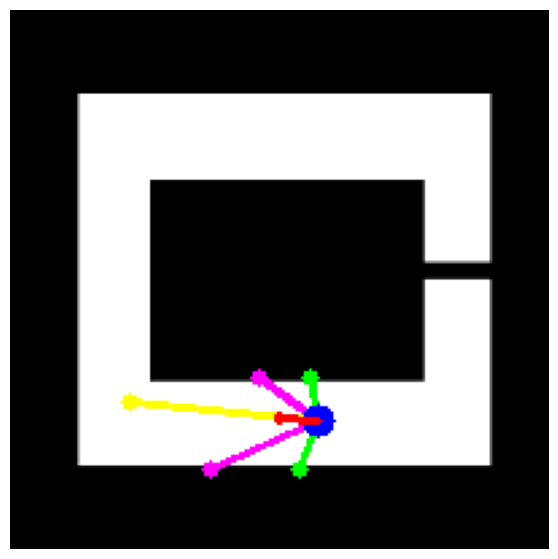

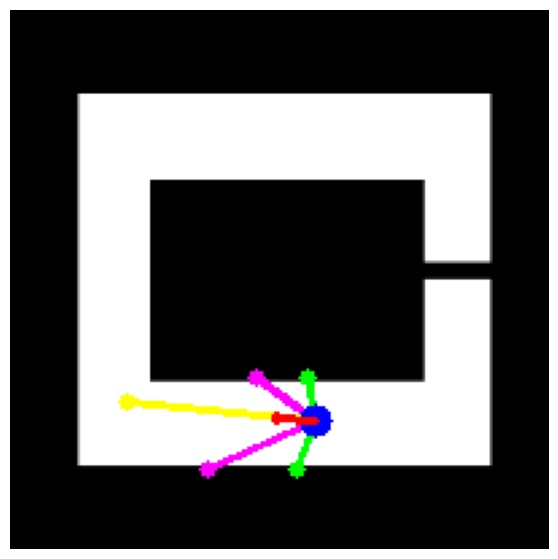

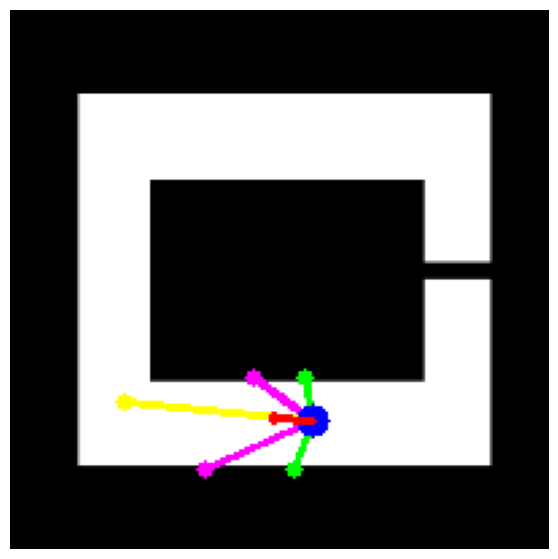

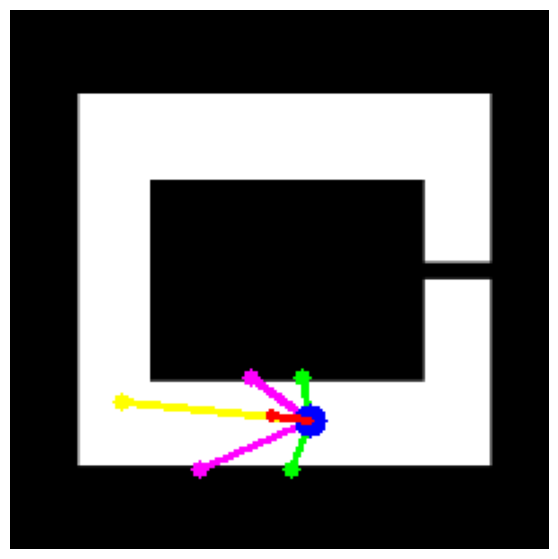

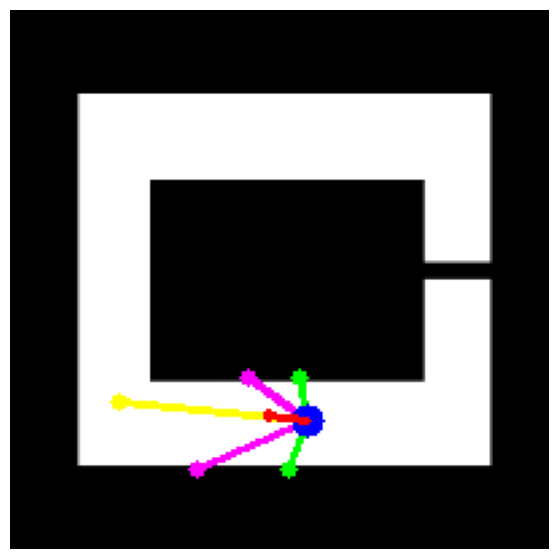

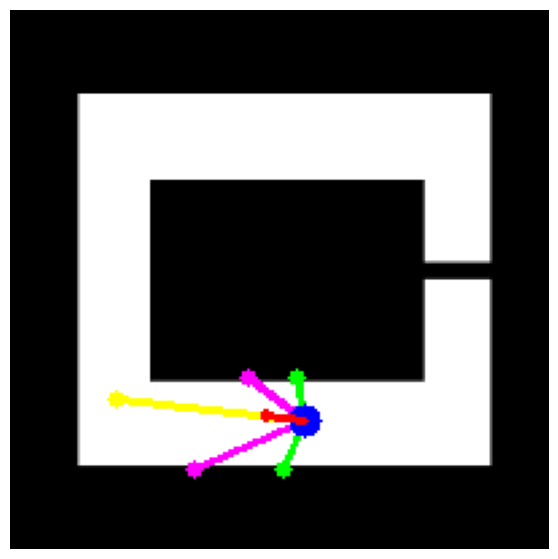

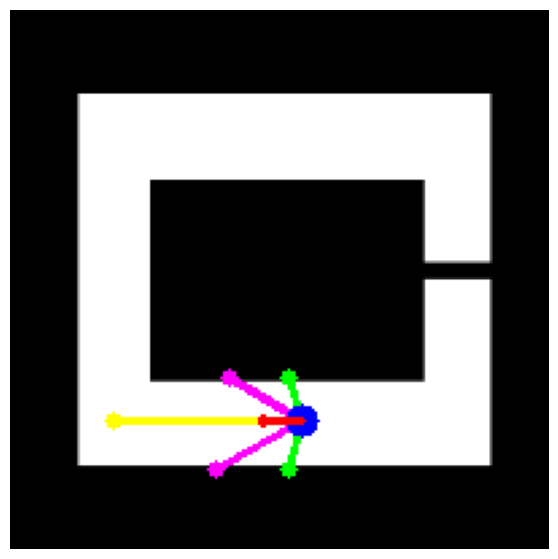

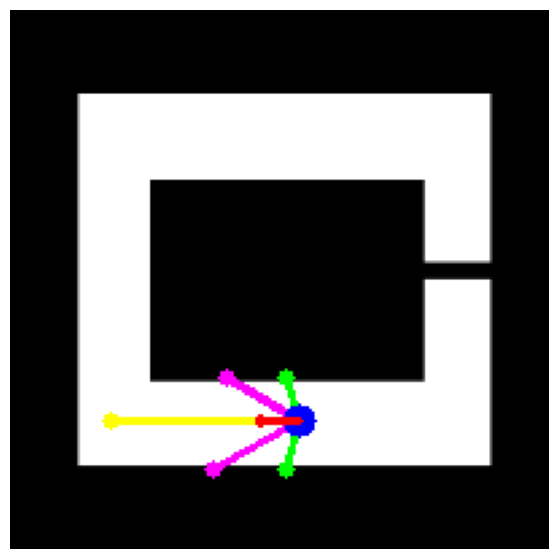

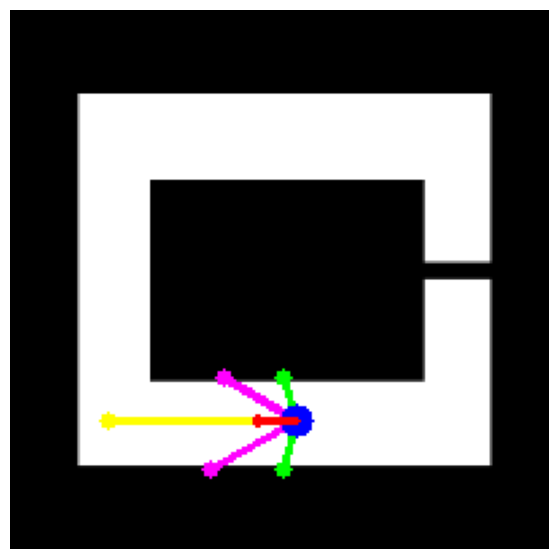

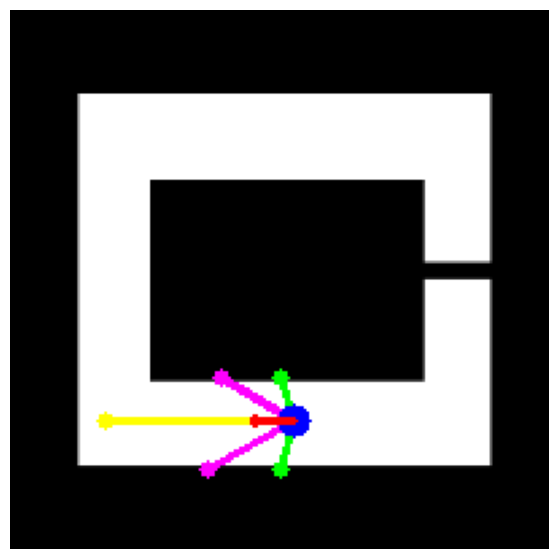

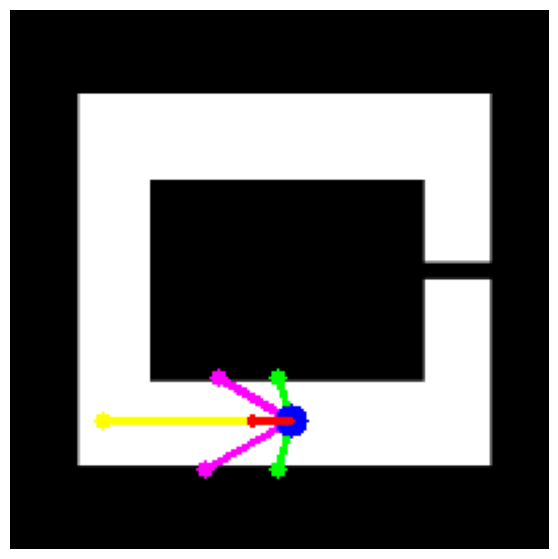

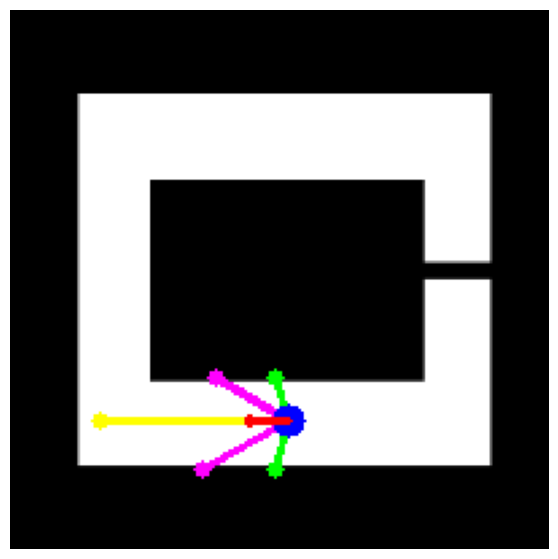

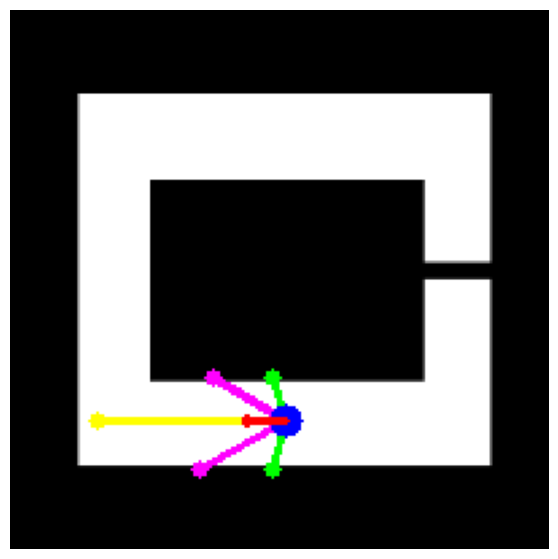

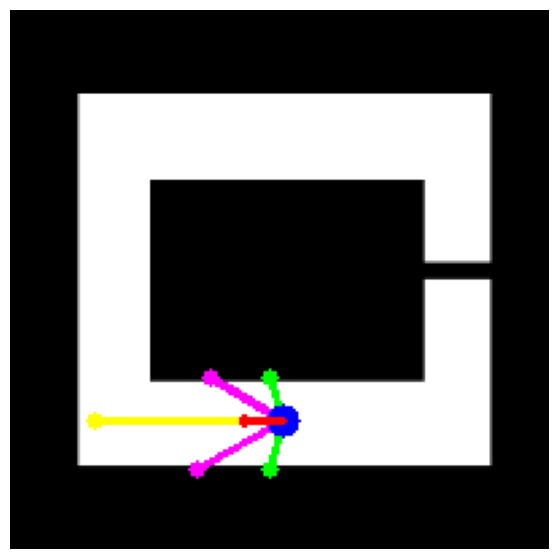

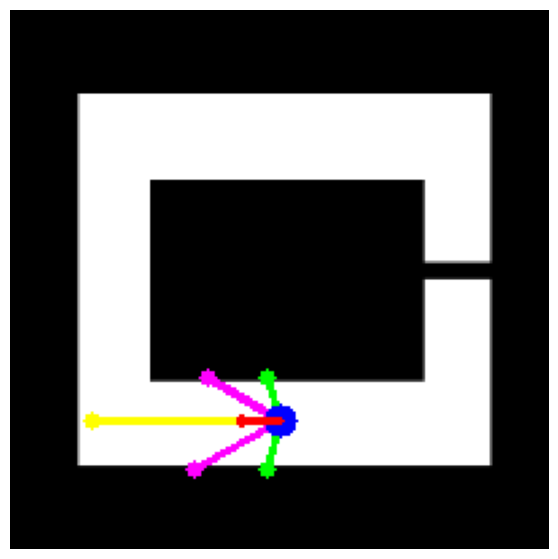

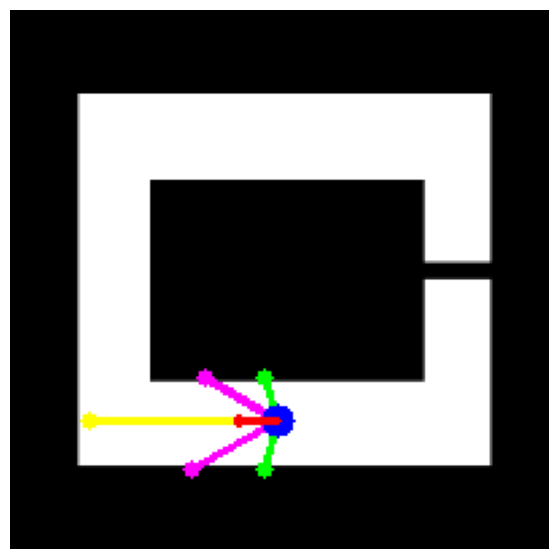

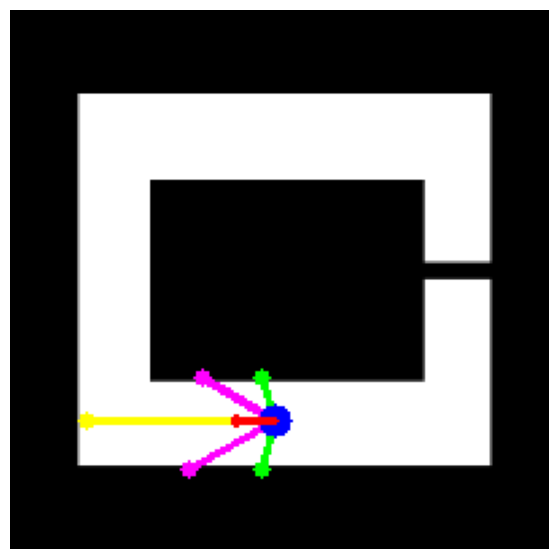

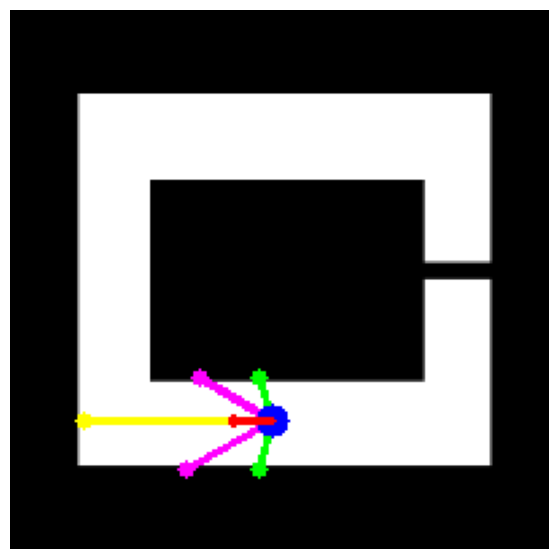

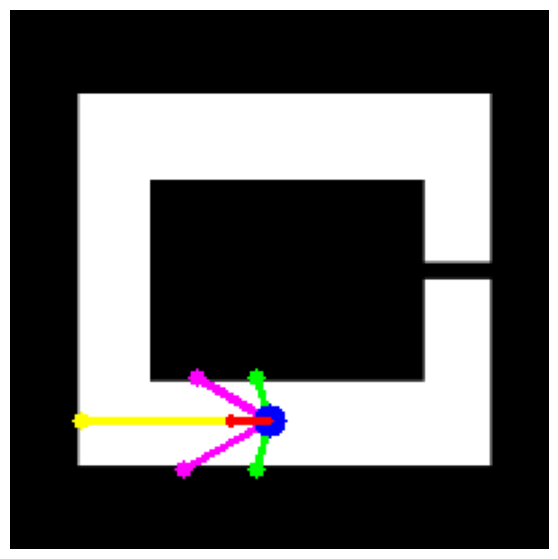

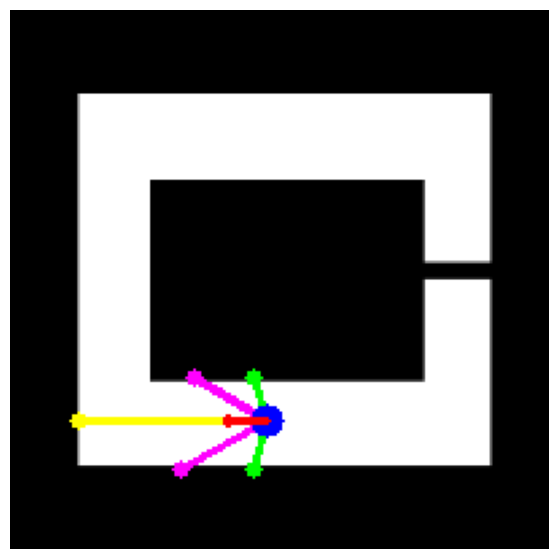

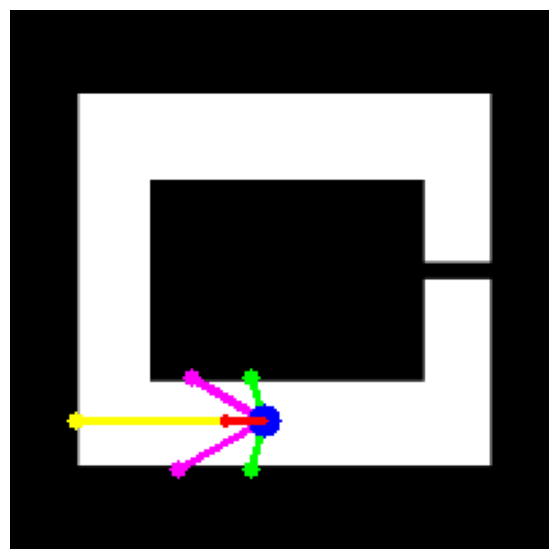

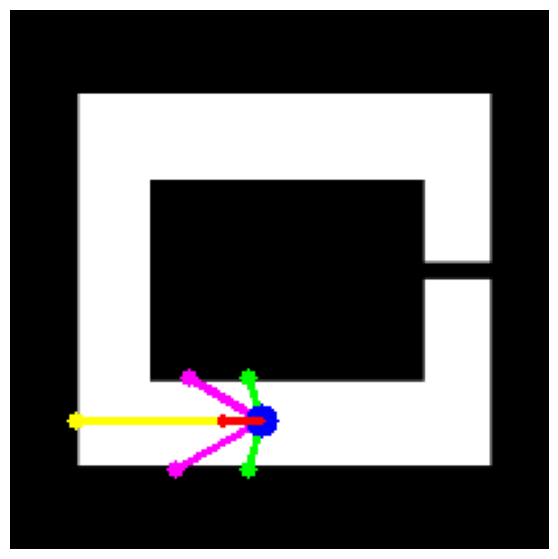

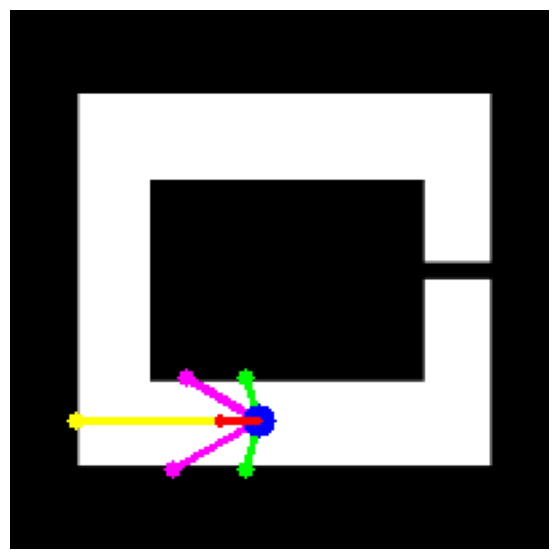

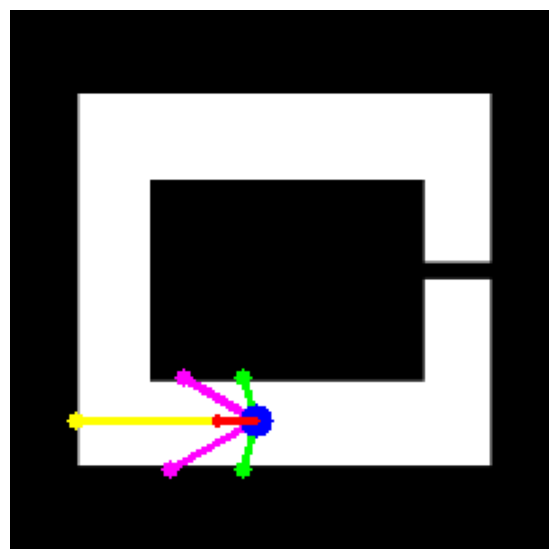

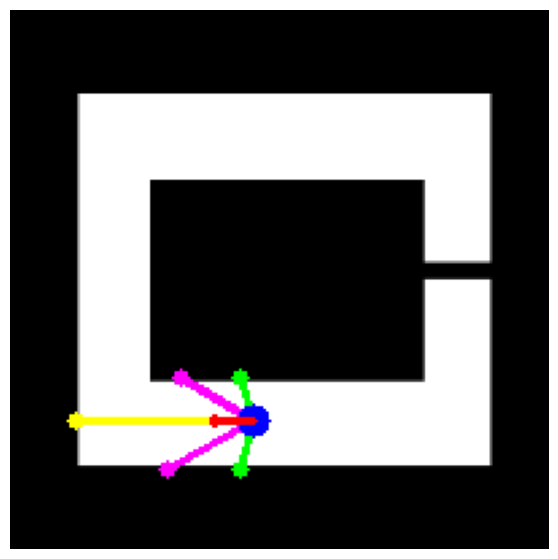

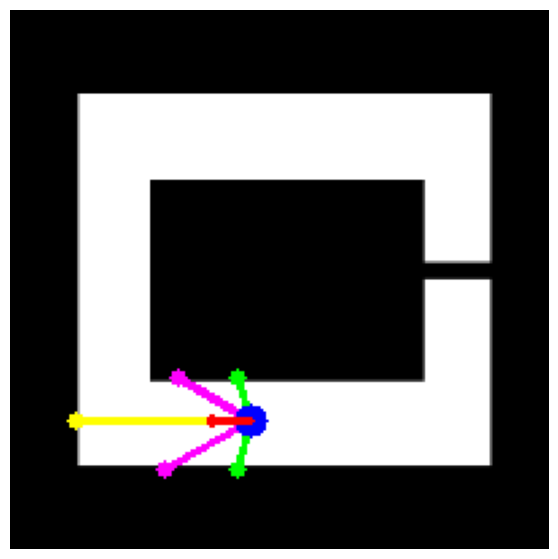

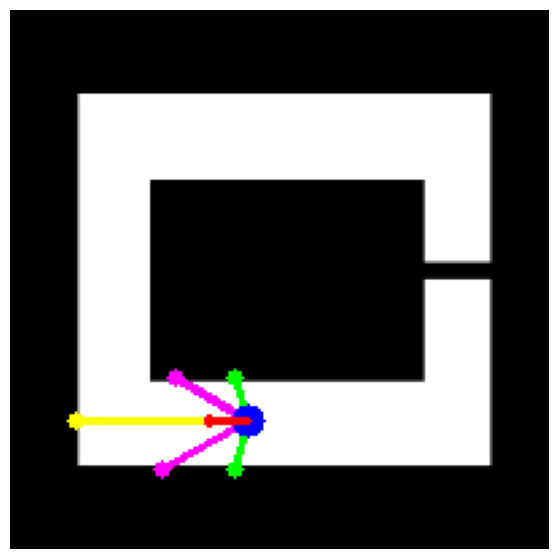

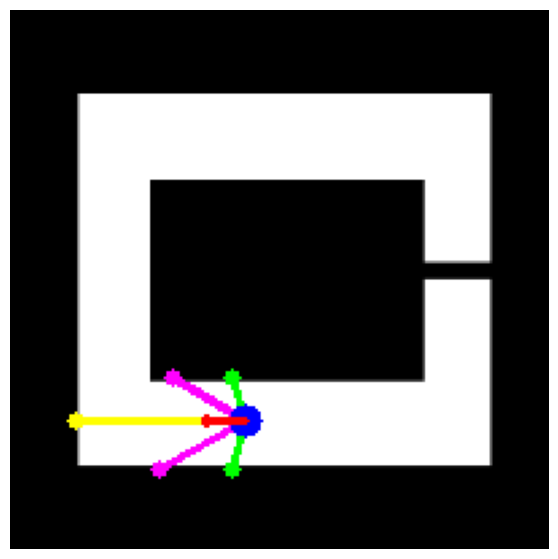

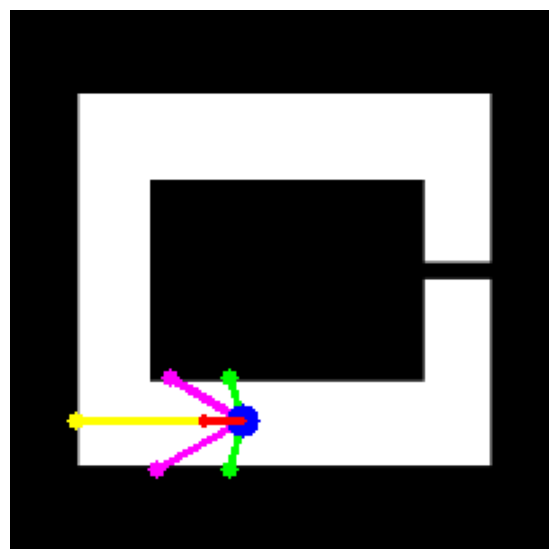

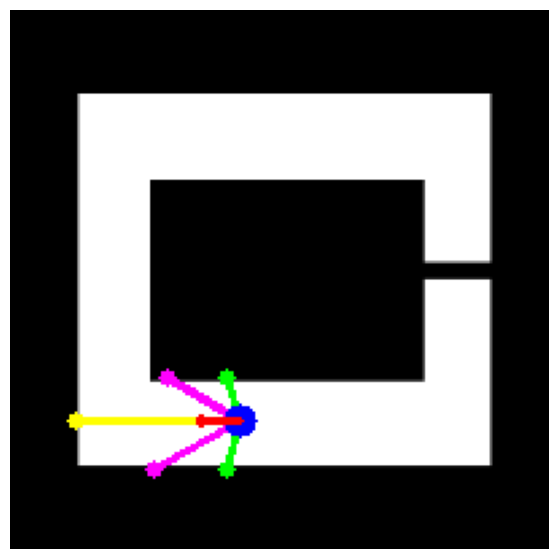

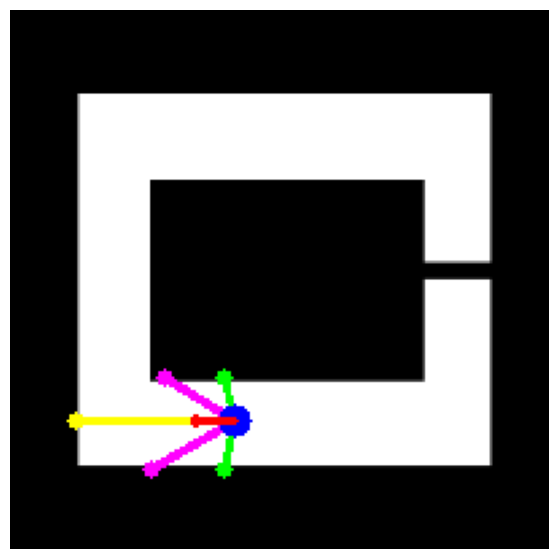

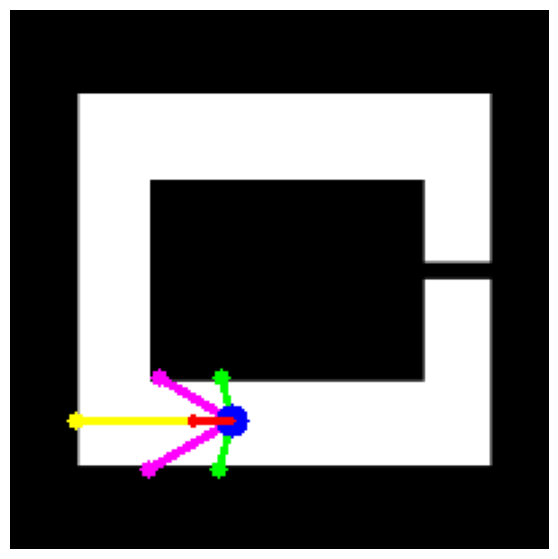

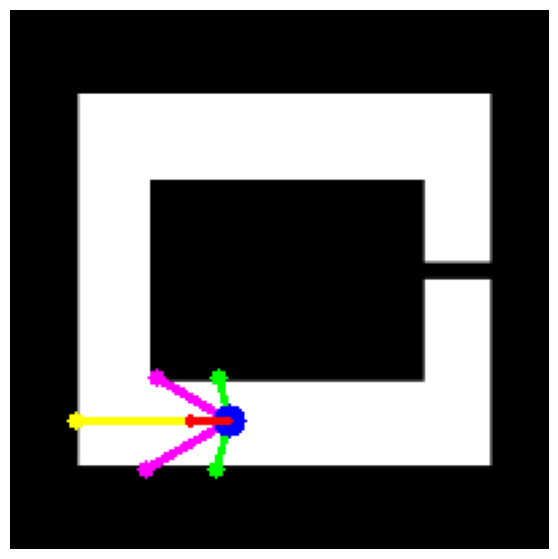

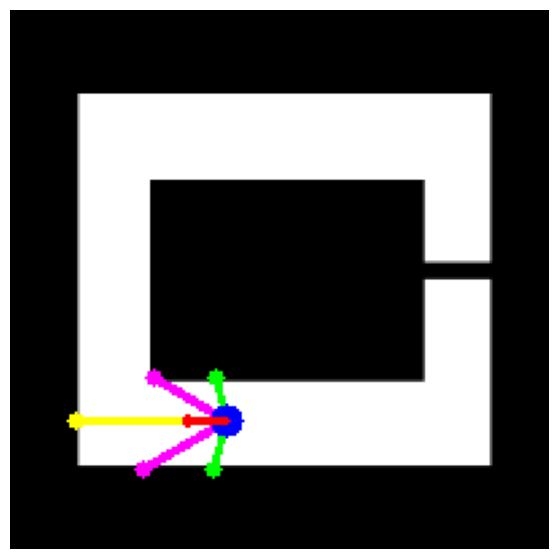

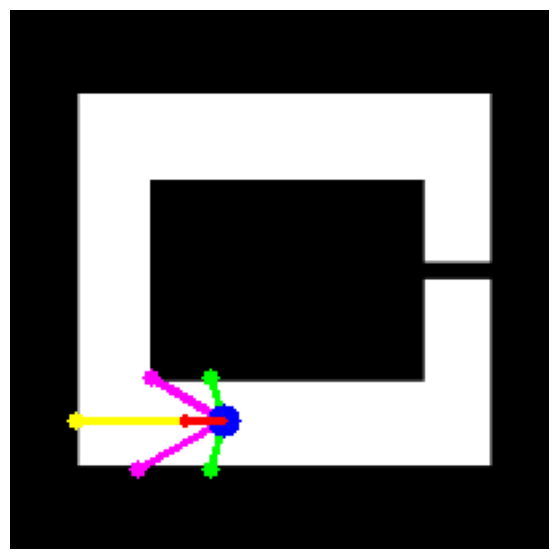

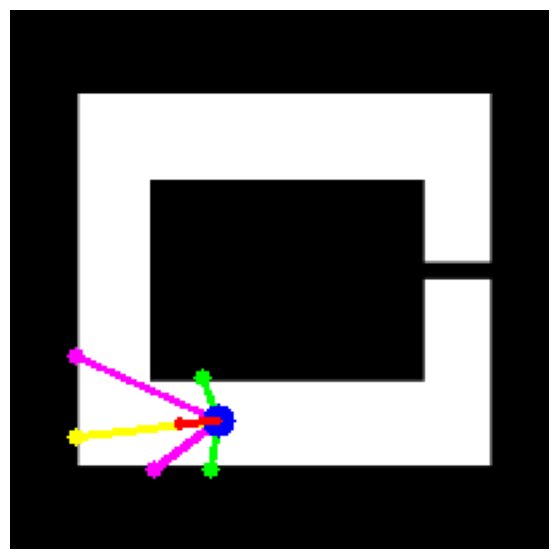

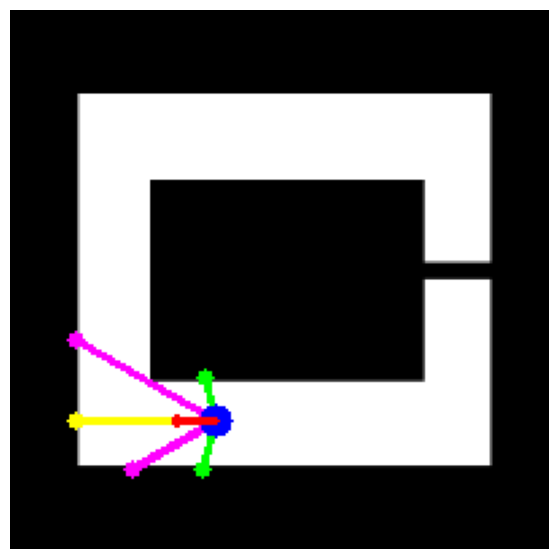

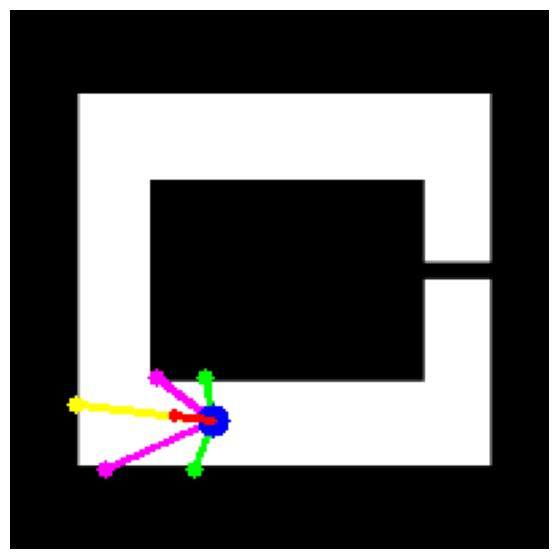

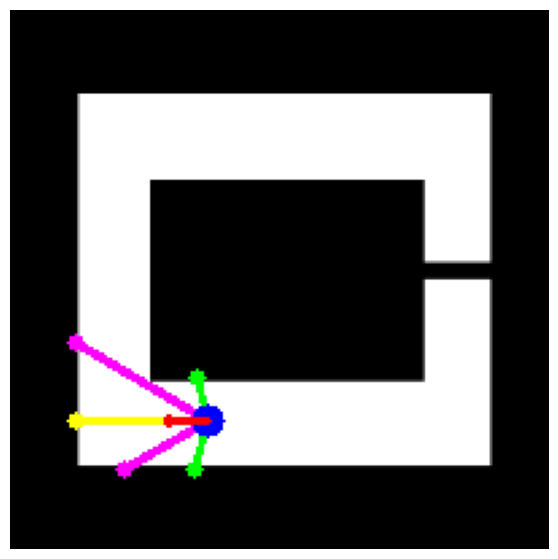

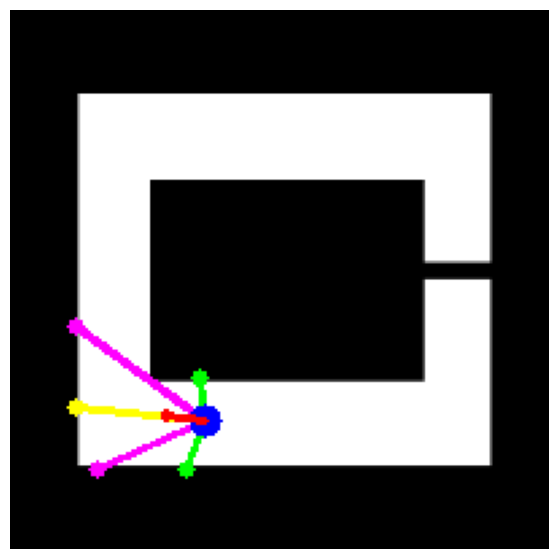

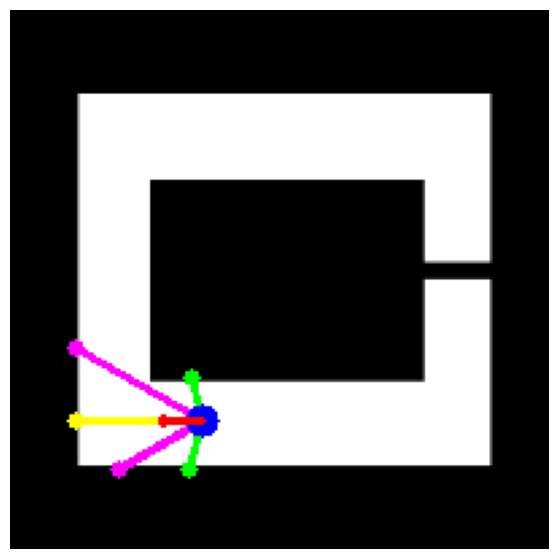

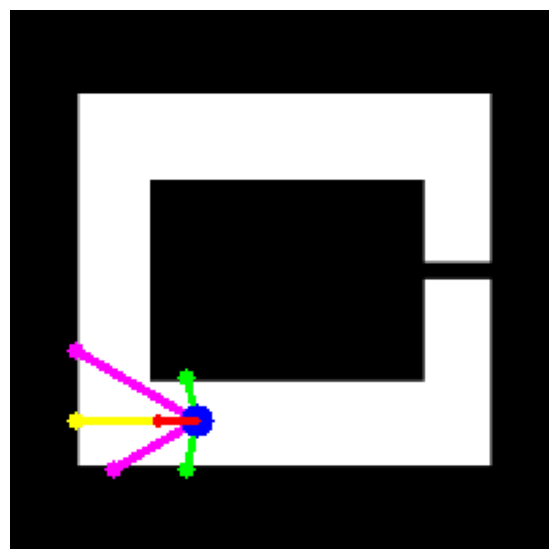

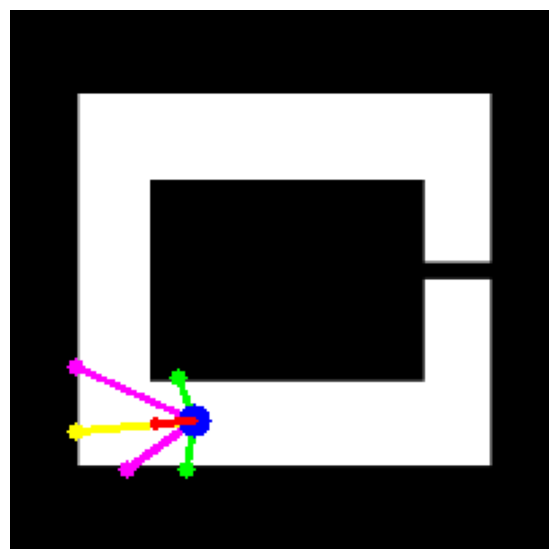

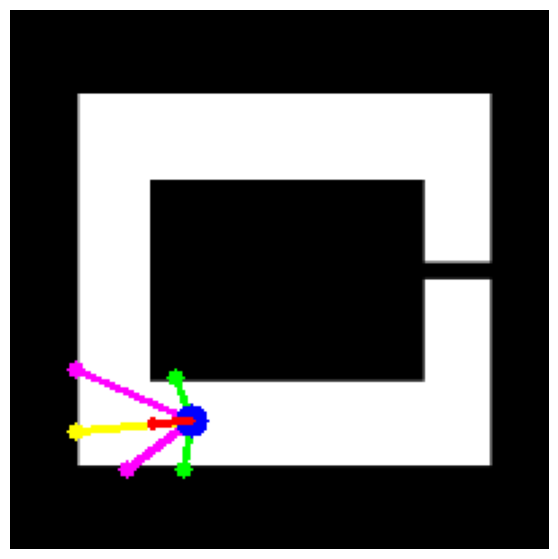

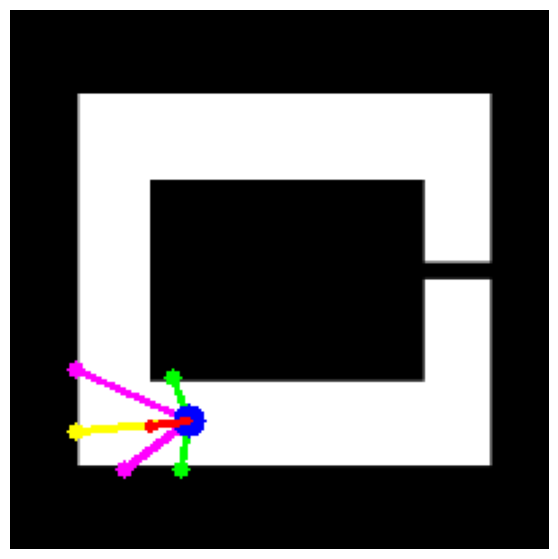

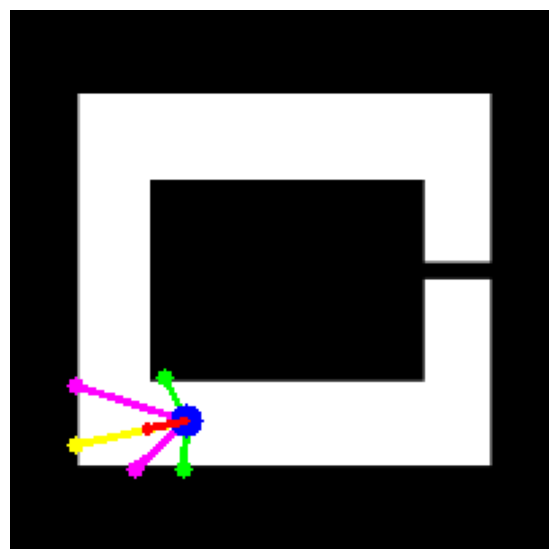

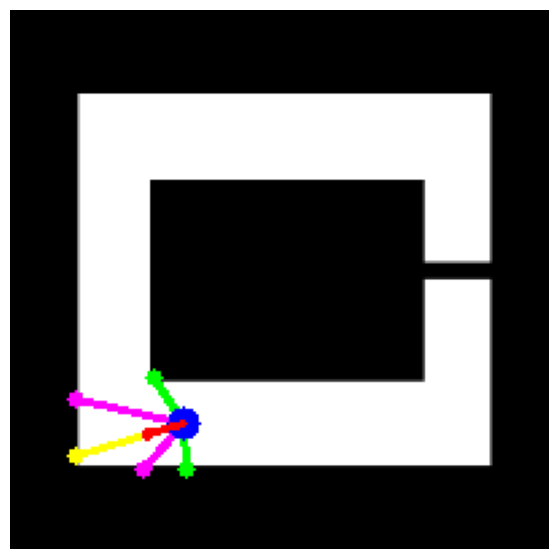

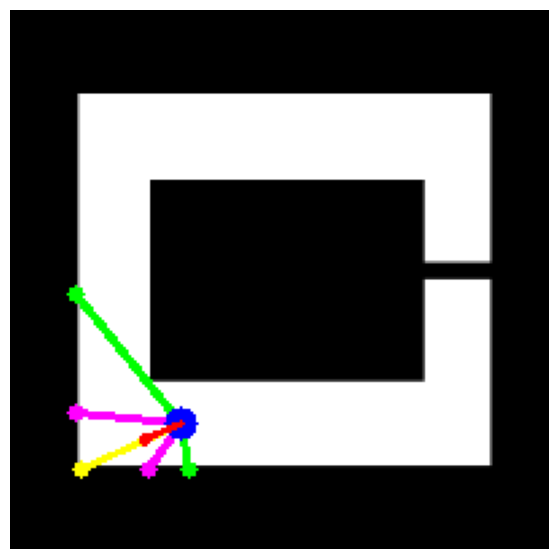

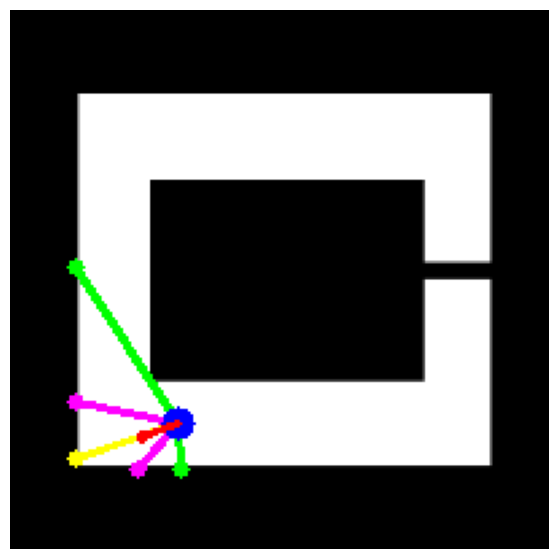

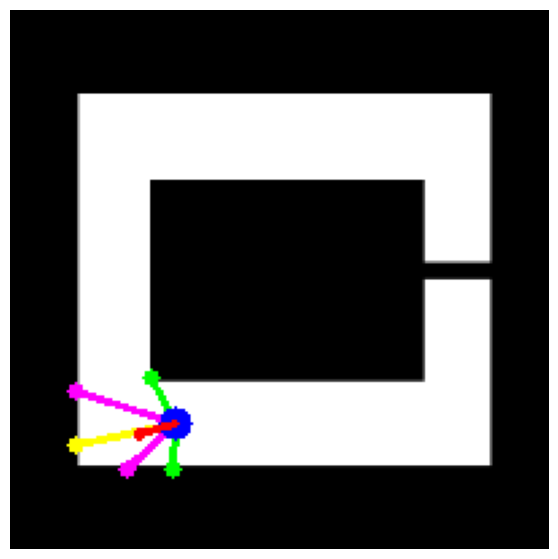

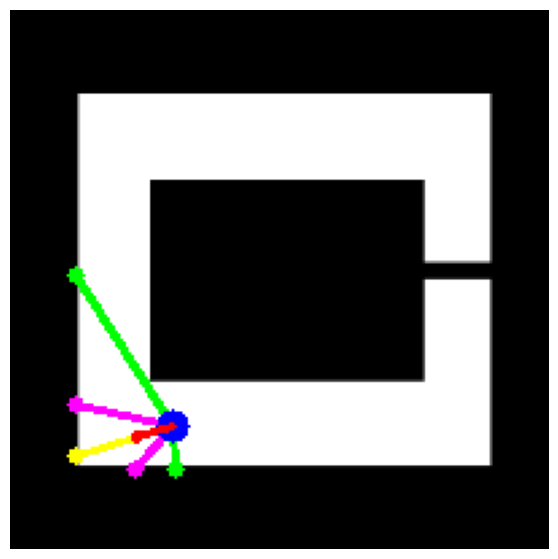

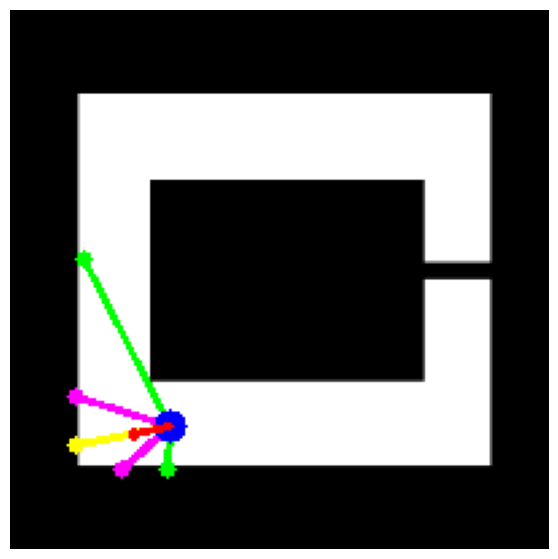

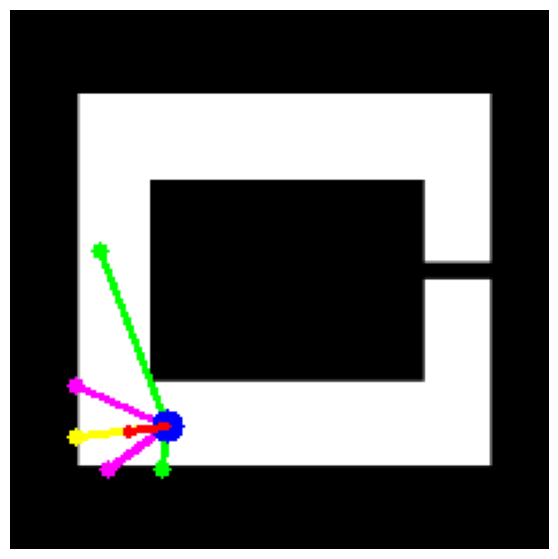

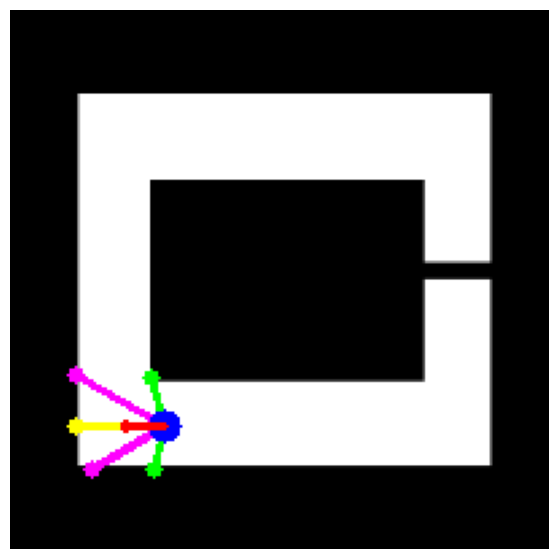

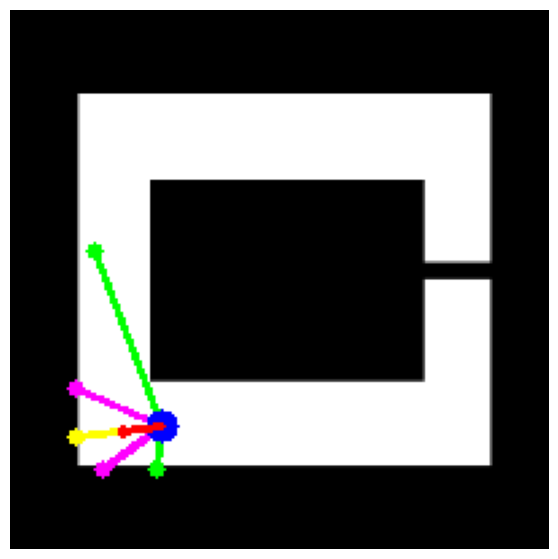

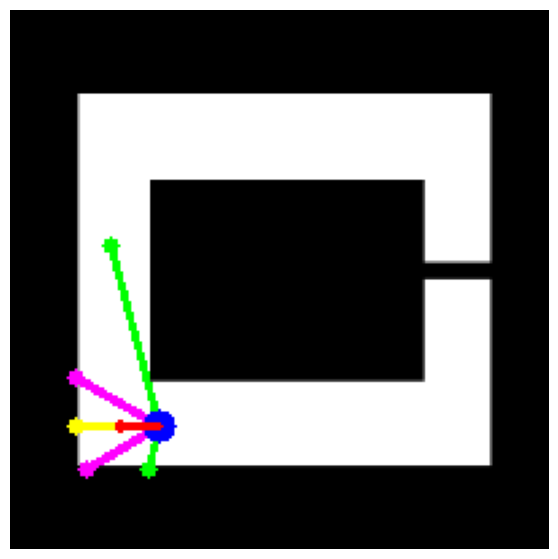

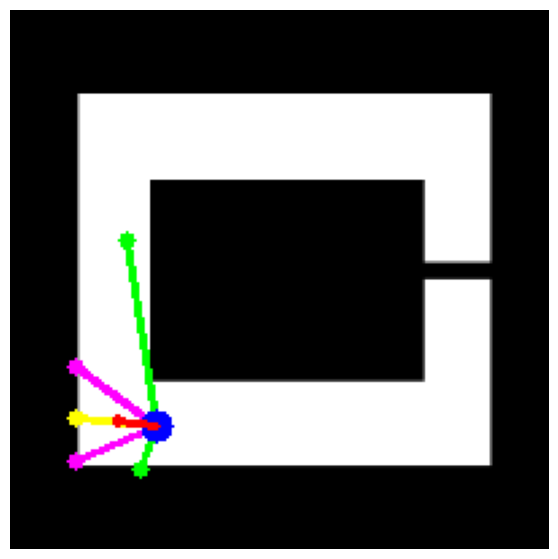

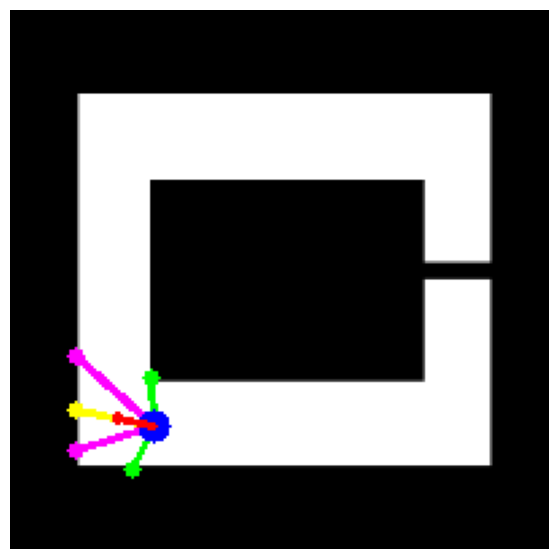

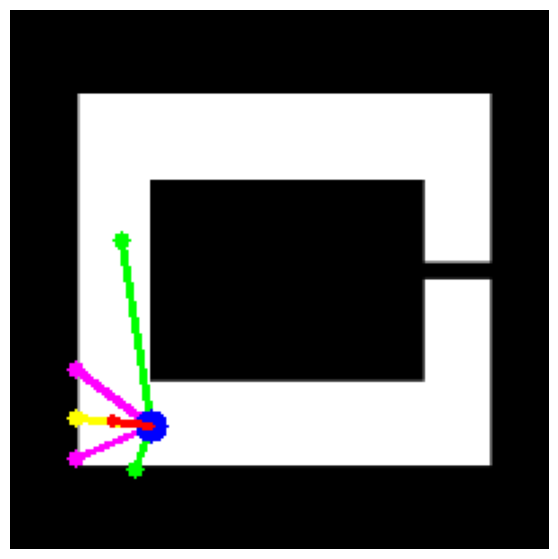

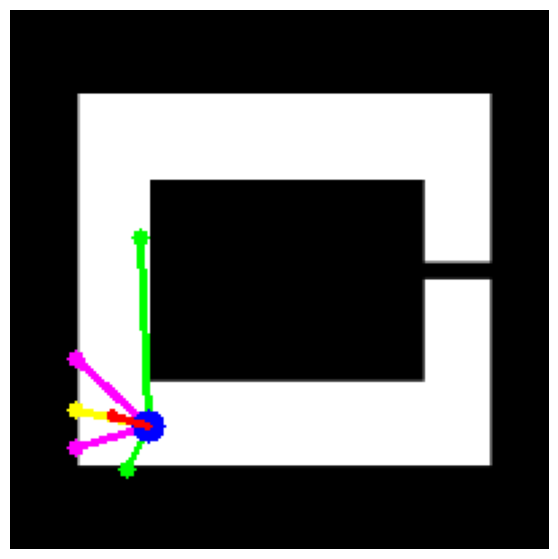

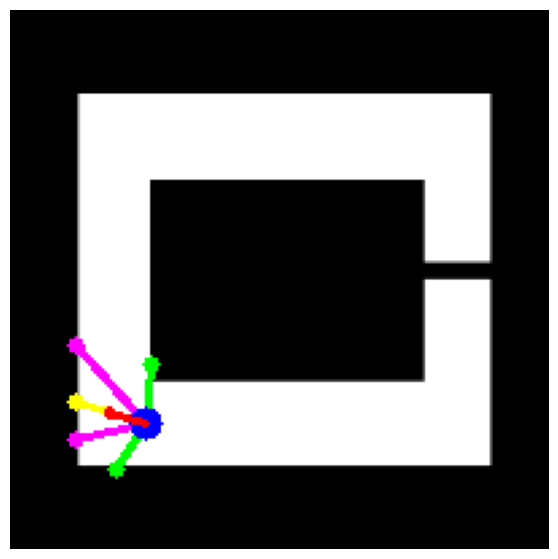

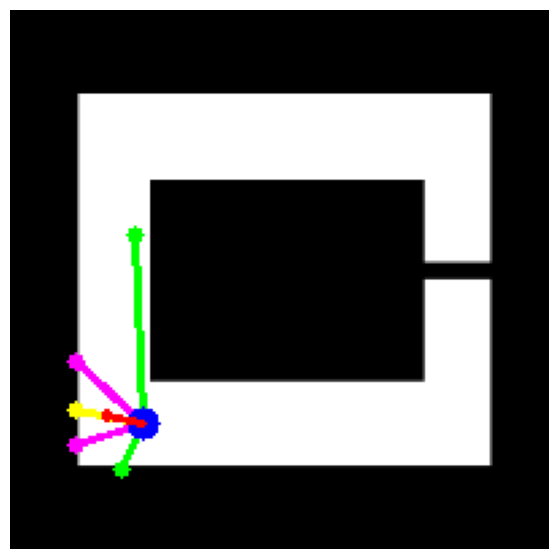

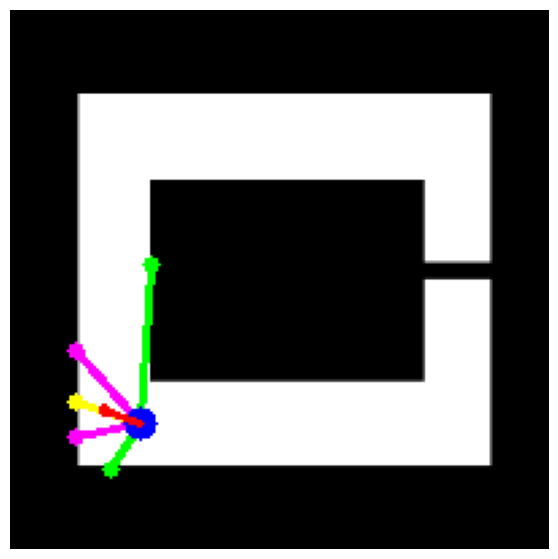

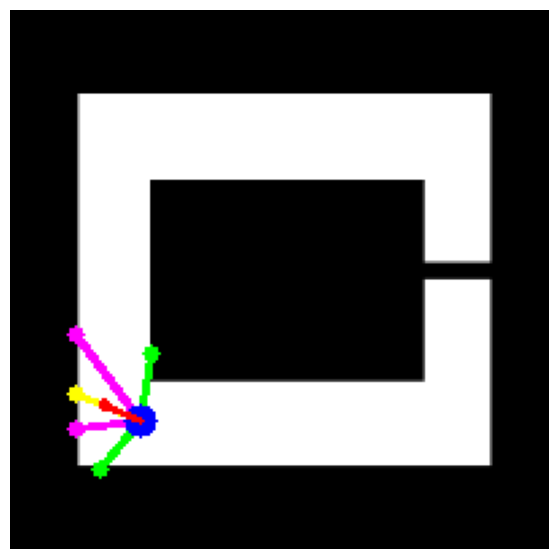

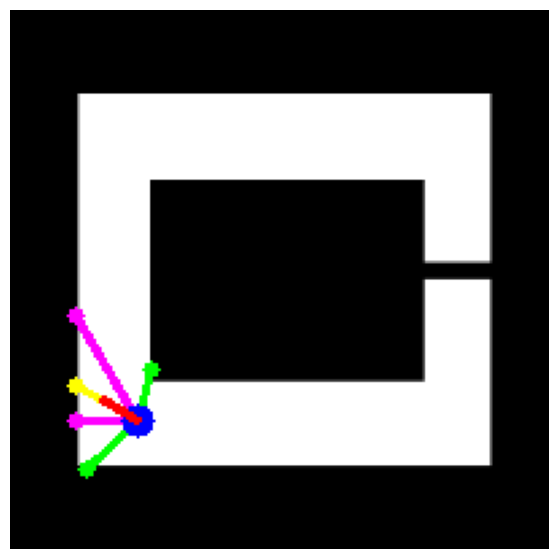

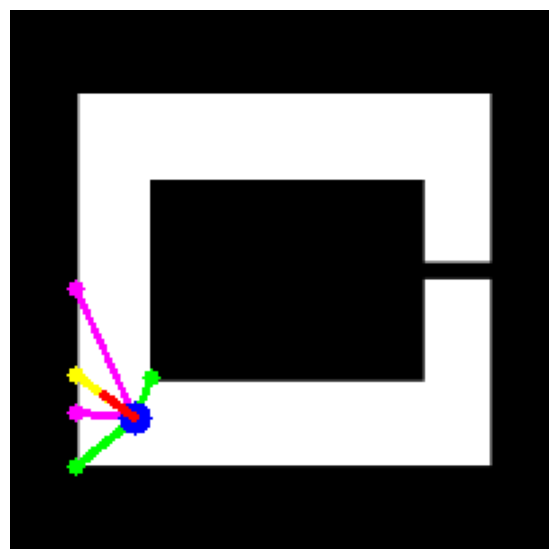

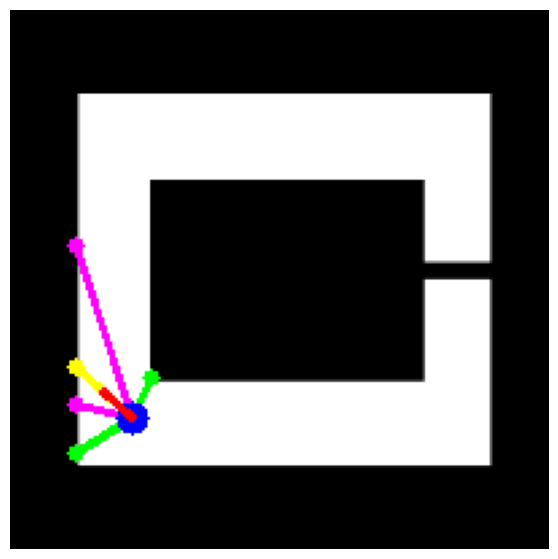

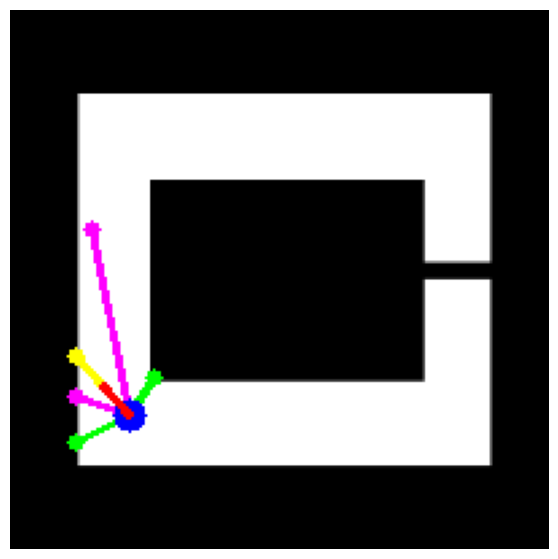

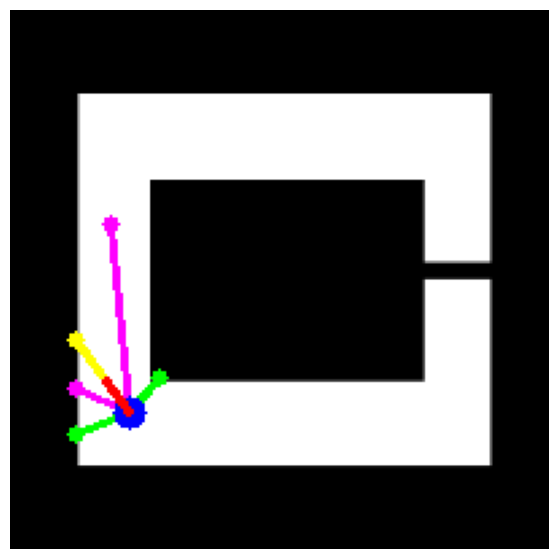

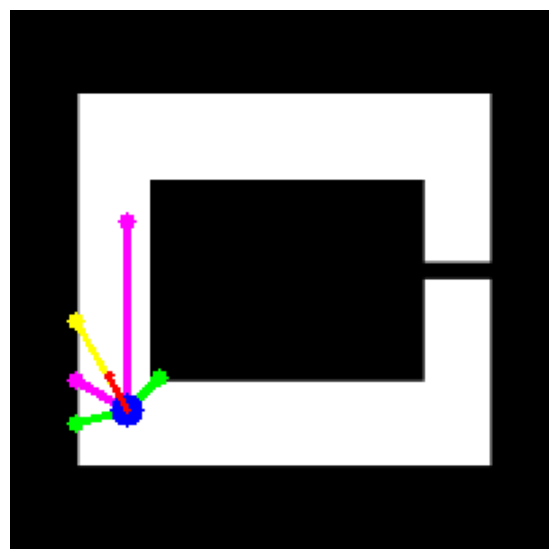

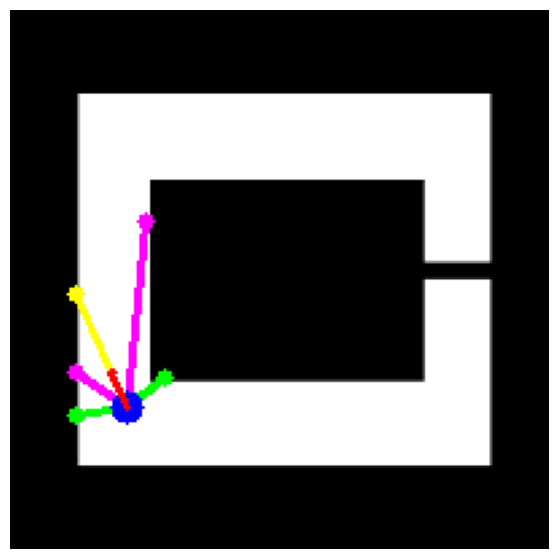

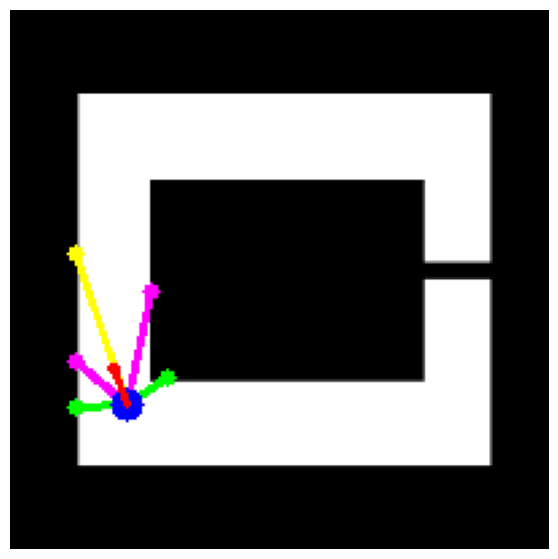

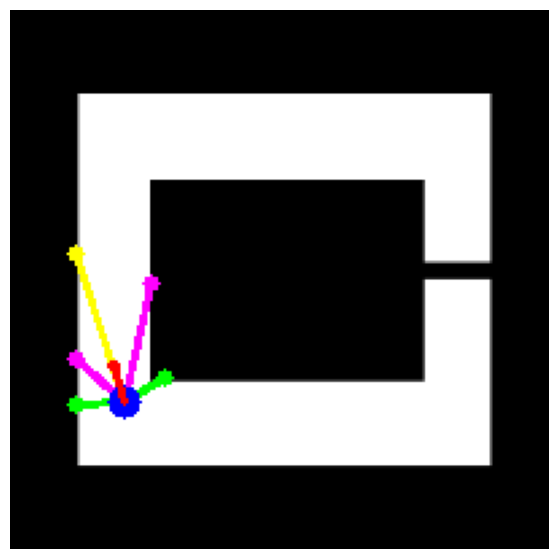

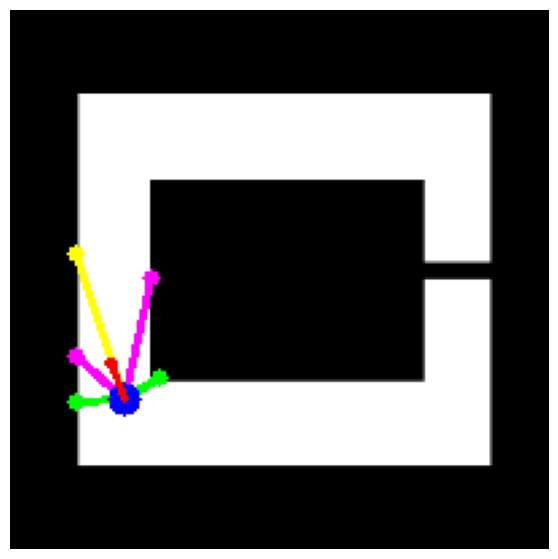

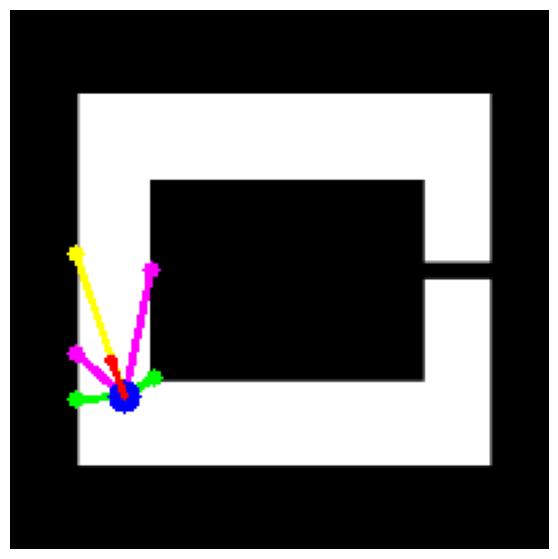

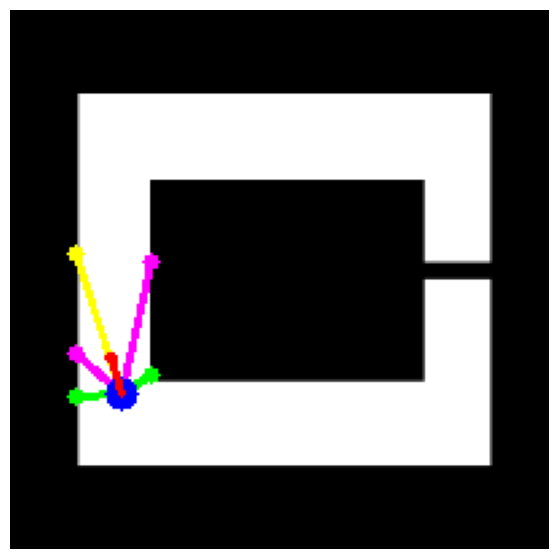

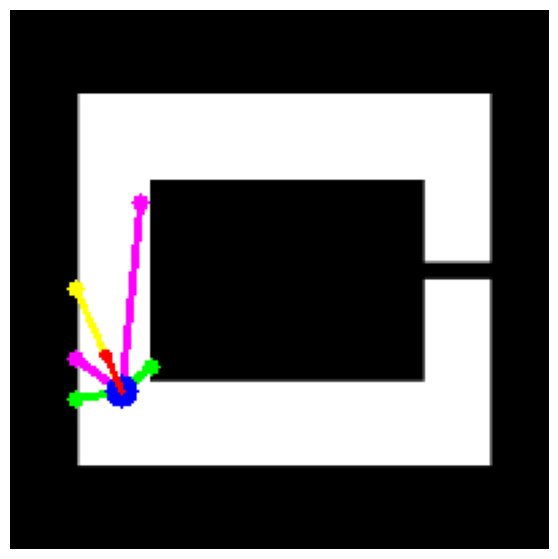

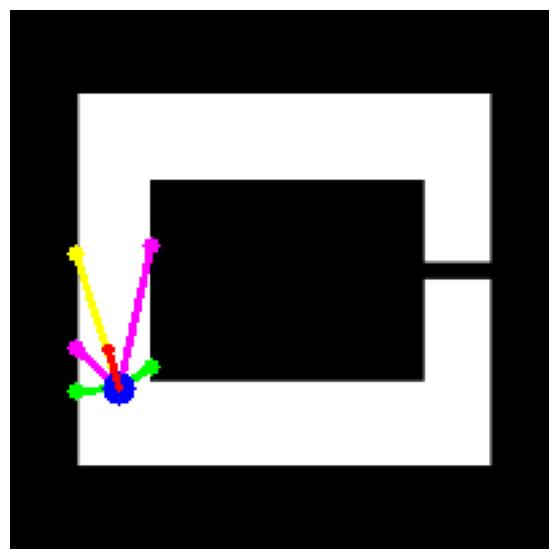

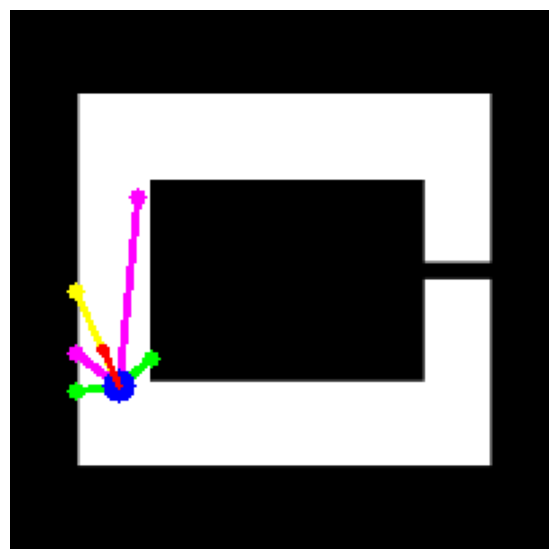

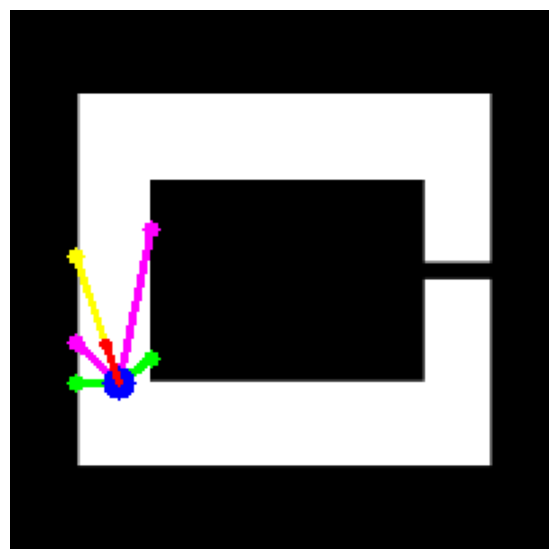

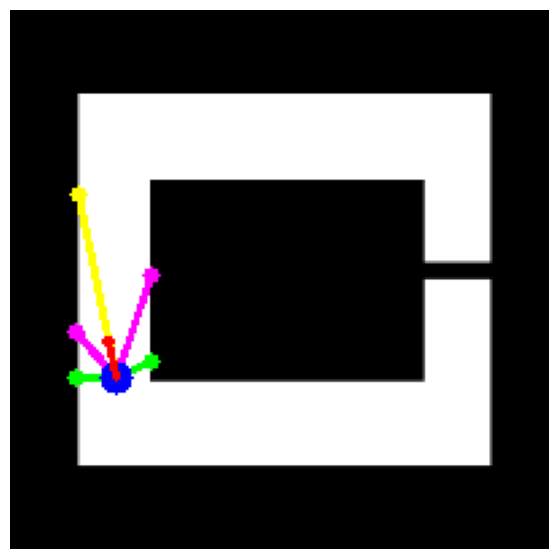

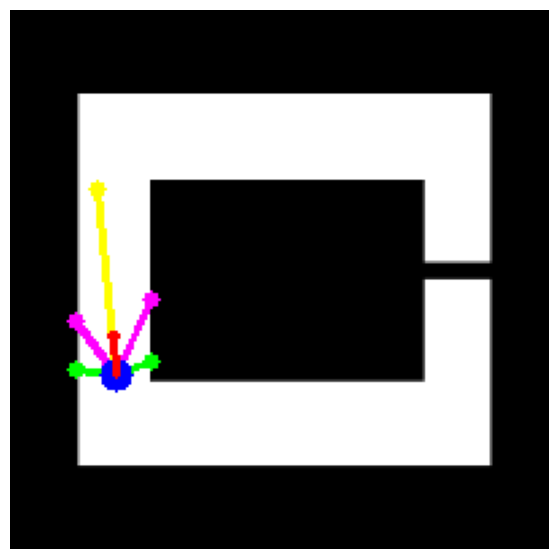

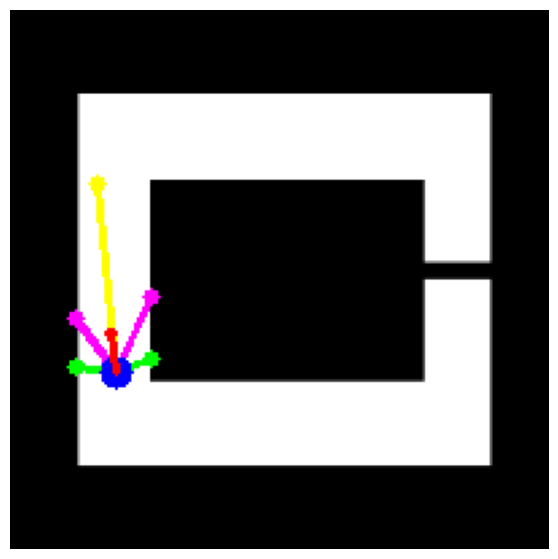

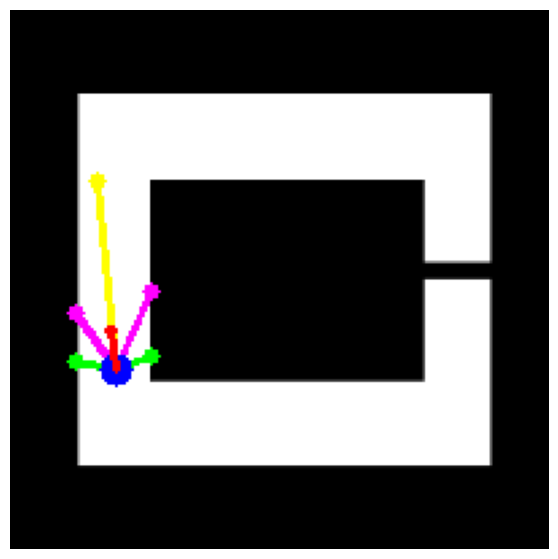

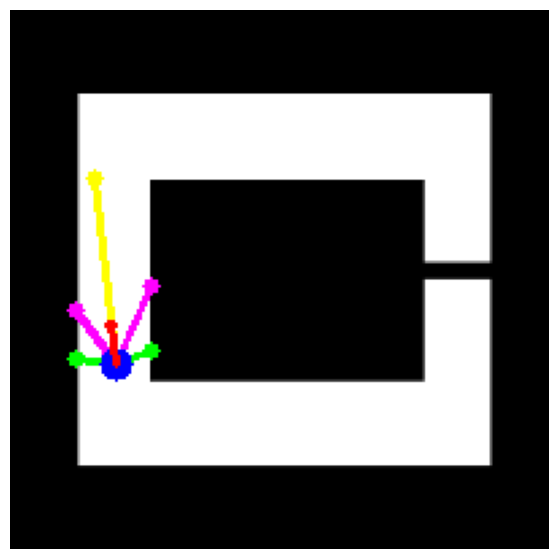

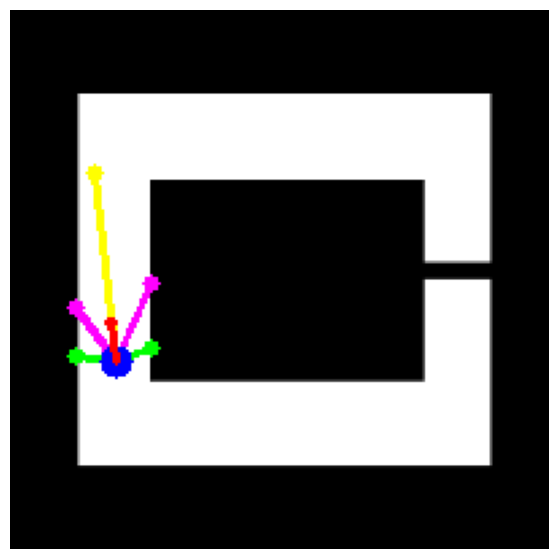

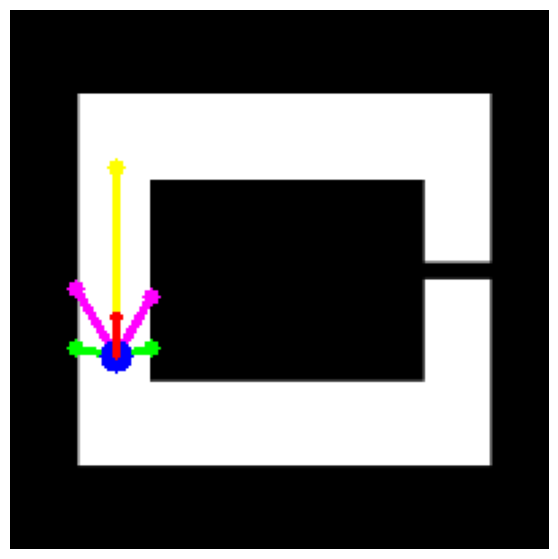

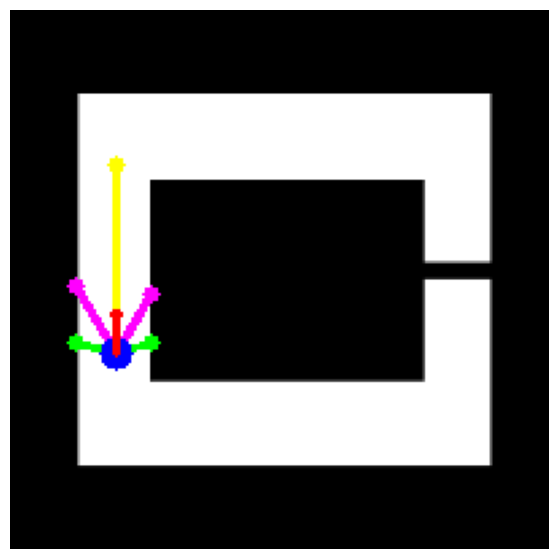

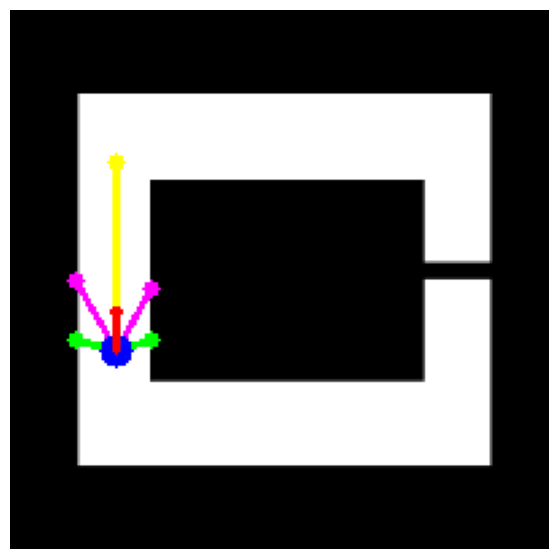

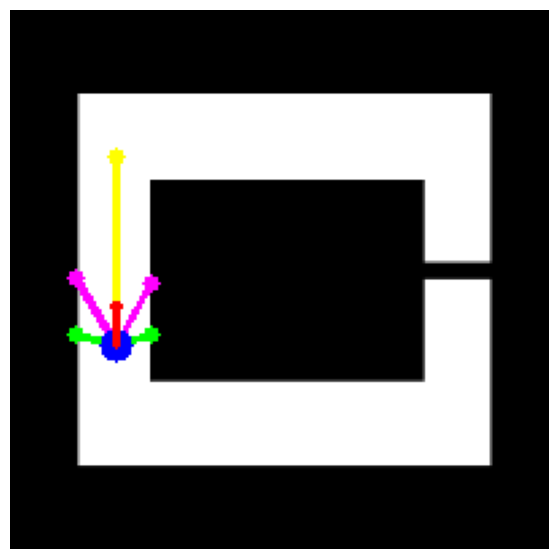

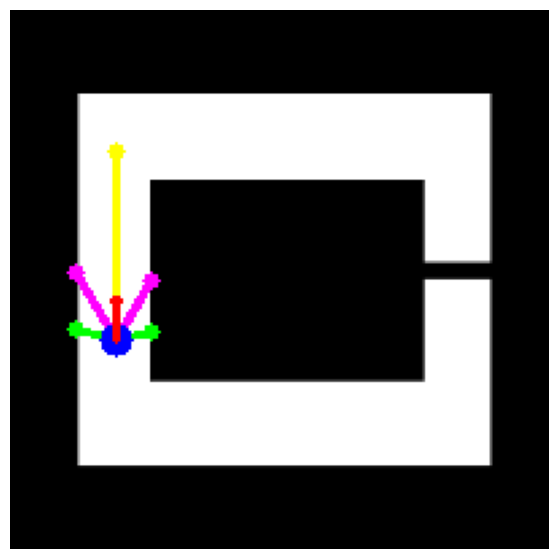

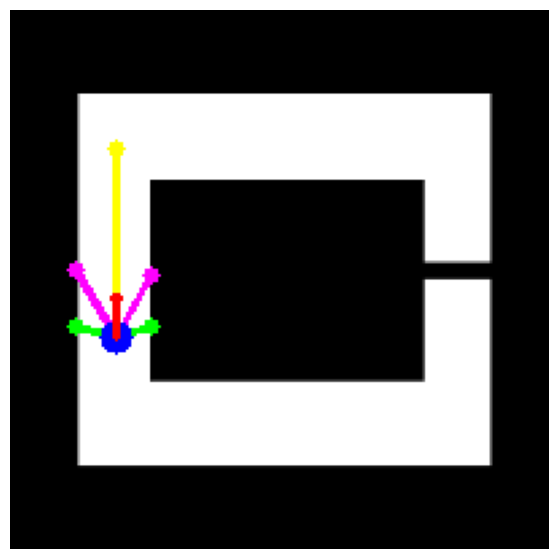

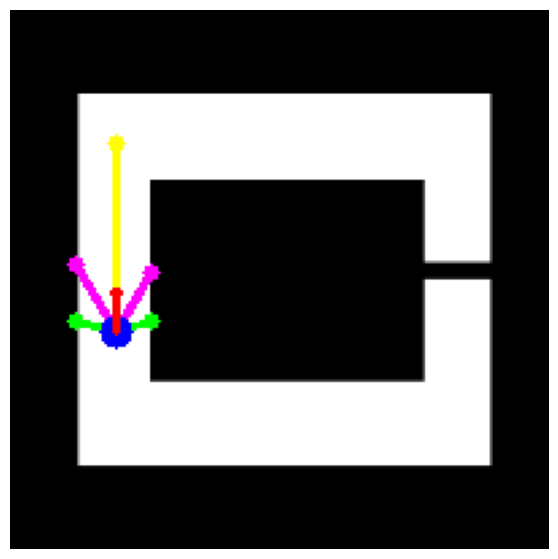

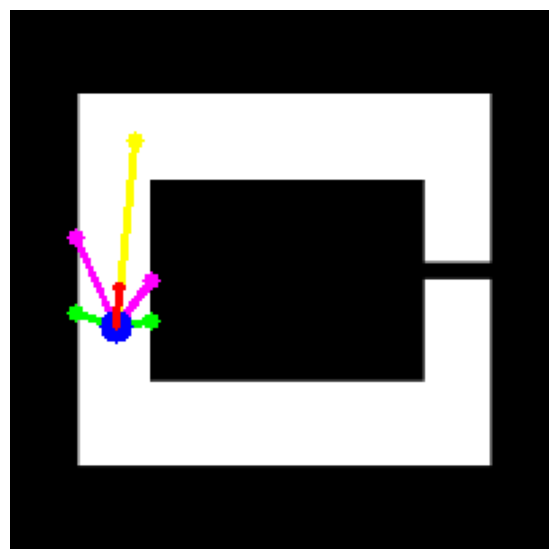

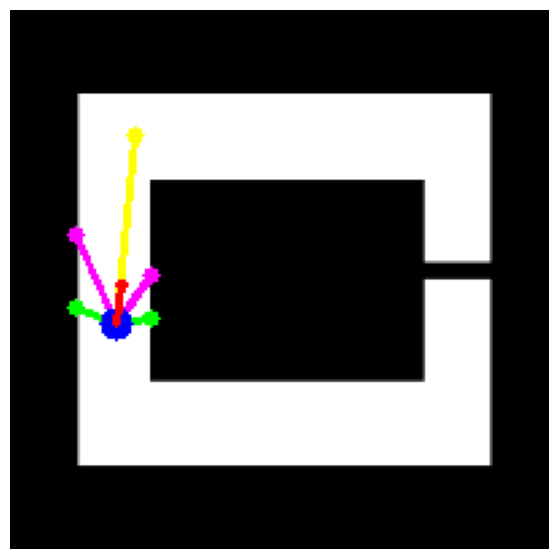

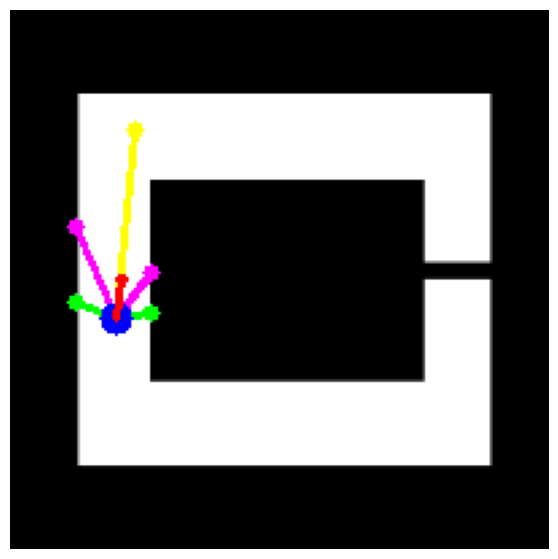

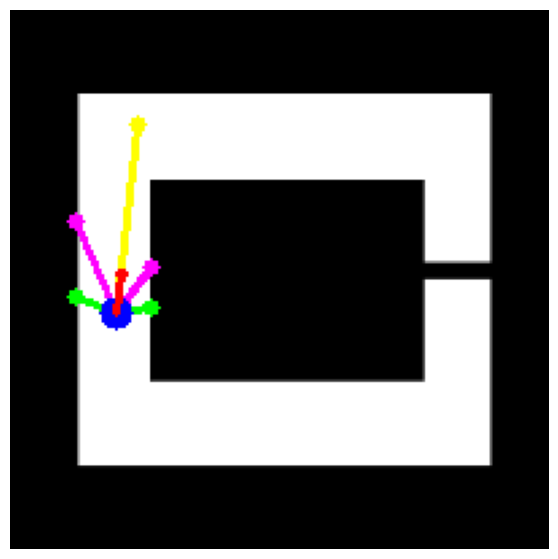

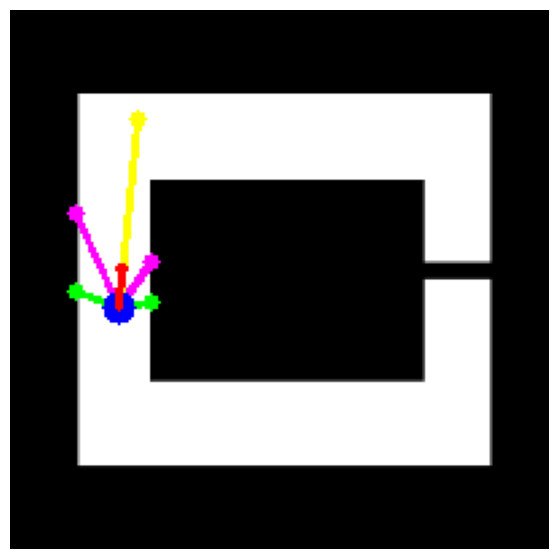

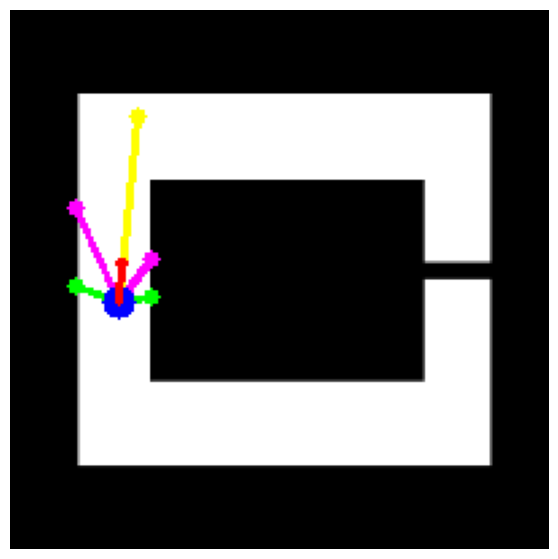

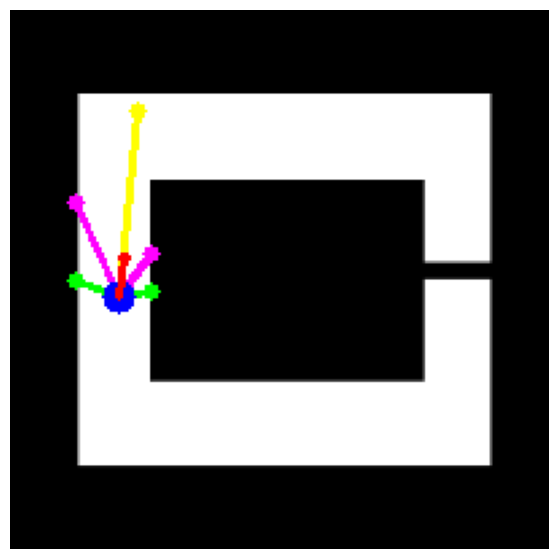

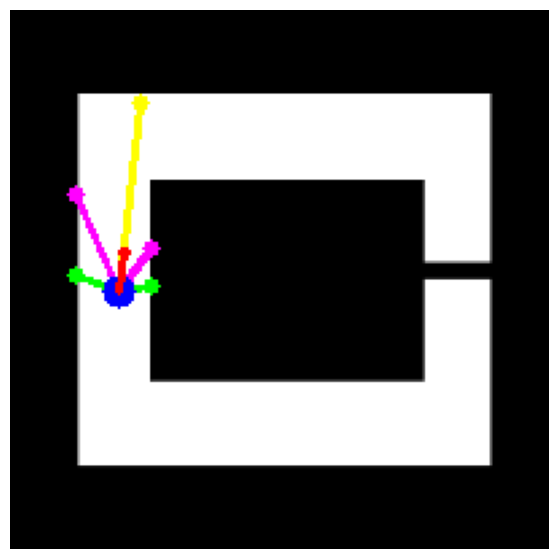

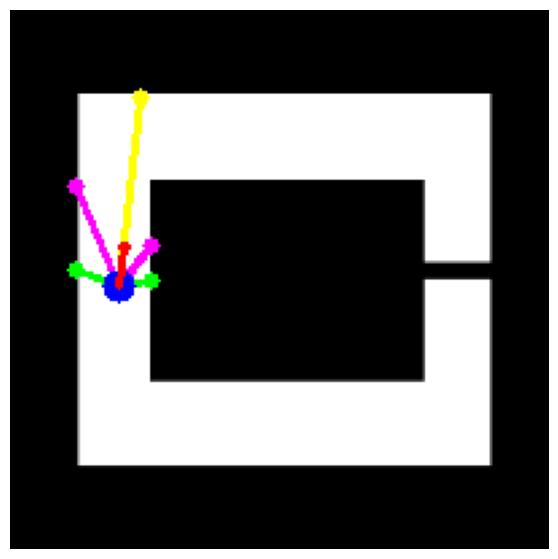

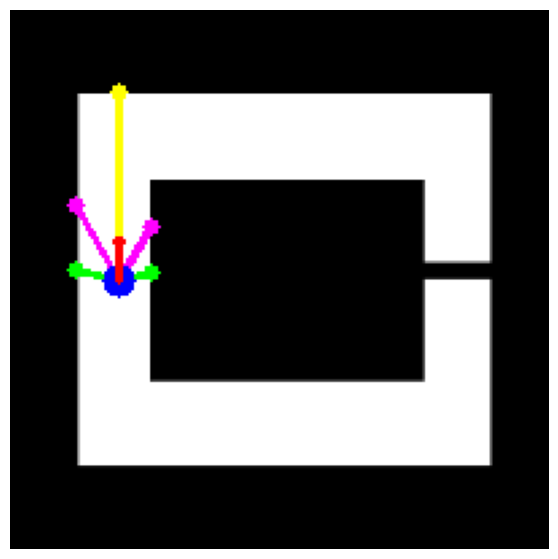

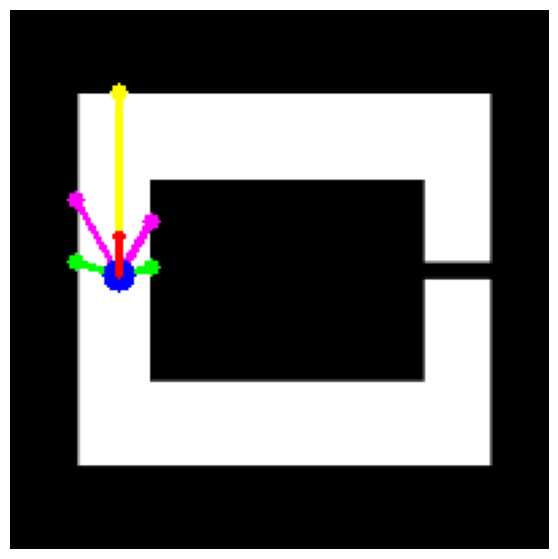

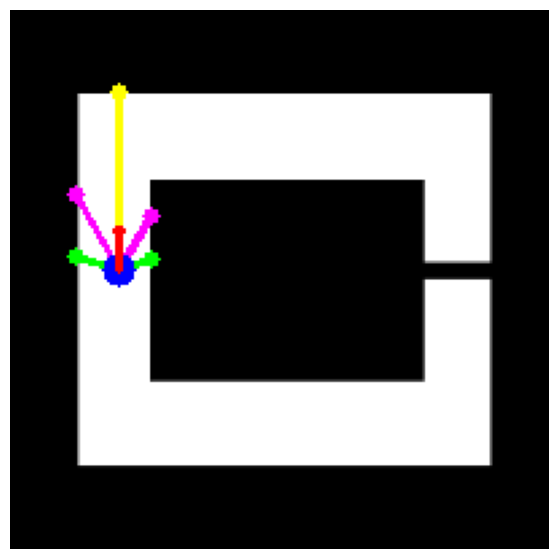

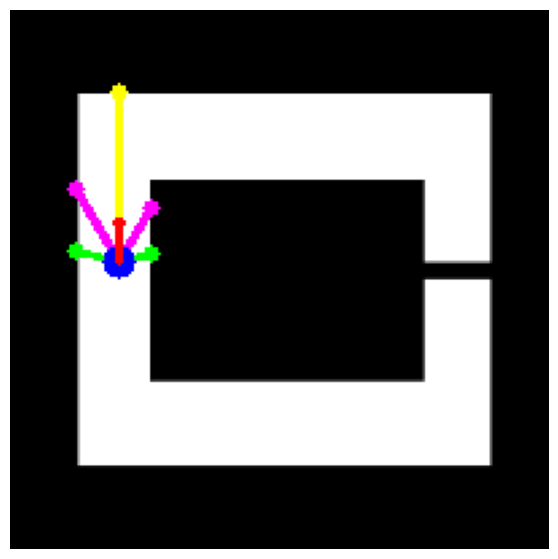

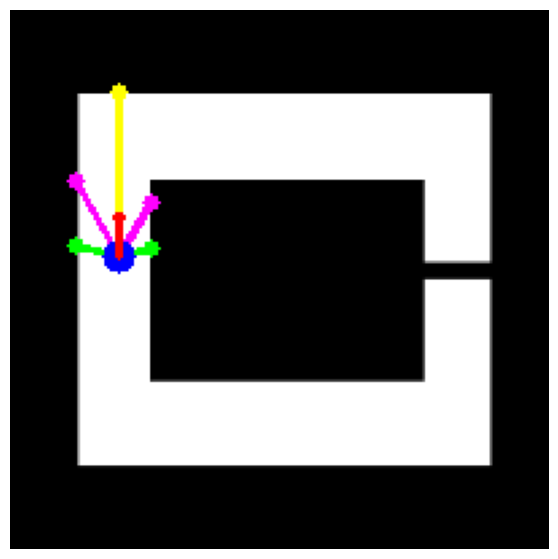

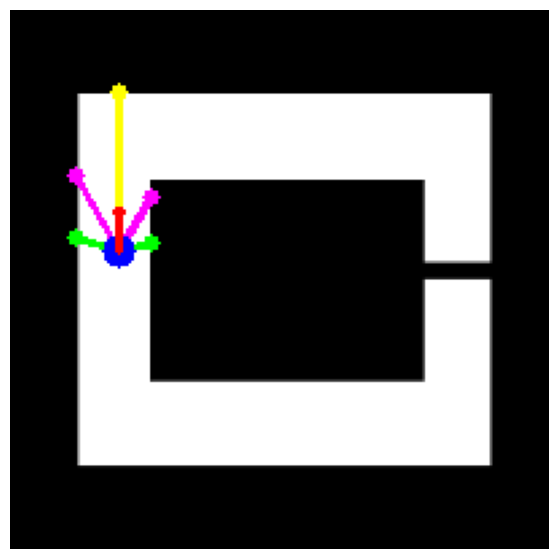

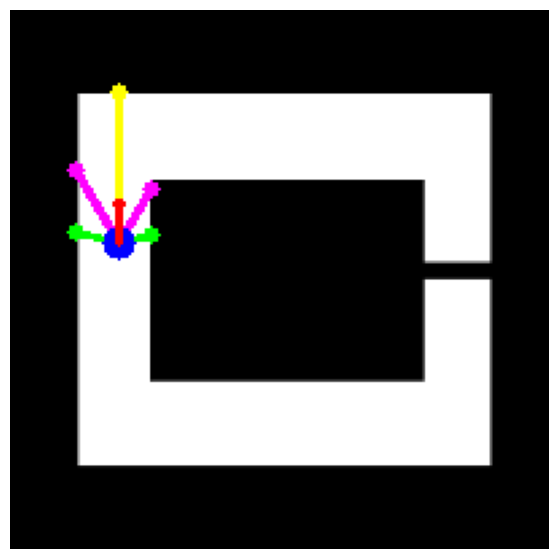

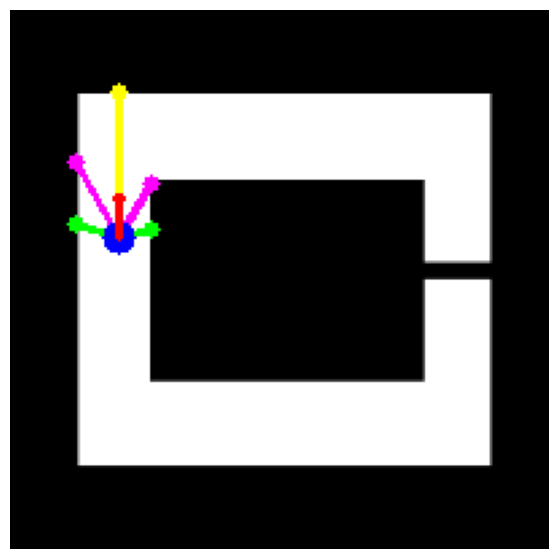

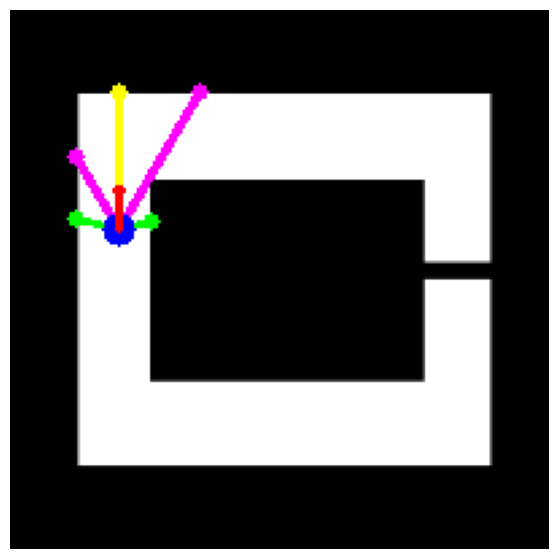

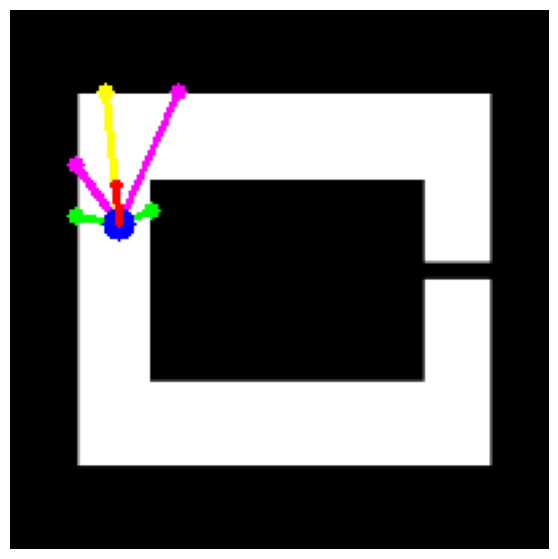

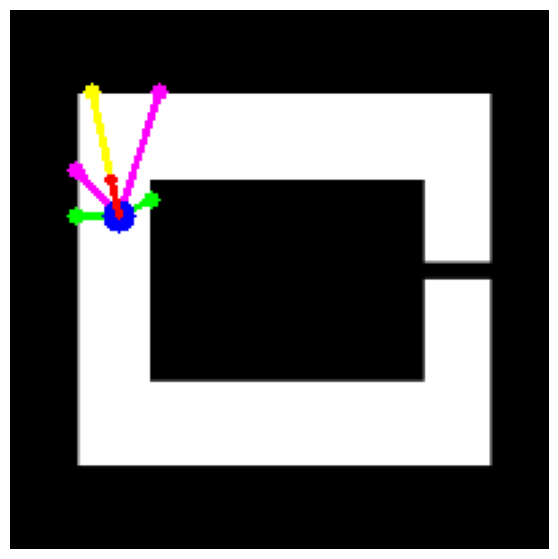

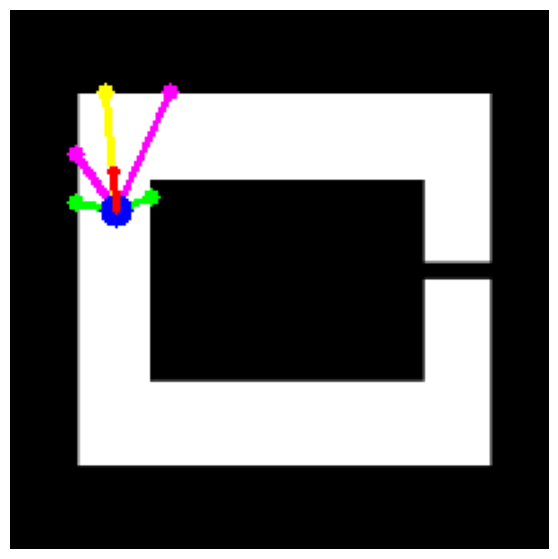

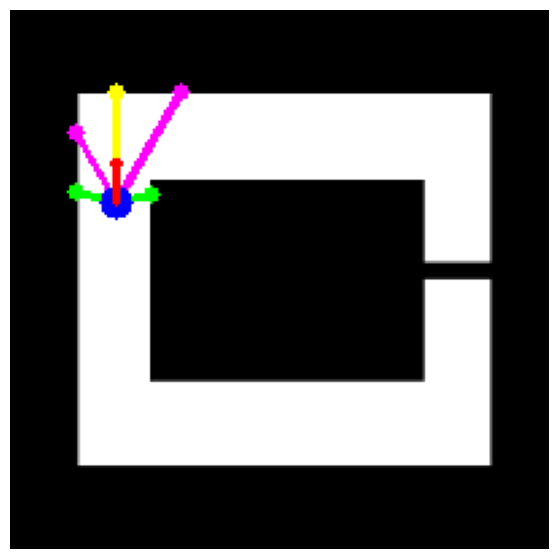

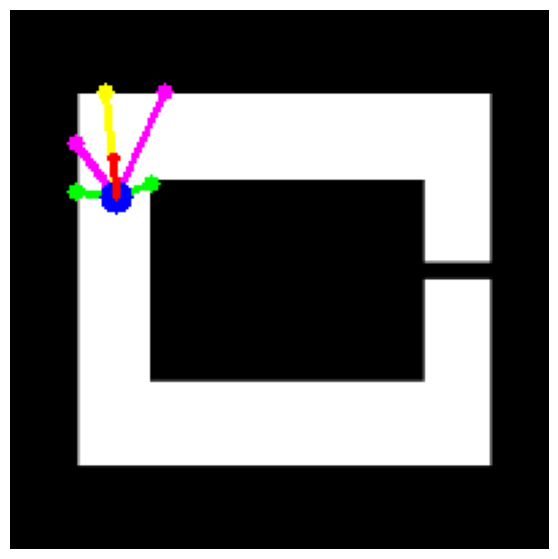

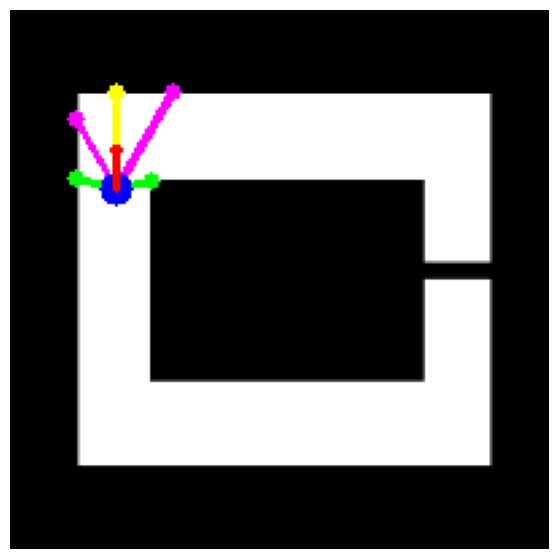

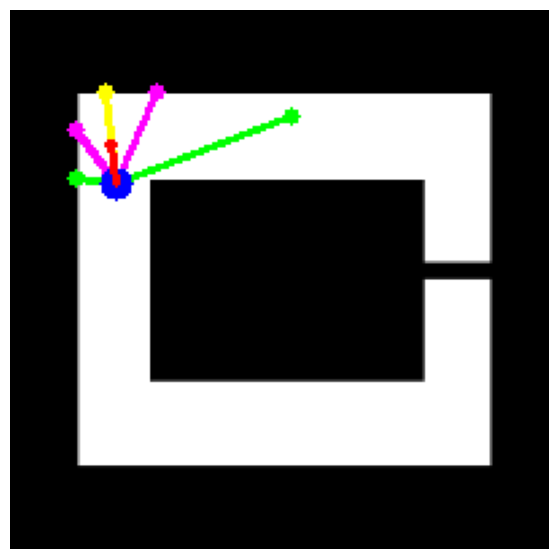

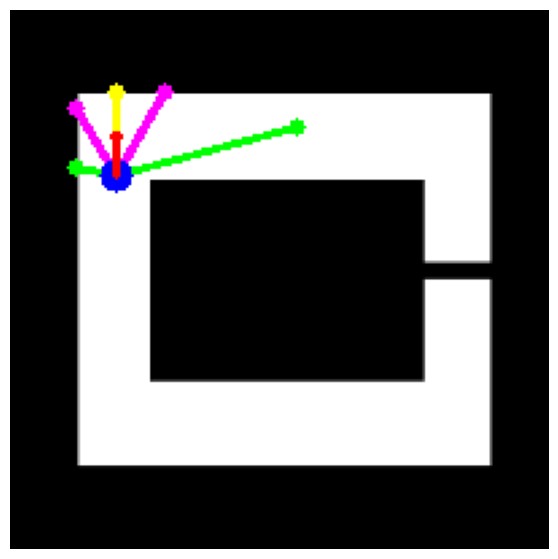

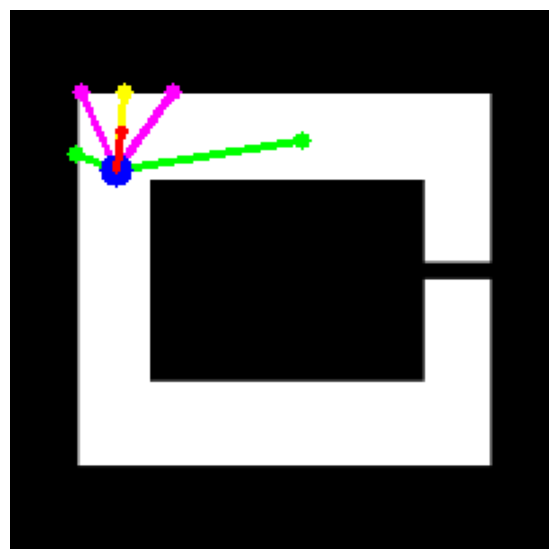

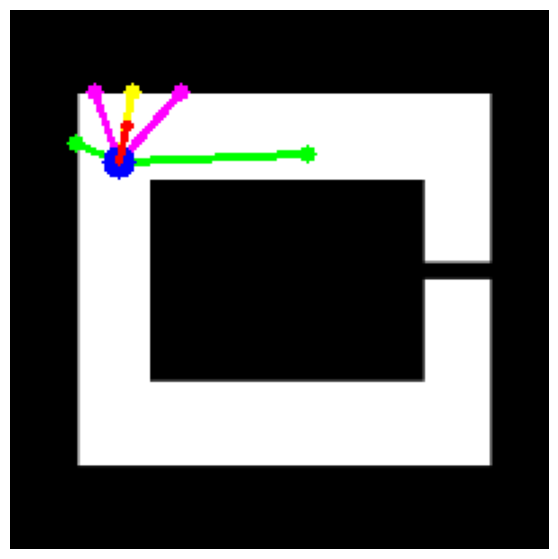

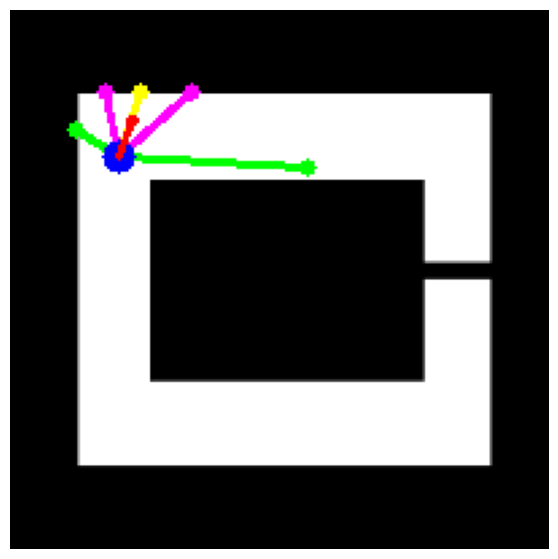

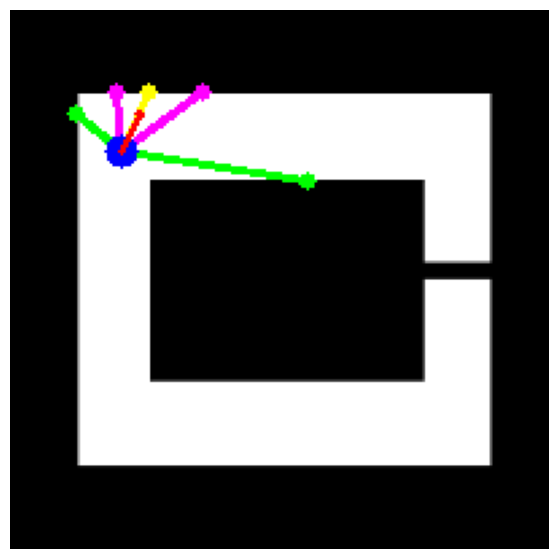

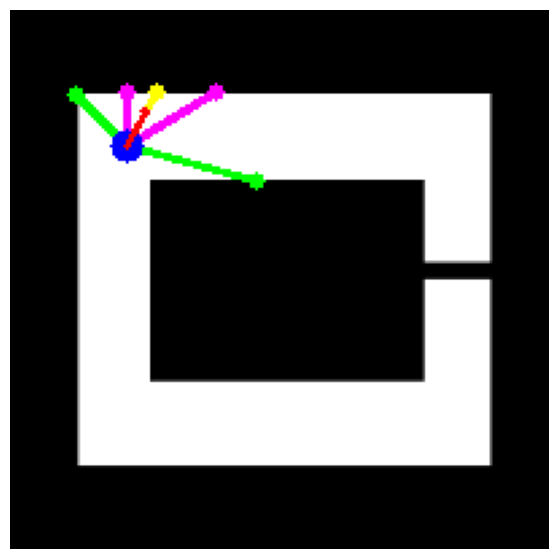

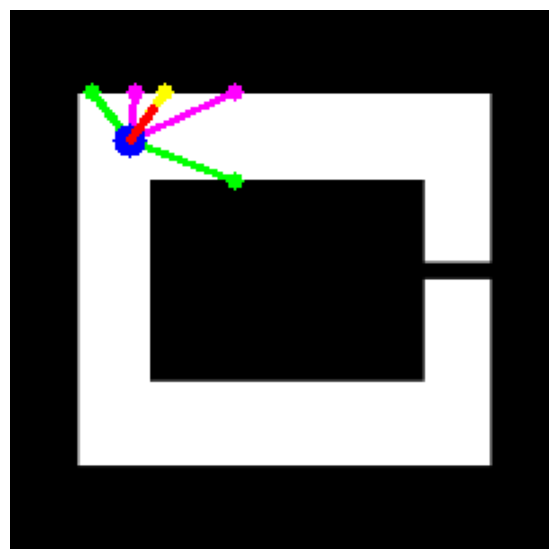

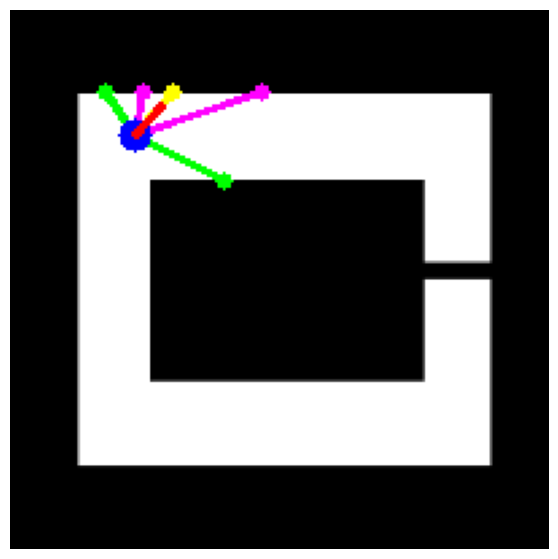

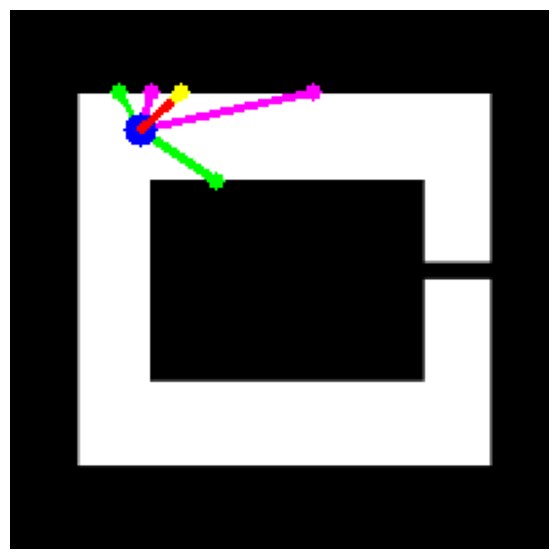

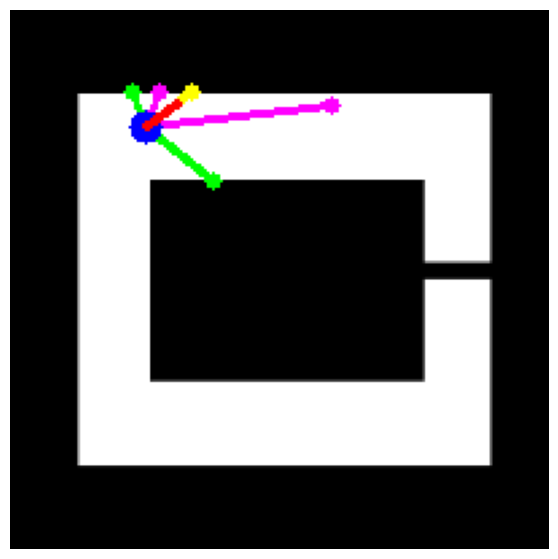

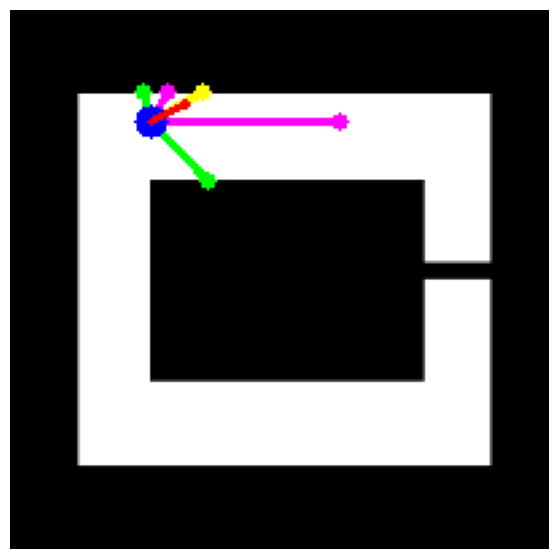

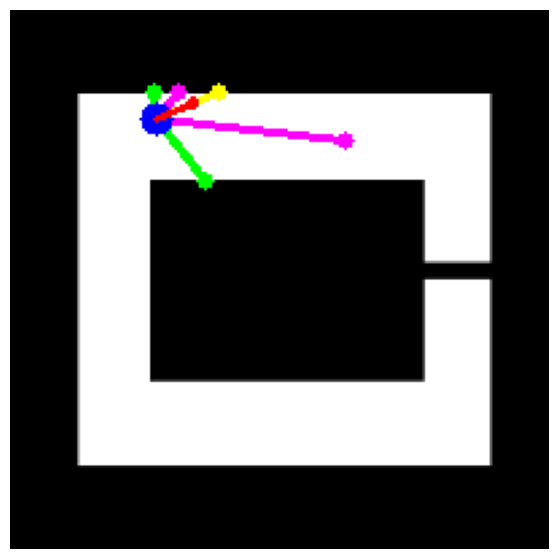

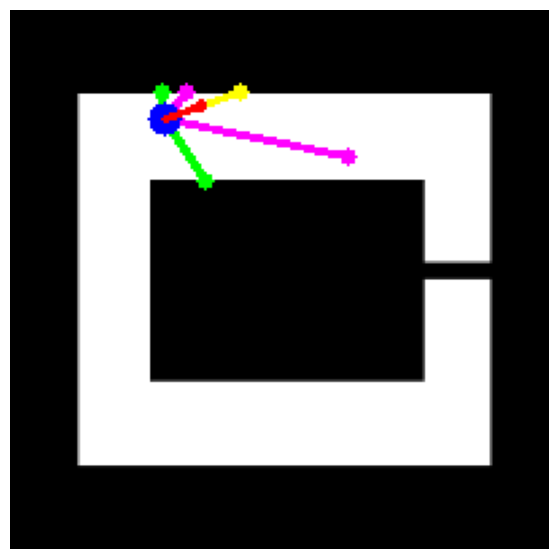

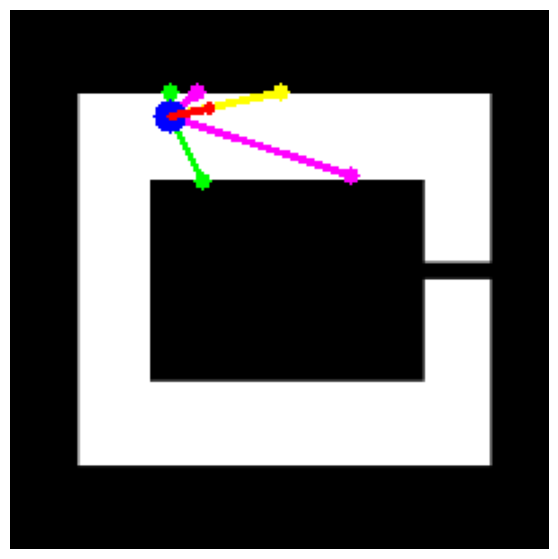

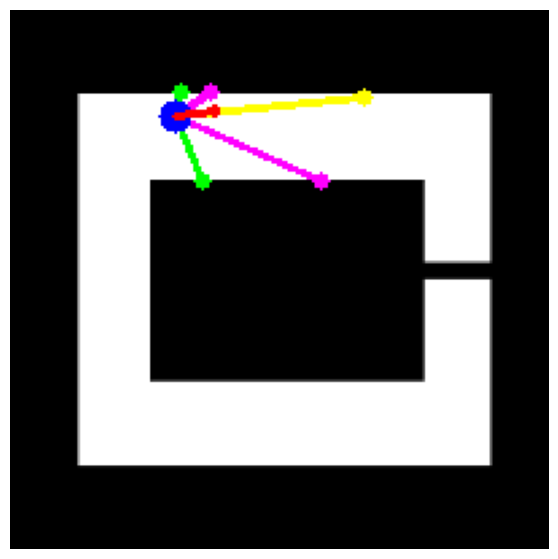

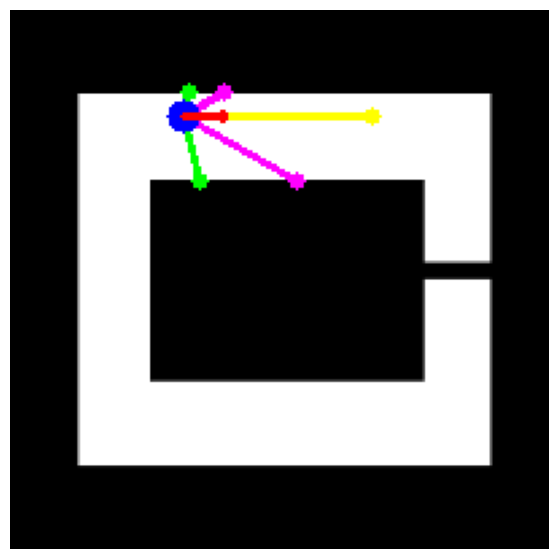

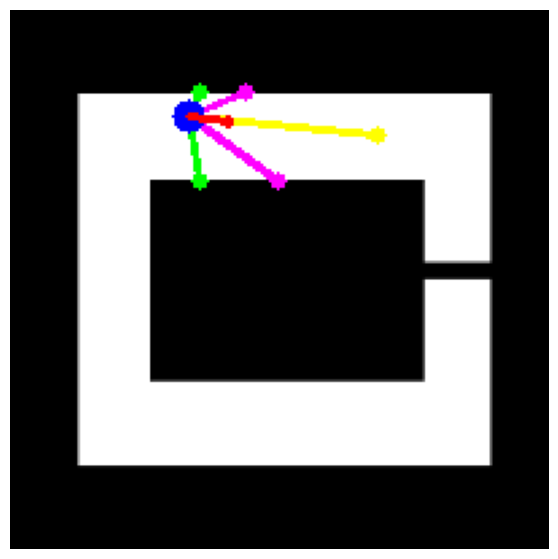

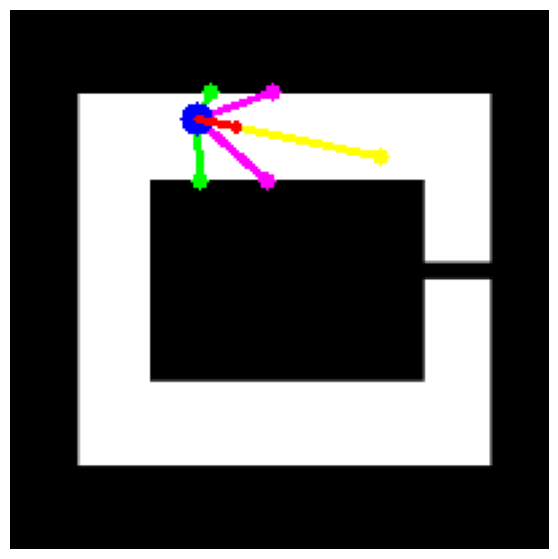

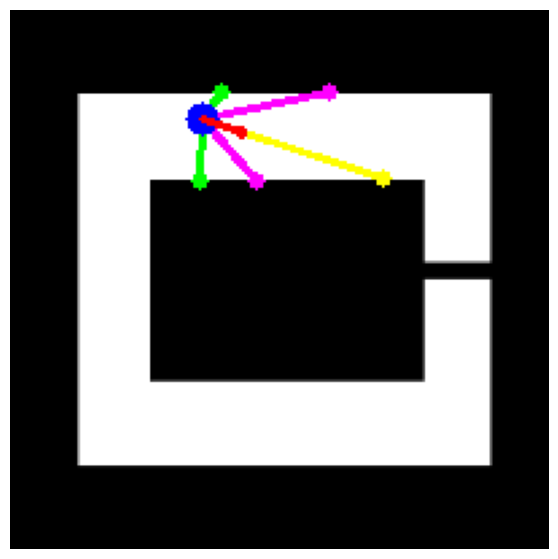

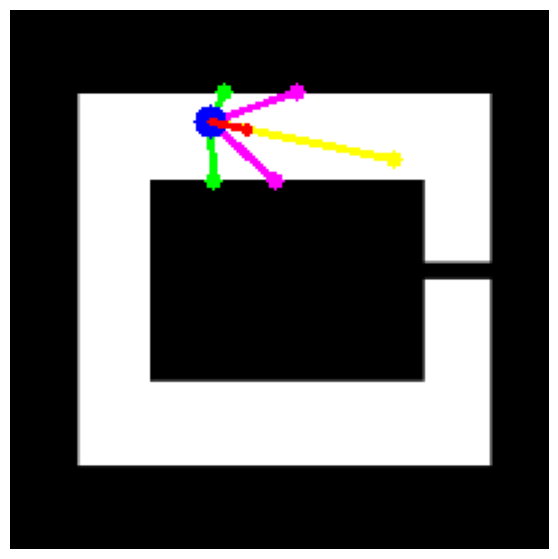

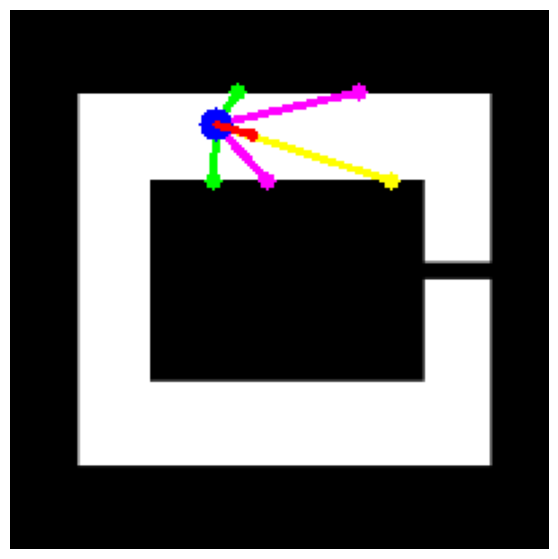

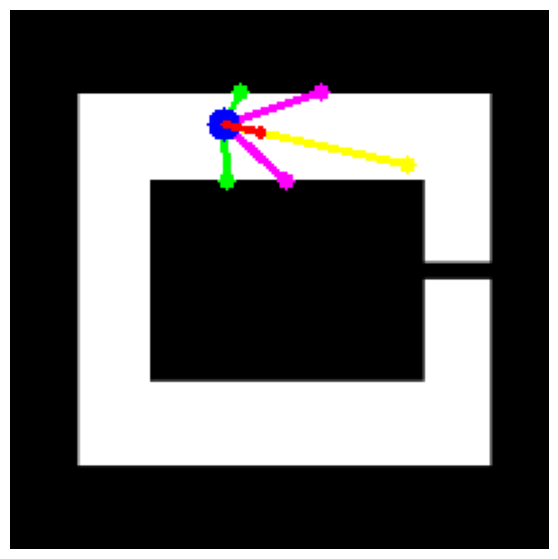

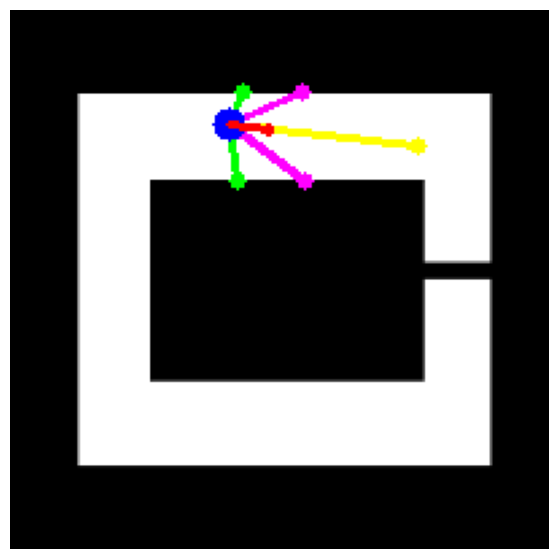

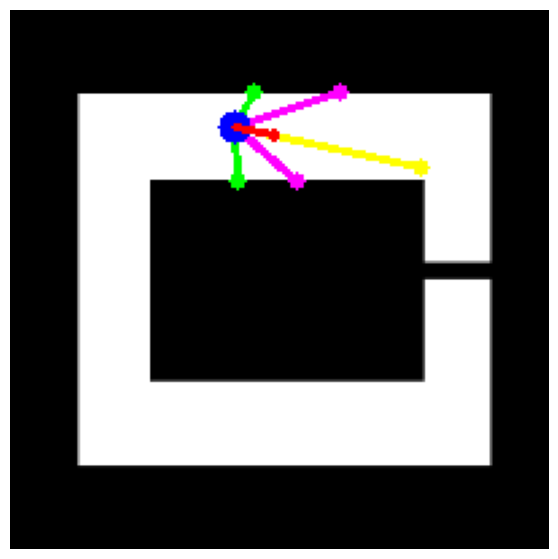

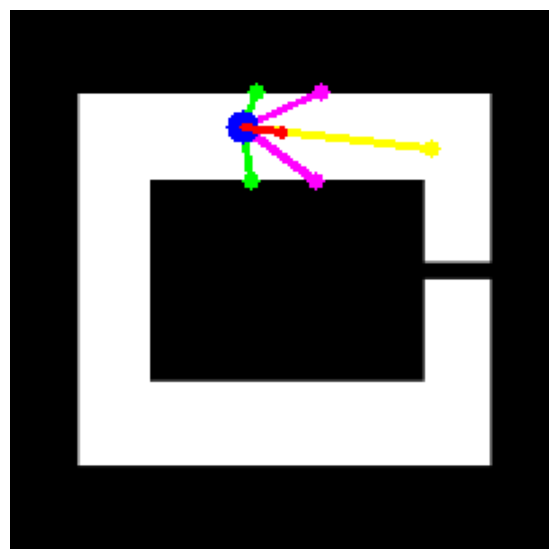

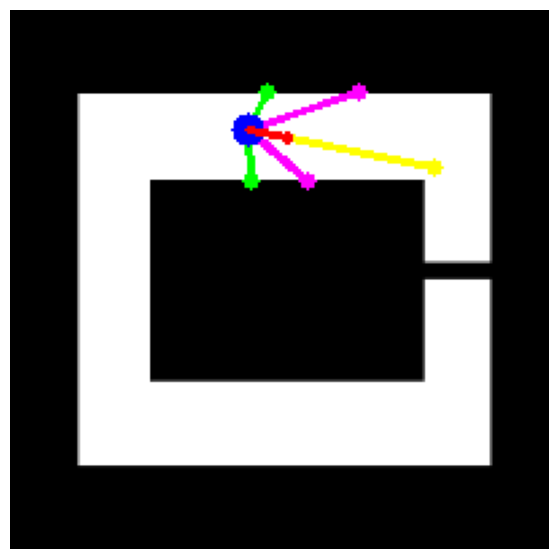

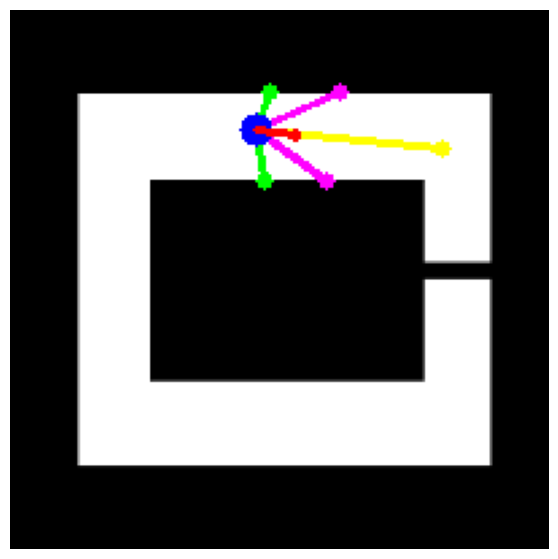

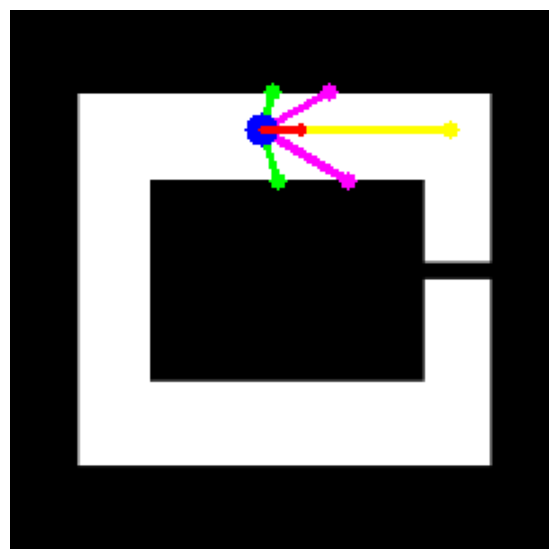

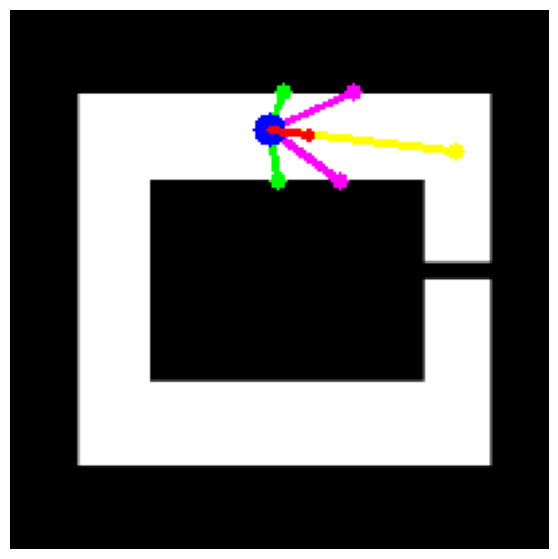

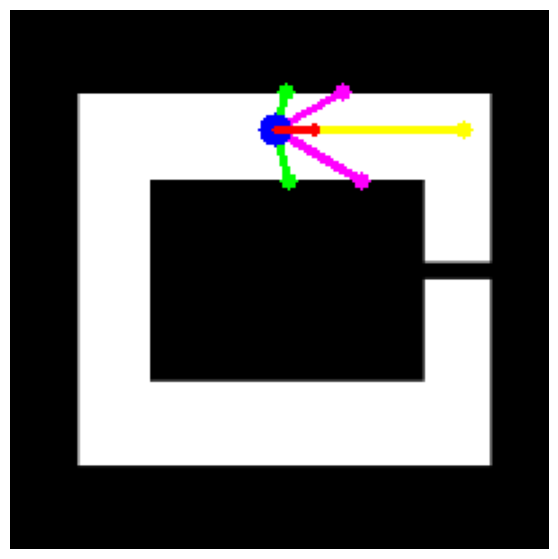

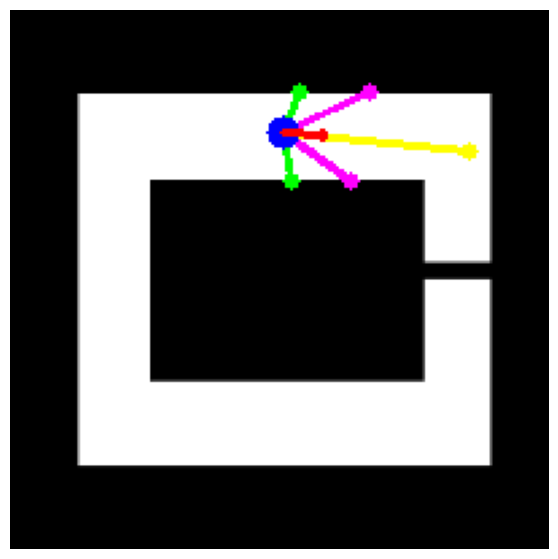

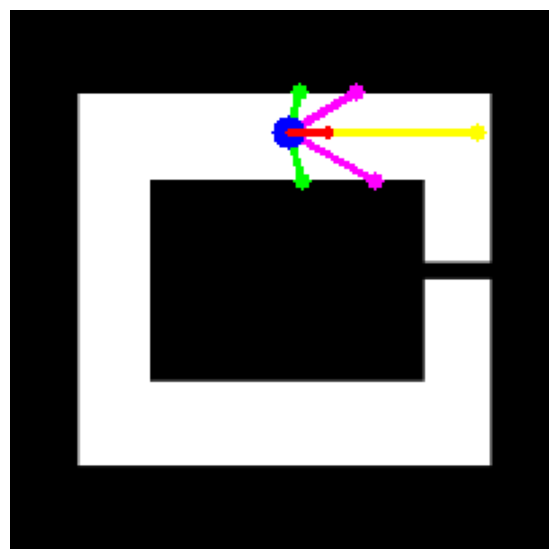

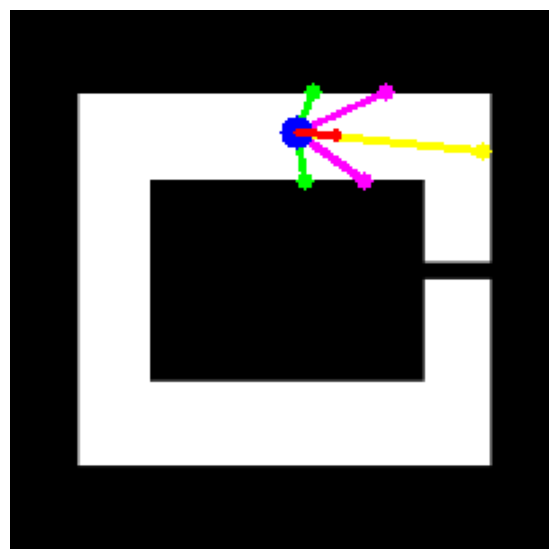

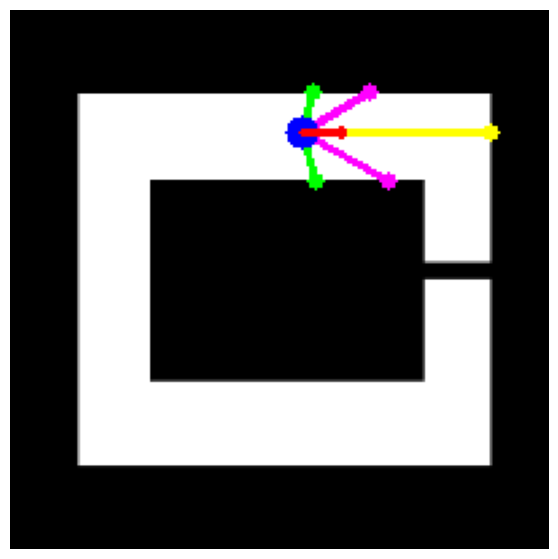

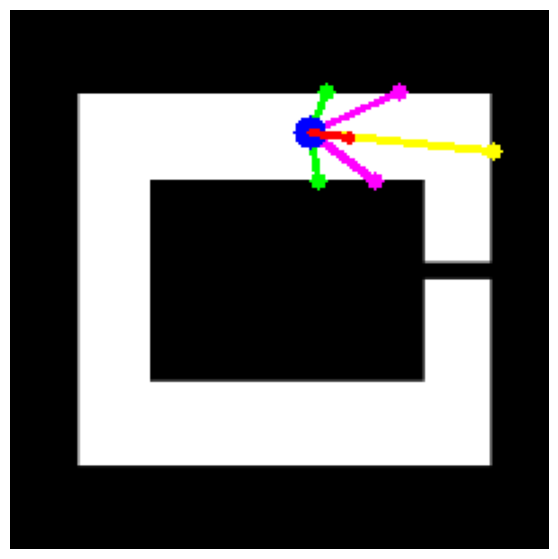

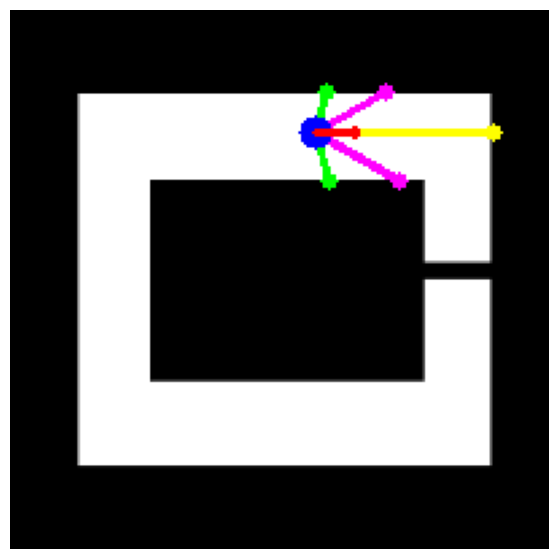

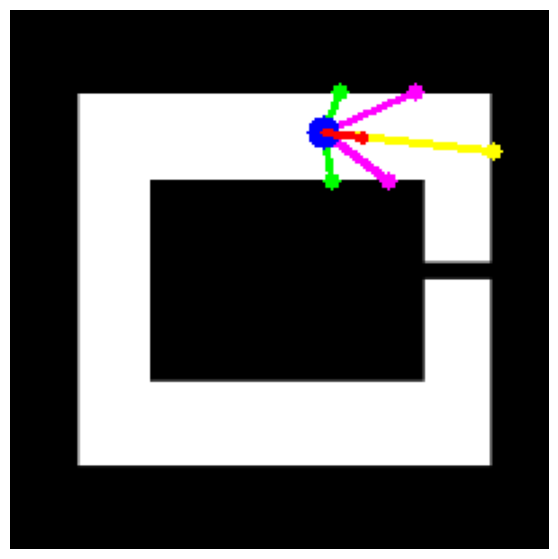

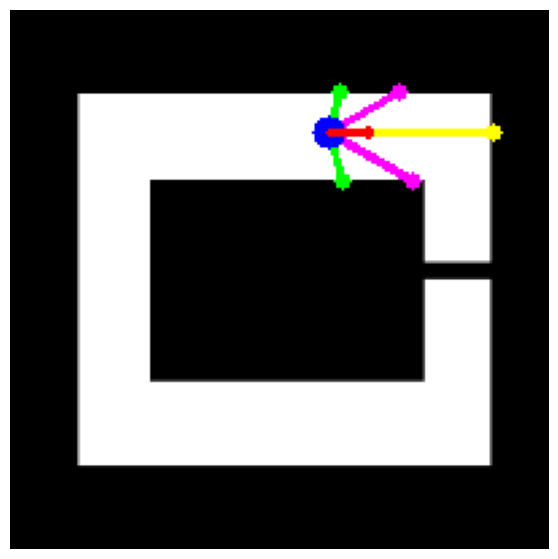

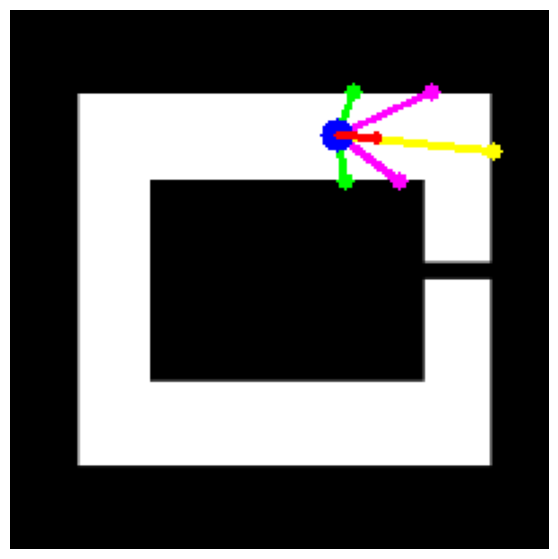

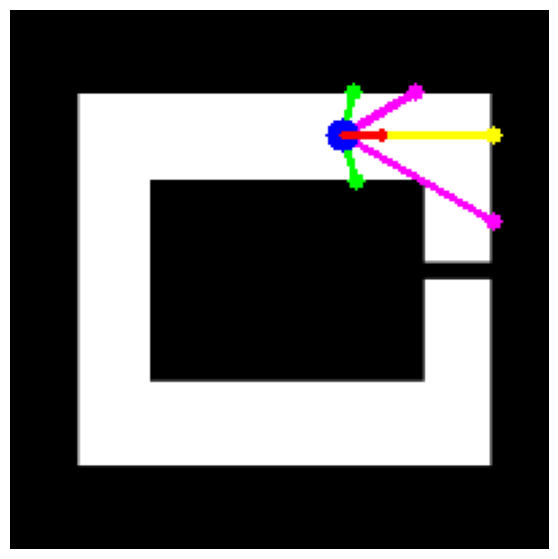

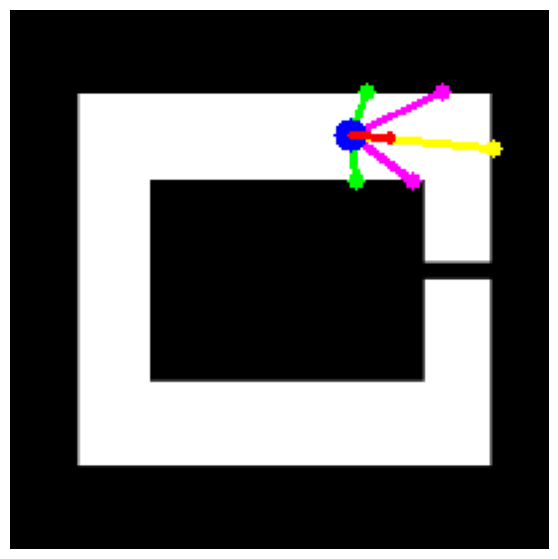

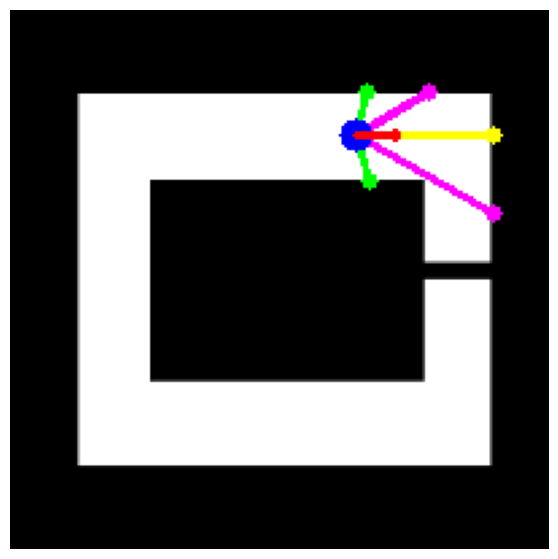

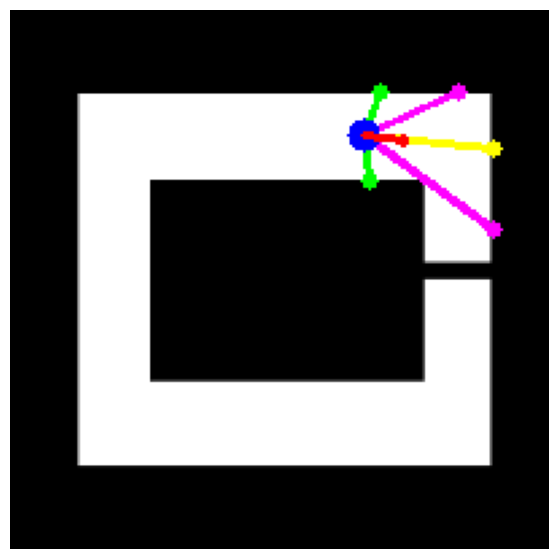

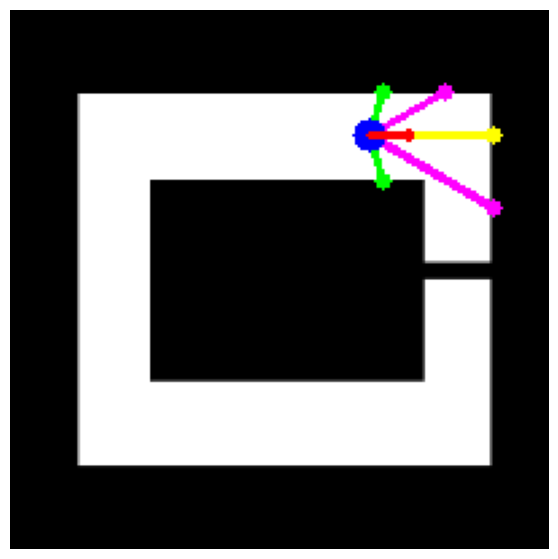

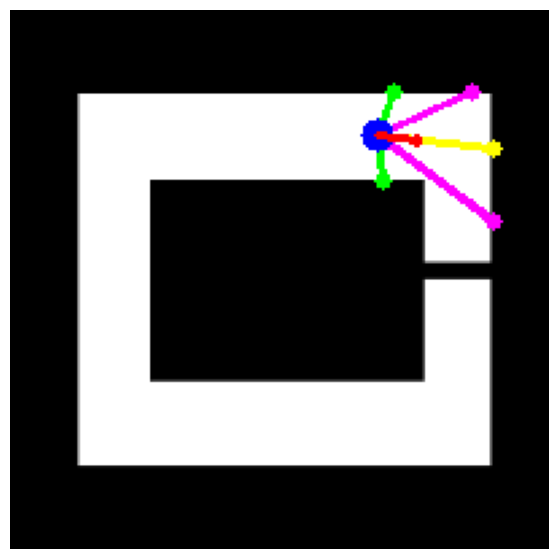

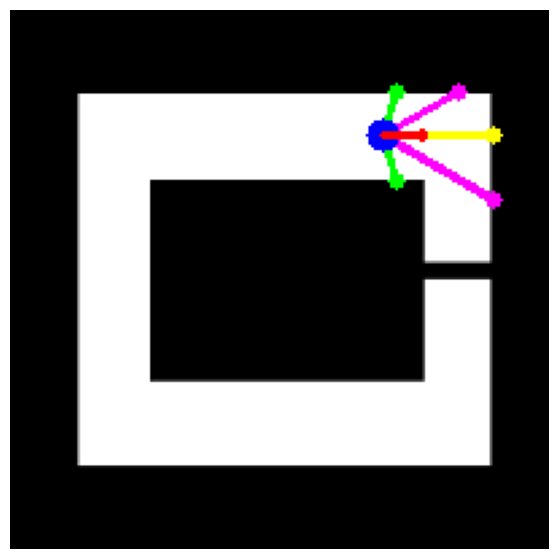

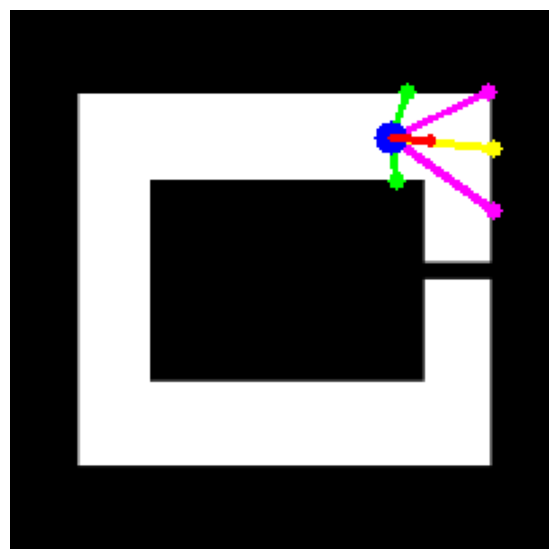

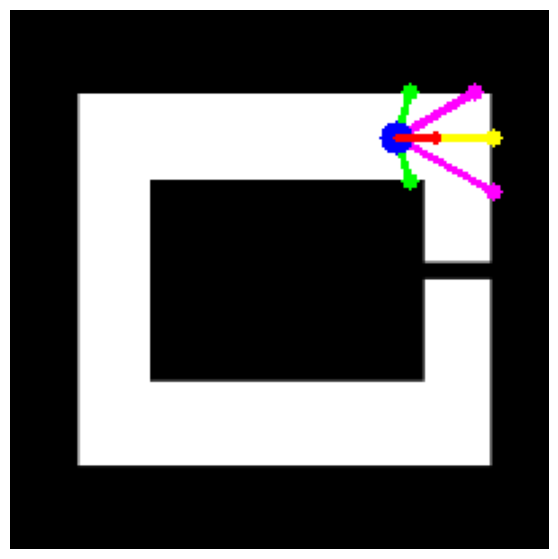

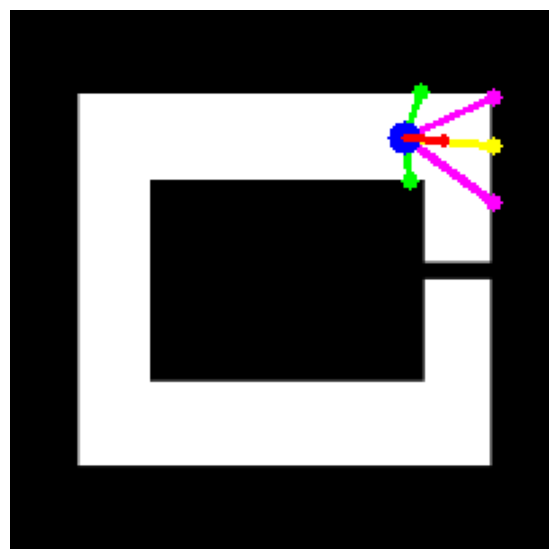

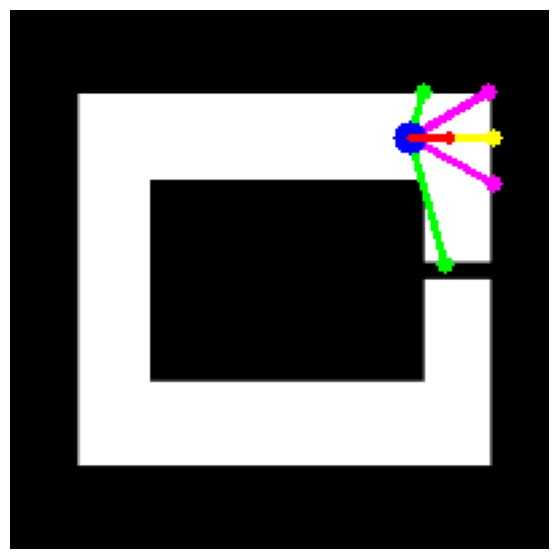

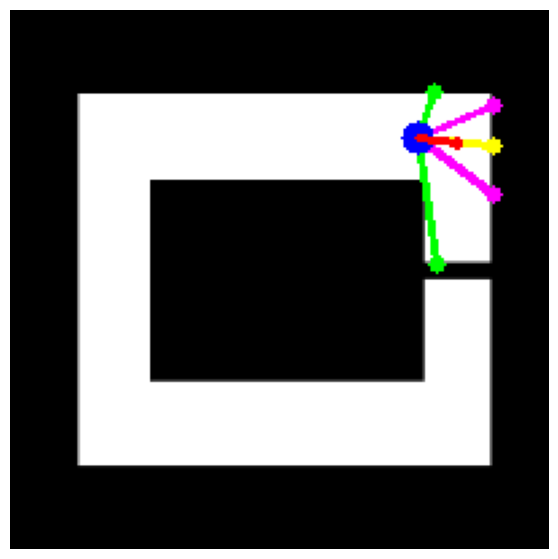

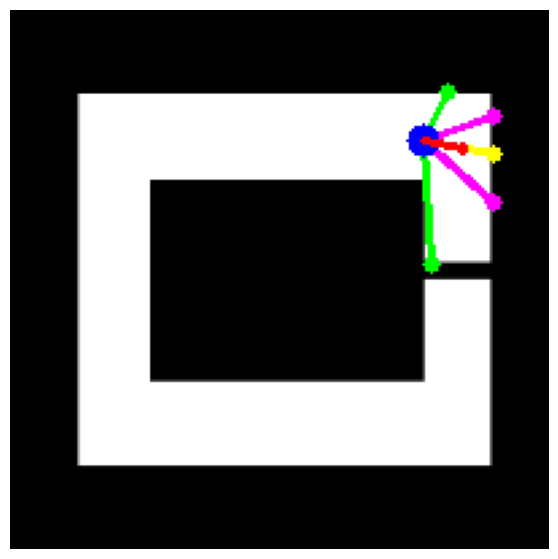

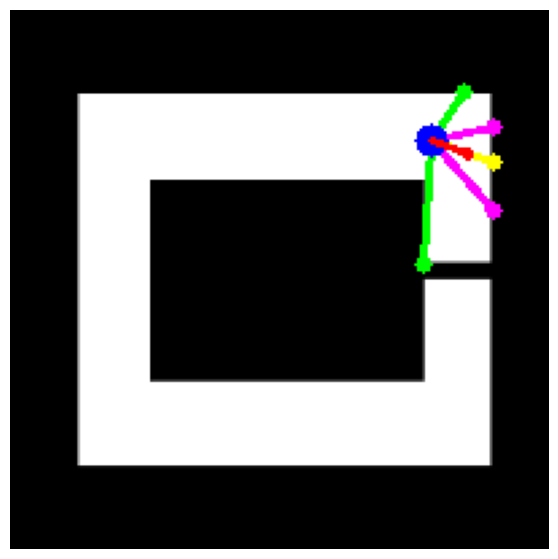

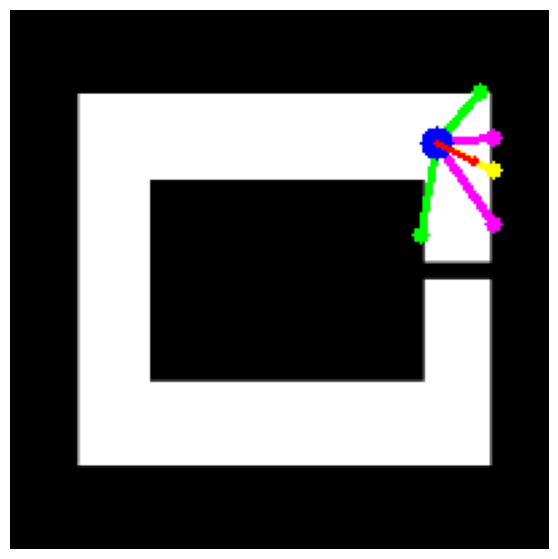

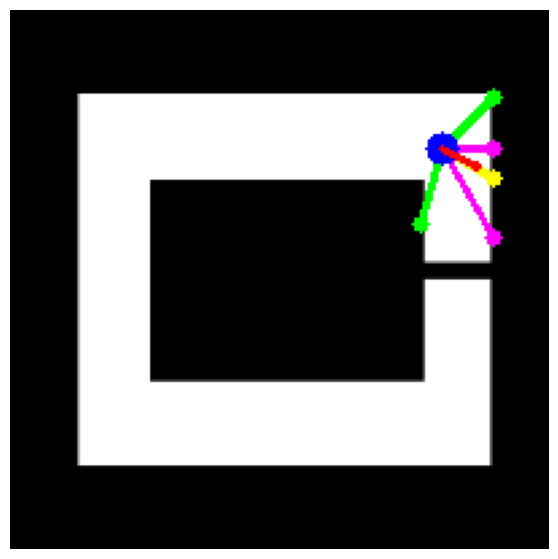

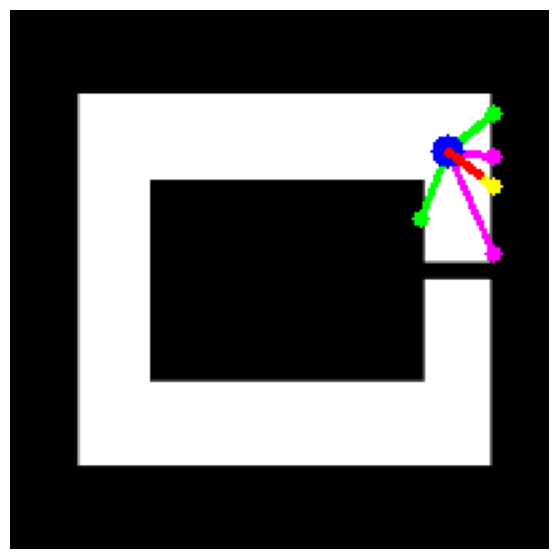

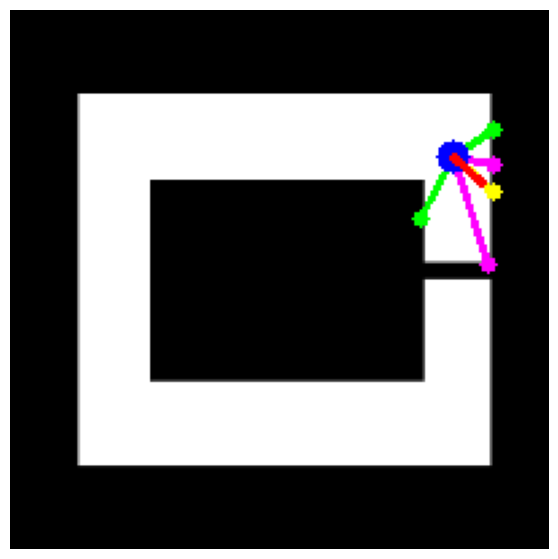

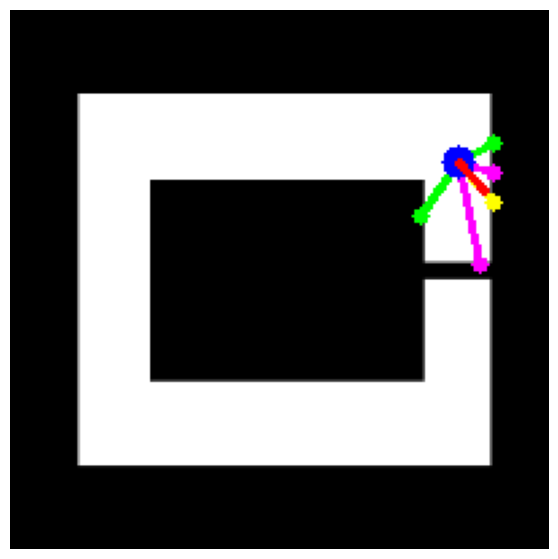

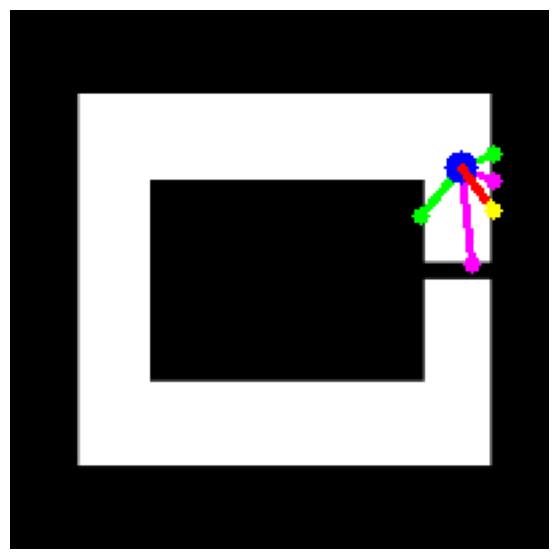

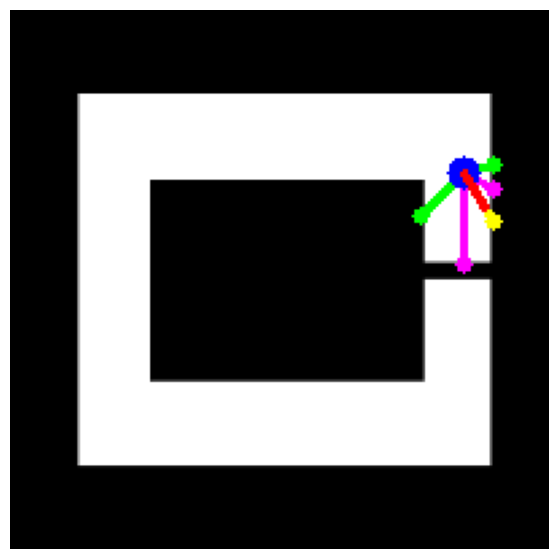

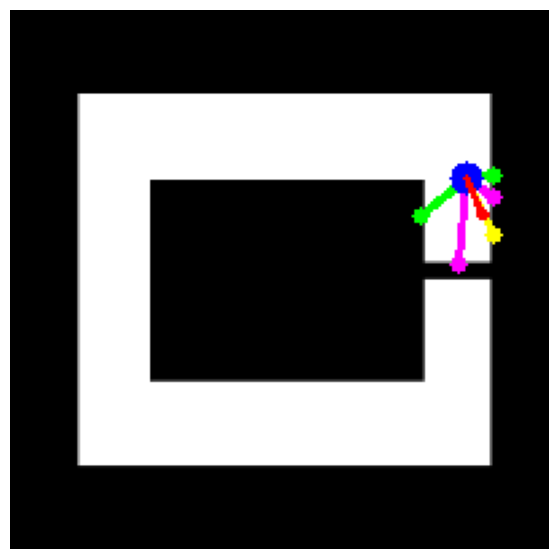

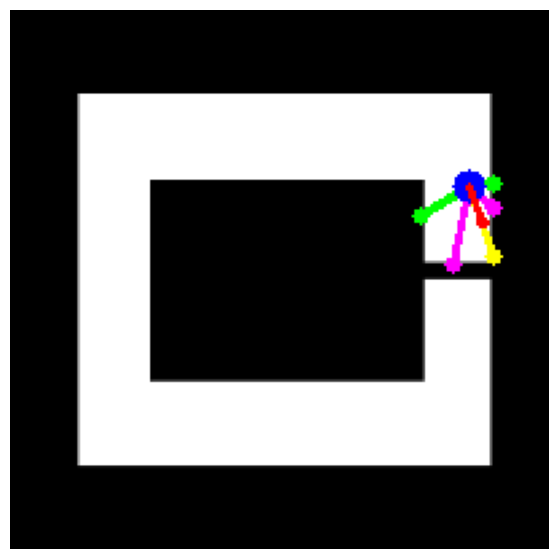

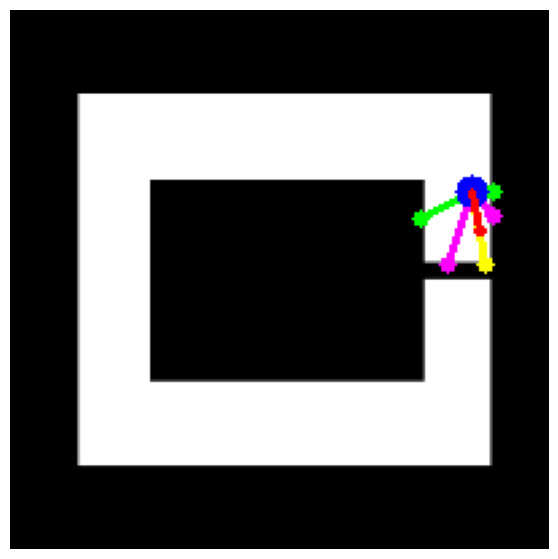

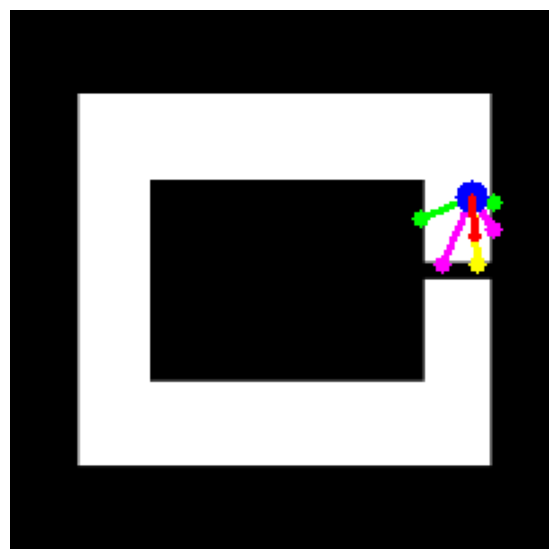

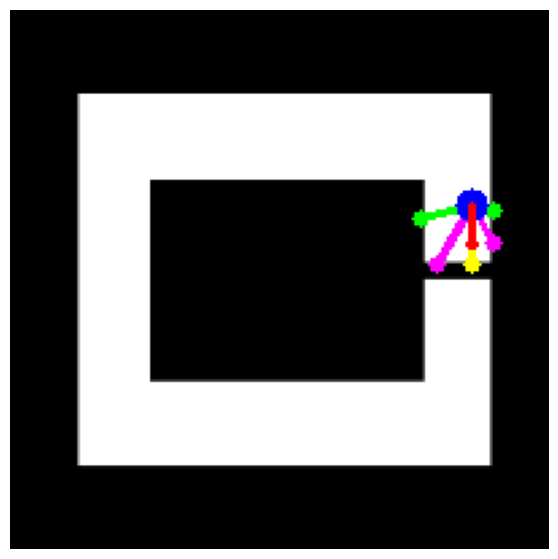

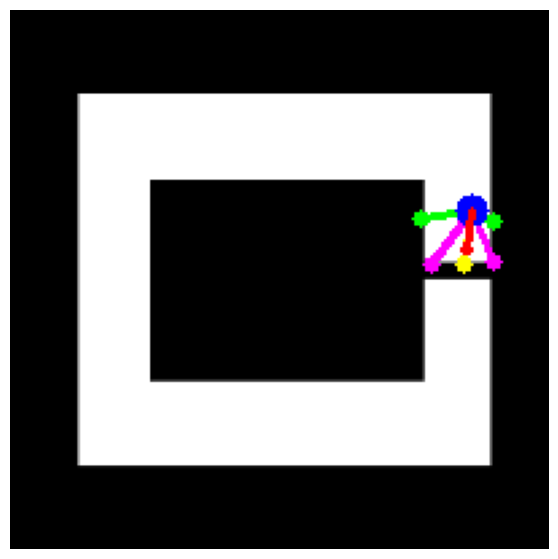

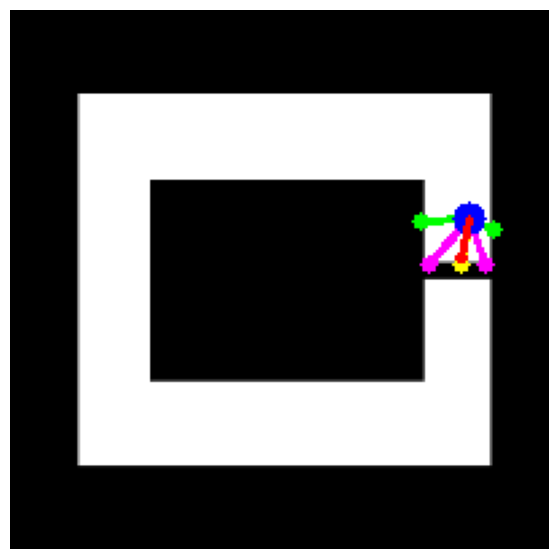

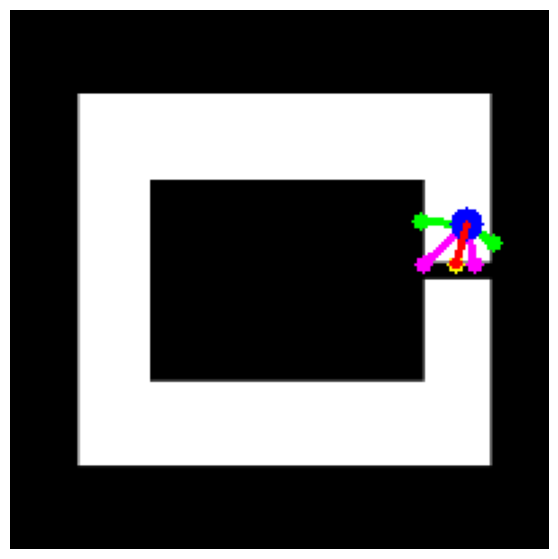

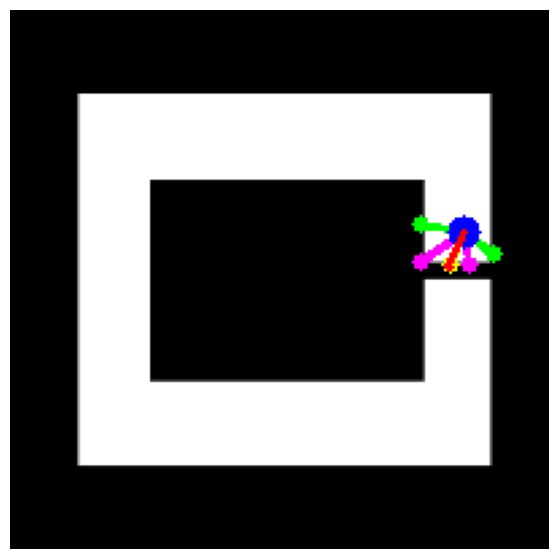

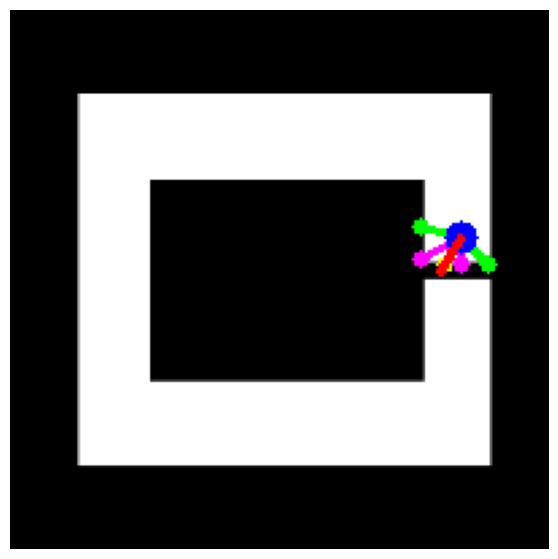

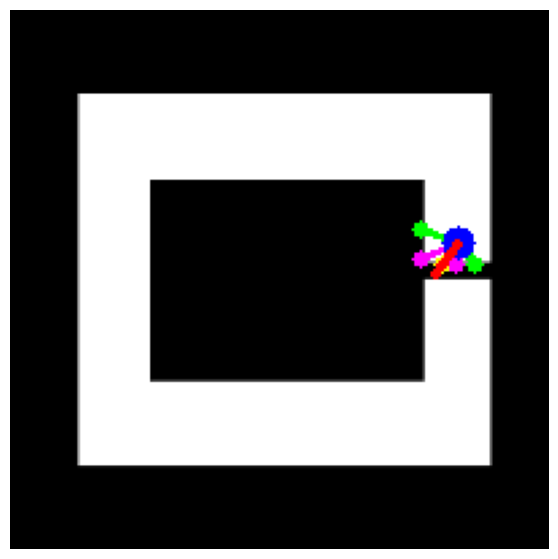

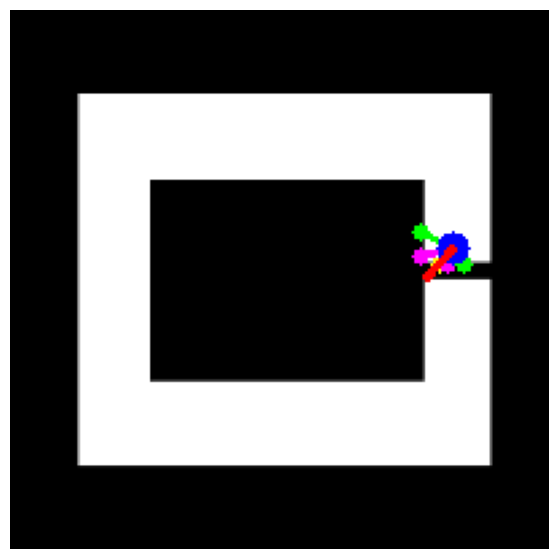

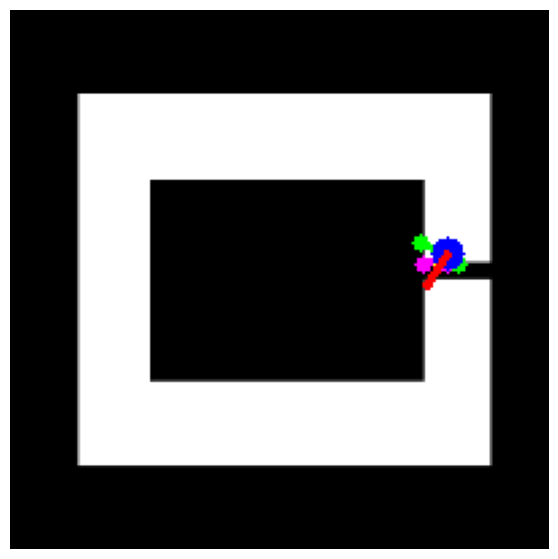

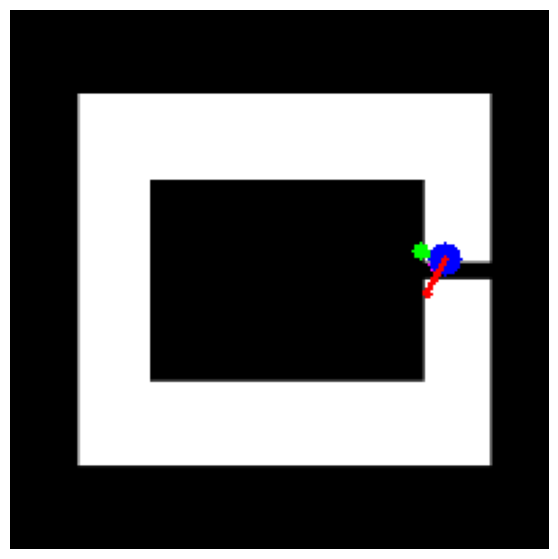

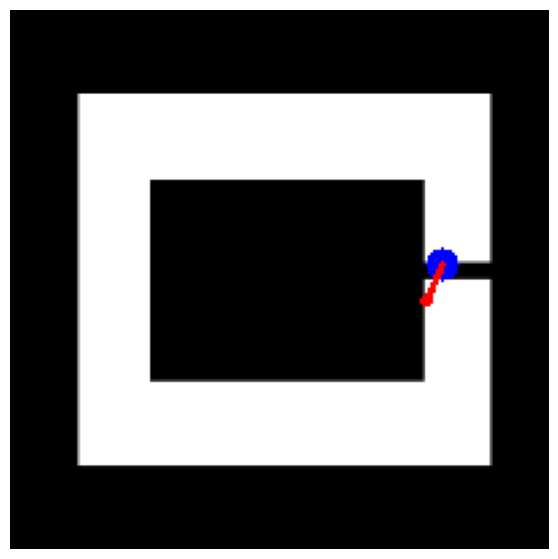

Total Reward : 350.6000000000003
Steps Survived : 238


In [16]:
env = RacingEnv()     # New racing environment
obs, _ = env.reset()  # Reset the environment to its starting state
done = False          # Variable indicating whether the episode has ended

total_reward = 0      # Stores the total reward earned during this episode
steps = 0             # Counts how many steps the car survives

# Continue until the car crashes or reaches the finish line
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = env.step(action)
    total_reward += reward
    steps += 1
    env.render() # Display the current position of the car on the track

print("Total Reward :", total_reward)
print("Steps Survived :", steps)

**SIMPLE REWARDED GRAPH**

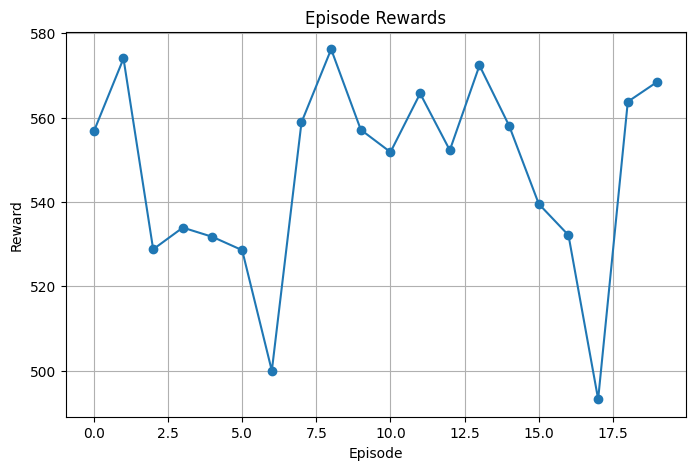

Average Reward: 547.1450000000009
Best Reward: 576.2000000000008
Worst Reward: 493.2000000000007


In [17]:
# List to store the total reward obtained in each episode
episode_rewards = []

# Run the trained agent for 20 different episodes
for episode in range(20):
    obs, _ = env.reset()
    done = False
    total_reward = 0

    # Continue until the episode ends
    while not done:
        action, _ = model.predict(obs)
        obs, reward, done, _, _ = env.step(action)
        total_reward += reward

    episode_rewards.append(total_reward)

#plotting graph
plt.figure(figsize=(8,5))
plt.plot(episode_rewards, marker="o")
plt.title("Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

print("Average Reward:", np.mean(episode_rewards))
print("Best Reward:", np.max(episode_rewards))
print("Worst Reward:", np.min(episode_rewards))

**GIF OF PATH OF CAR**




In [18]:
frames = []
env = RacingEnv()
obs, _ = env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = env.step(action)
    img = cv2.cvtColor(env.track, cv2.COLOR_GRAY2RGB)

    # Draw car
    cv2.circle( img, (int(env.x), int(env.y)), 6, (255,0,0), -1)

    # Draw sensors
    for angle_offset in env.sensor_angles:
        dist = env.cast_sensor(angle_offset)
        angle = np.radians(env.angle + angle_offset)
        end_x = int(env.x + dist*np.cos(angle))
        end_y = int(env.y + dist*np.sin(angle))
        cv2.line( img, (int(env.x), int(env.y)), (end_x,end_y), (255,255,0), 2)

    frames.append(img)

imageio.mimsave("racing.gif", frames, fps=12)

print("GIF Saved!")

GIF Saved!
